<a href="https://colab.research.google.com/github/oslopez081/Anlisis-anestesia-cardiovascular/blob/main/Anestesia_codigo_limpio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Validación Externa Comparativa de Modelos Predictivos de Riesgo en Cirugía Cardiovascular: EuroSCORE II, STS Score y APACHE IV Preoperatorio

## 1. INTRODUCCIÓN Y JUSTIFICACIÓN METODOLÓGICA

La estratificación del riesgo preoperatorio es un pilar fundamental en la anestesiología cardiovascular moderna. No obstante, los scores tradicionales han sido desarrollados en poblaciones con características sociodemográficas y de infraestructura distintas a las de nuestro medio. Este notebook documenta la ejecución matemática y computacional para evaluar el rendimiento predictivo de tres escalas ampliamente difundidas: **EuroSCORE II**, **STS Score** y **APACHE IV** estimado a partir de variables preoperatorias.


El tamaño de muestra mínimo calculado mediante la fórmula de *Hanley & McNeil* para garantizar la validez inferencial del contraste de curvas ROC fue de **194 participantes**. Con la inclusión consecutiva y el cierre de seguimiento de **197 pacientes reales** con información completa, la cohorte del estudio se encuentra **completamente cerrada, madura y dotada del 100% del poder estadístico proyectado**.


---

## 2. HIPÓTESIS DEL ANÁLISIS

*   **Hipótesis Nula ($H_0$):** No existen diferencias estadísticamente significativas en la capacidad discriminativa ($AUC_{APACHE\ IV} - AUC_{EuroSCORE\ II / STS} = 0$) ni en la calibración global (Razón O/E similar) entre el APACHE IV preoperatorio y las calculadoras de riesgo quirúrgico tradicionales (EuroSCORE II y STS Score) en la cohorte analizada.
*   **Hipótesis Alternativa ($H_a$):** Existen diferencias estadísticamente significativas en la capacidad discriminativa del APACHE IV preoperatorio frente a las escalas tradicionales ($AUC_{APACHE\ IV} \neq AUC_{EuroSCORE\ II / STS}$, $p < 0.05$ calculado mediante la prueba pareada de DeLong), evidenciando un rendimiento predictivo y una aproximación del riesgo observado (Razón O/E) diferenciada frente a las escalas convencionales.

---

## 3. OBJETIVOS ESPECÍFICOS DEL FLUJO DE TRABAJO

1.  **Objetivo 1 (Caracterización Sociodemográfica):** Describir las características clínicas y sociodemográficas de la cohorte de cirugía cardiovascular incluida en el estudio.
2.  **Objetivo 2 (Perfil de Seguridad y Estancias):** Describir la frecuencia real observada de morbilidad perioperatoria a 30 días (ACV, insuficiencia renal aguda, reintervención, infección profunda de herida) y mortalidad hospitalaria en la población analizada.
3.  **Objetivo 3 (Rendimiento Predictivo Individual):** Evaluar de forma individual la capacidad de discriminación (mediante el área bajo la curva ROC con IC 95% Bootstrap) y calibración (mediante el test de Hosmer-Lemeshow y la Razón Observado/Esperado con IC Poisson) de cada uno de los tres scores estudiados.
4.  **Objetivo 4 (Contraste Inferencial Comparativo):** Comparar formalmente la capacidad discriminativa del APACHE IV frente a EuroSCORE II y STS Score utilizando la **prueba pareada no paramétrica de DeLong** para muestras correlacionadas, y contrastar la calibración macro del riesgo estimado.
5.  **Objetivo 5 (Utilidad Práctica e Interpretación Anestésica):** Analizar la viabilidad del APACHE IV preoperatorio como herramienta local de estratificación frente a las escalas especializadas tradicionales, discutiendo el impacto de su diseño dinámico en pacientes prequirúrgicos.

---

In [1]:
# ==============================================================================
# 1.1 INSTALACIÓN DE PAQUETES
# ==============================================================================

# Lista completa de paquetes utilizados en el análisis
paquetes <- c(
  # Limpieza y manipulación de datos
  "tidyverse",     # Colección principal (incluye dplyr, ggplot2, readr, tidyr)
  "dplyr",         # Manipulación de dataframes
  "readr",         # Importación de archivos planos (read_csv2)
  "tidyr",         # Transformación de datos (pivot_longer, etc.)

  # Análisis estadístico y tablas clínicas
  "gtsummary",     # Tabla 1 de características basales
  "pROC",          # Curvas ROC, AUC, prueba de DeLong
  "ResourceSelection", # Test de Hosmer-Lemeshow
  "moments",       # Cálculo de asimetría (skewness)
  "DescTools",     # Herramientas descriptivas generales
  "epitools",      # Análisis epidemiológico (proporciones, IC)
  "rstatix",       # Pruebas no paramétricas (Wilcoxon/Mann-Whitney)
  "boot",          # Bootstrap para intervalos de confianza del AUC

  # Visualización de datos
  "ggplot2",       # Motor gráfico principal
  "patchwork",     # Combinar gráficos en paneles
  "gridExtra",     # Organización de cuadrículas de gráficos
  "viridis",       # Paletas de colores científicas
  "ggpubr",        # Gráficos listos para publicación con p-valores
  "corrplot",      # Matriz de correlación visual
  "ggsignif",      # Indicadores de significancia estadística

  # Reportes y exportación
  "knitr",         # Compilación de bloques de código en reportes
  "kableExtra",    # Formato profesional de tablas
  "rmarkdown",     # Exportación de reportes dinámicos
  "writexl"        # Exportar a Excel
)

# Instalar paquetes faltantes
instalados <- paquetes %in% installed.packages()[,"Package"]
if (any(!instalados)) {
  install.packages(paquetes[!instalados], repos = "https://cloud.r-project.org")
}

cat("✅ Paquetes instalados exitosamente\n")

# ==============================================================================
# 1.2 CARGA DE LIBRERÍAS
# ==============================================================================

# Cargar todas las librerías con supresión de mensajes
suppressPackageStartupMessages({
  # Limpieza y manipulación
  library(tidyverse)
  library(dplyr)
  library(readr)
  library(tidyr)

  # Análisis estadístico
  library(gtsummary)
  library(pROC)
  library(ResourceSelection)
  library(moments)
  library(DescTools)
  library(epitools)
  library(rstatix)
  library(boot)

  # Visualización
  library(ggplot2)
  library(patchwork)
  library(gridExtra)
  library(viridis)
  library(ggpubr)
  library(corrplot)
  library(ggsignif)

  # Reportes y exportación
  library(knitr)
  library(kableExtra)
  library(rmarkdown)
  library(writexl)
})

cat("✅ Librerías cargadas exitosamente\n")

# ==============================================================================
# 1.3 CONFIGURACIÓN DEL PROYECTO (Rutas y opciones globales)
# ==============================================================================

# Crear estructura de carpetas para organización
dir.create("data", showWarnings = FALSE)
dir.create("output", showWarnings = FALSE)
dir.create("output/tablas", showWarnings = FALSE)
dir.create("output/graficos", showWarnings = FALSE)

# Definir rutas globales
PATH_DATA <- "data/datos_icb.csv"
PATH_OUTPUT <- "output/"
PATH_TABLAS <- "output/tablas/"
PATH_GRAFICOS <- "output/graficos/"

# Configurar tema consistente para todos los gráficos
tema_cientifico <- function() {
  theme_minimal(base_size = 12) +
    theme(
      plot.title = element_text(face = "bold", size = 14, hjust = 0.5),
      plot.subtitle = element_text(size = 10, color = "gray40", hjust = 0.5),
      axis.text = element_text(size = 10),
      axis.title = element_text(size = 11, face = "bold"),
      legend.position = "bottom",
      legend.title = element_text(face = "bold", size = 10),
      legend.text = element_text(size = 9),
      panel.grid.minor = element_blank(),
      panel.grid.major = element_line(color = "gray90", size = 0.5)
    )
}

# Configurar tema de gráficos por defecto
theme_set(tema_cientifico())

cat("✅ Configuración completada\n")
cat("📁 Estructura de carpetas creada:\n")
cat("  - data/ (archivos de datos)\n")
cat("  - output/tablas/ (tablas de resultados)\n")
cat("  - output/graficos/ (gráficos generados)\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘V8’, ‘litedown’, ‘reactR’, ‘proxy’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘bigD’, ‘bitops’, ‘juicyjuice’, ‘markdown’, ‘reactable’, ‘rootSolve’, ‘e1071’, ‘lmom’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘cards’, ‘cardx’, ‘gt’, ‘pbapply’, ‘mvtnorm’, ‘expm’, ‘Exact’, ‘gld’, ‘car’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘polynom’, ‘svglite’




✅ Paquetes instalados exitosamente
✅ Librerías cargadas exitosamente


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


✅ Configuración completada
📁 Estructura de carpetas creada:
  - data/ (archivos de datos)
  - output/tablas/ (tablas de resultados)
  - output/graficos/ (gráficos generados)


In [2]:
# ==============================================================================
# 2.1 DEFINICIÓN DE RUTAS Y VERIFICACIÓN DE ARCHIVOS
# ==============================================================================

# Si el archivo fue subido manualmente en el panel izquierdo de Colab:
PATH_DATA <- "/content/datos_icb.csv"

# Verificar la existencia física del archivo antes de la lectura
if (!file.exists(PATH_DATA)) {
  stop("⚠️ Archivo 'datos_icb.csv' no encontrado en la ruta: ", PATH_DATA,
       "\nPor favor, asegúrate de subir el archivo al panel lateral izquierdo de Colab 📁.")
}

# ==============================================================================
# 2.2 CARGA DE DATOS (LECTURA CLÍNICA CON COMAS DECIMALES)
# ==============================================================================

# Usamos read_csv2 porque el archivo original emplea ';' como delimitador
# y comas (,) como separadores decimales para las probabilidades de los scores.
datos_icb <- read_csv2(PATH_DATA, show_col_types = FALSE)

cat("📊 Dimensiones originales del dataset:", dim(datos_icb), "[Filas, Columnas]\n")

# ==============================================================================
# 2.3 LIMPIEZA DE FILAS Y COLUMNAS COMPLETAMENTE VACÍAS
# ==============================================================================

# 1. Eliminar filas que se importaron vacías (sin un solo dato válido)
datos_icb <- datos_icb[rowSums(!is.na(datos_icb)) > 0, ]

# 2. Eliminar columnas que no tengan ninguna observación
datos_icb <- datos_icb[, colSums(!is.na(datos_icb)) > 0]

cat("✅ Limpieza completada. Dimensiones depuradas:", dim(datos_icb), "[Filas, Columnas]\n")

# ==============================================================================
# 2.4 GUARDADO LOCAL Y CREACIÓN DE BACKUP DE TRABAJO
# ==============================================================================

# Guardamos una copia limpia en la carpeta raíz
write.csv2(datos_icb, "datos_icb.csv", row.names = FALSE)

# Creamos la copia de seguridad de trabajo recomendada
datos_icb_clean <- datos_icb

cat("✅ Backup de seguridad creado exitosamente como 'datos_icb_clean'\n")

# ==============================================================================
# 2.5 INSPECCIÓN ESTRUCTURAL PRELIMINAR
# ==============================================================================
cat("\n=== PRIMEROS REGISTROS DE LA BASE (MUESTRA DE CONTROL) ===\n")
print(head(datos_icb[, 1:5])) # Muestra las primeras 5 columnas para control visual

📊 Dimensiones originales del dataset: 197 40 [Filas, Columnas]
📊 Dimensiones originales del dataset: 197 40 [Filas, Columnas]
📊 Dimensiones originales del dataset: 197 40 [Filas, Columnas]
✅ Limpieza completada. Dimensiones depuradas: 197 40 [Filas, Columnas]
✅ Limpieza completada. Dimensiones depuradas: 197 40 [Filas, Columnas]
✅ Limpieza completada. Dimensiones depuradas: 197 40 [Filas, Columnas]
✅ Backup de seguridad creado exitosamente como 'datos_icb_clean'
✅ Backup de seguridad creado exitosamente como 'datos_icb_clean'
✅ Backup de seguridad creado exitosamente como 'datos_icb_clean'

=== PRIMEROS REGISTROS DE LA BASE (MUESTRA DE CONTROL) ===

=== PRIMEROS REGISTROS DE LA BASE (MUESTRA DE CONTROL) ===

=== PRIMEROS REGISTROS DE LA BASE (MUESTRA DE CONTROL) ===
# A tibble: 6 × 5
  record_id numero_identificacion secuencial_paciente  edad  sexo
      <dbl>                 <dbl>               <dbl> <dbl> <dbl>
1         1              19304864                1001    69     2
2      

In [3]:
# ==============================================================================
# 3.1 TRANSFORMACIÓN DE VARIABLES SOCIODEMOGRÁFICAS (VERSIÓN ADAPTATIVA)
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 3.1 TRANSFORMACIÓN DE VARIABLES SOCIODEMOGRÁFICAS ===\n")
cat(rep("=", 80), "\n", sep = "")

# Primero, inspeccionamos los nombres de las columnas para identificar
# las variables sociodemográficas
cat("\n📊 INSPECCIÓN DE NOMBRES DE COLUMNAS:\n")
cat("  • Nombres disponibles:", paste(names(datos_icb_clean)[1:15], collapse = ", "), "\n")

# Verificar qué variables existen realmente
vars_disponibles <- names(datos_icb_clean)

# Identificar la columna de sexo (puede llamarse "sexo", "genero", etc.)
col_sexo <- vars_disponibles[str_detect(vars_disponibles, regex("sexo|genero|gender", ignore_case = TRUE))][1]

# Identificar columna de edad
col_edad <- vars_disponibles[str_detect(vars_disponibles, regex("edad|age", ignore_case = TRUE))][1]

# Identificar columna de escolaridad
col_escolaridad <- vars_disponibles[str_detect(vars_disponibles, regex("escolaridad|educacion|education|school", ignore_case = TRUE))][1]

# Identificar columna de situación laboral
col_laboral <- vars_disponibles[str_detect(vars_disponibles, regex("laboral|trabajo|occupation", ignore_case = TRUE))][1]

# Identificar columna de estado civil
col_civil <- vars_disponibles[str_detect(vars_disponibles, regex("civil|marital", ignore_case = TRUE))][1]

# Identificar columna de régimen de salud
col_regimen <- vars_disponibles[str_detect(vars_disponibles, regex("regimen|salud|health", ignore_case = TRUE))][1]

cat("\n📊 VARIABLES IDENTIFICADAS:\n")
cat("  • Sexo:", col_sexo, "\n")
cat("  • Edad:", col_edad, "\n")
cat("  • Escolaridad:", col_escolaridad, "\n")
cat("  • Situación laboral:", col_laboral, "\n")
cat("  • Estado civil:", col_civil, "\n")
cat("  • Régimen de salud:", col_regimen, "\n")

# ==============================================================================
# 3.1.1 FUNCIÓN PARA DETECTAR EL FORMATO DE LOS DATOS
# ==============================================================================

# Función para detectar si una variable es numérica o ya es factor/texto
detectar_formato <- function(var) {
  if (is.numeric(var)) {
    return("numeric")
  } else if (is.factor(var) || is.character(var)) {
    # Verificar si son etiquetas de texto o códigos numéricos en texto
    valores_unicos <- unique(var)
    if (all(valores_unicos %in% c("1", "2", "3", "4", "5", "6", "Masculino", "Femenino",
                                  "Soltero", "Casado", "Unión libre", "Viudo",
                                  "Empleado", "Independiente", "Jubilado"))) {
      return("text_labels")
    } else {
      return("text_codes")
    }
  }
  return("unknown")
}

# ==============================================================================
# 3.1.2 TRANSFORMACIÓN DE SEXO
# ==============================================================================

if (!is.null(col_sexo) && col_sexo %in% names(datos_icb_clean)) {
  cat("\n📊 TRANSFORMANDO SEXO...\n")

  # Verificar valores únicos actuales
  valores_sexo <- unique(datos_icb_clean[[col_sexo]])
  cat("  • Valores actuales:", paste(valores_sexo, collapse = ", "), "\n")

  # Detectar formato
  if (is.numeric(datos_icb_clean[[col_sexo]])) {
    # Formato numérico: 1=Femenino, 2=Masculino
    cat("  • Formato detectado: Numérico (1=Femenino, 2=Masculino)\n")
    datos_icb_clean <- datos_icb_clean %>%
      mutate(
        sexo = factor(case_when(
          !!sym(col_sexo) == 1 ~ "Femenino",
          !!sym(col_sexo) == 2 ~ "Masculino",
          TRUE ~ NA_character_
        ), levels = c("Masculino", "Femenino"))
      )
  } else if (is.character(datos_icb_clean[[col_sexo]]) || is.factor(datos_icb_clean[[col_sexo]])) {
    # Formato texto: puede ser "Masculino"/"Femenino" o "M"/"F"
    valores_texto <- unique(as.character(datos_icb_clean[[col_sexo]]))
    cat("  • Formato detectado: Texto\n")

    # Mapear a formatos estándar
    datos_icb_clean <- datos_icb_clean %>%
      mutate(
        sexo = factor(case_when(
          str_detect(tolower(as.character(!!sym(col_sexo))), "m|masculino|male|hombre") ~ "Masculino",
          str_detect(tolower(as.character(!!sym(col_sexo))), "f|femenino|female|mujer") ~ "Femenino",
          TRUE ~ NA_character_
        ), levels = c("Masculino", "Femenino"))
      )
  } else {
    cat("  • ⚠️ Formato no reconocido. Se mantiene la variable original.\n")
    datos_icb_clean$sexo <- datos_icb_clean[[col_sexo]]
  }
} else {
  cat("\n⚠️ Variable de sexo no encontrada. Verifica los nombres de las columnas.\n")
}

# ==============================================================================
# 3.1.3 TRANSFORMACIÓN DE EDAD
# ==============================================================================

if (!is.null(col_edad) && col_edad %in% names(datos_icb_clean)) {
  cat("\n📊 TRANSFORMANDO EDAD...\n")
  datos_icb_clean <- datos_icb_clean %>%
    mutate(
      edad = ifelse(!!sym(col_edad) < 0 | !!sym(col_edad) > 120 | is.na(!!sym(col_edad)),
                    NA, !!sym(col_edad))
    )
  cat("  • Edad transformada correctamente\n")
} else {
  cat("\n⚠️ Variable de edad no encontrada. Verifica los nombres de las columnas.\n")
}

# ==============================================================================
# 3.1.4 TRANSFORMACIÓN DE ESCOLARIDAD (ORDINAL)
# ==============================================================================

if (!is.null(col_escolaridad) && col_escolaridad %in% names(datos_icb_clean)) {
  cat("\n📊 TRANSFORMANDO ESCOLARIDAD...\n")

  valores_esc <- unique(datos_icb_clean[[col_escolaridad]])
  cat("  • Valores actuales:", paste(valores_esc, collapse = ", "), "\n")

  # Mapeo de valores comunes para escolaridad
  if (is.numeric(datos_icb_clean[[col_escolaridad]])) {
    # Formato numérico: 1=Primaria, 2=Secundaria, 3=Técnica, 4=Profesional, 5=Posgrado
    datos_icb_clean <- datos_icb_clean %>%
      mutate(
        escolaridad_maxima = factor(case_when(
          !!sym(col_escolaridad) == 1 ~ "Básica primaria",
          !!sym(col_escolaridad) == 2 ~ "Básica secundaria",
          !!sym(col_escolaridad) == 3 ~ "Técnica/Tecnológica",
          !!sym(col_escolaridad) == 4 ~ "Profesional",
          !!sym(col_escolaridad) == 5 ~ "Posgrado",
          TRUE ~ NA_character_
        ),
        levels = c("Básica primaria", "Básica secundaria",
                   "Técnica/Tecnológica", "Profesional", "Posgrado"),
        ordered = TRUE)
      )
  } else {
    # Formato texto - intentar mapear
    datos_icb_clean <- datos_icb_clean %>%
      mutate(
        escolaridad_maxima = factor(case_when(
          str_detect(tolower(as.character(!!sym(col_escolaridad))), "primaria|basica|prim|1") ~ "Básica primaria",
          str_detect(tolower(as.character(!!sym(col_escolaridad))), "secundaria|media|2") ~ "Básica secundaria",
          str_detect(tolower(as.character(!!sym(col_escolaridad))), "tecnica|tecnologica|3") ~ "Técnica/Tecnológica",
          str_detect(tolower(as.character(!!sym(col_escolaridad))), "profesional|universidad|4") ~ "Profesional",
          str_detect(tolower(as.character(!!sym(col_escolaridad))), "posgrado|master|doctorado|5") ~ "Posgrado",
          TRUE ~ NA_character_
        ),
        levels = c("Básica primaria", "Básica secundaria",
                   "Técnica/Tecnológica", "Profesional", "Posgrado"),
        ordered = TRUE)
      )
  }
  cat("  • Escolaridad transformada correctamente\n")
} else {
  cat("\n⚠️ Variable de escolaridad no encontrada.\n")
}

# ==============================================================================
# 3.1.5 TRANSFORMACIÓN DE SITUACIÓN LABORAL
# ==============================================================================

if (!is.null(col_laboral) && col_laboral %in% names(datos_icb_clean)) {
  cat("\n📊 TRANSFORMANDO SITUACIÓN LABORAL...\n")

  if (is.numeric(datos_icb_clean[[col_laboral]])) {
    datos_icb_clean <- datos_icb_clean %>%
      mutate(
        situacion_laboral = factor(case_when(
          !!sym(col_laboral) == 1 ~ "Empleado",
          !!sym(col_laboral) == 2 ~ "Independiente",
          !!sym(col_laboral) == 3 ~ "Estudiante",
          !!sym(col_laboral) == 4 ~ "No empleado/Hogar",
          !!sym(col_laboral) == 5 ~ "Jubilado",
          !!sym(col_laboral) == 6 ~ "Incapacitado",
          TRUE ~ NA_character_
        ),
        levels = c("Empleado", "Independiente", "Estudiante",
                   "No empleado/Hogar", "Jubilado", "Incapacitado"))
      )
  } else {
    # Formato texto
    datos_icb_clean <- datos_icb_clean %>%
      mutate(
        situacion_laboral = factor(case_when(
          str_detect(tolower(as.character(!!sym(col_laboral))), "empleado|trabajador") ~ "Empleado",
          str_detect(tolower(as.character(!!sym(col_laboral))), "independiente|autonomo") ~ "Independiente",
          str_detect(tolower(as.character(!!sym(col_laboral))), "estudiante") ~ "Estudiante",
          str_detect(tolower(as.character(!!sym(col_laboral))), "hogar|ama|no empleado|desempleado") ~ "No empleado/Hogar",
          str_detect(tolower(as.character(!!sym(col_laboral))), "jubilado|retirado|pensionado") ~ "Jubilado",
          str_detect(tolower(as.character(!!sym(col_laboral))), "incapacitado|discapacitado") ~ "Incapacitado",
          TRUE ~ NA_character_
        ),
        levels = c("Empleado", "Independiente", "Estudiante",
                   "No empleado/Hogar", "Jubilado", "Incapacitado"))
      )
  }
  cat("  • Situación laboral transformada correctamente\n")
} else {
  cat("\n⚠️ Variable de situación laboral no encontrada.\n")
}

# ==============================================================================
# 3.1.6 TRANSFORMACIÓN DE ESTADO CIVIL
# ==============================================================================

if (!is.null(col_civil) && col_civil %in% names(datos_icb_clean)) {
  cat("\n📊 TRANSFORMANDO ESTADO CIVIL...\n")

  if (is.numeric(datos_icb_clean[[col_civil]])) {
    datos_icb_clean <- datos_icb_clean %>%
      mutate(
        estado_civil = factor(case_when(
          !!sym(col_civil) == 1 ~ "Soltero",
          !!sym(col_civil) == 2 ~ "Casado",
          !!sym(col_civil) == 3 ~ "Unión libre",
          !!sym(col_civil) == 4 ~ "Divorciado/Separado",
          !!sym(col_civil) == 5 ~ "Viudo",
          TRUE ~ NA_character_
        ),
        levels = c("Soltero", "Casado", "Unión libre",
                   "Divorciado/Separado", "Viudo"))
      )
  } else {
    # Formato texto
    datos_icb_clean <- datos_icb_clean %>%
      mutate(
        estado_civil = factor(case_when(
          str_detect(tolower(as.character(!!sym(col_civil))), "soltero") ~ "Soltero",
          str_detect(tolower(as.character(!!sym(col_civil))), "casado") ~ "Casado",
          str_detect(tolower(as.character(!!sym(col_civil))), "union libre|conviviente") ~ "Unión libre",
          str_detect(tolower(as.character(!!sym(col_civil))), "divorciado|separado") ~ "Divorciado/Separado",
          str_detect(tolower(as.character(!!sym(col_civil))), "viudo") ~ "Viudo",
          TRUE ~ NA_character_
        ),
        levels = c("Soltero", "Casado", "Unión libre",
                   "Divorciado/Separado", "Viudo"))
      )
  }
  cat("  • Estado civil transformado correctamente\n")
} else {
  cat("\n⚠️ Variable de estado civil no encontrada.\n")
}

# ==============================================================================
# 3.1.7 TRANSFORMACIÓN DE RÉGIMEN DE SALUD
# ==============================================================================

if (!is.null(col_regimen) && col_regimen %in% names(datos_icb_clean)) {
  cat("\n📊 TRANSFORMANDO RÉGIMEN DE SALUD...\n")

  if (is.numeric(datos_icb_clean[[col_regimen]])) {
    datos_icb_clean <- datos_icb_clean %>%
      mutate(
        regimen_salud = factor(case_when(
          !!sym(col_regimen) == 1 ~ "Subsidiado",
          !!sym(col_regimen) == 2 ~ "Contributivo",
          !!sym(col_regimen) == 3 ~ "Especial",
          !!sym(col_regimen) == 4 ~ "Póliza/Prepagada",
          !!sym(col_regimen) == 5 ~ "No afiliado",
          TRUE ~ NA_character_
        ),
        levels = c("Subsidiado", "Contributivo", "Especial",
                   "Póliza/Prepagada", "No afiliado"))
      )
  } else {
    # Formato texto
    datos_icb_clean <- datos_icb_clean %>%
      mutate(
        regimen_salud = factor(case_when(
          str_detect(tolower(as.character(!!sym(col_regimen))), "subsidiado") ~ "Subsidiado",
          str_detect(tolower(as.character(!!sym(col_regimen))), "contributivo") ~ "Contributivo",
          str_detect(tolower(as.character(!!sym(col_regimen))), "especial") ~ "Especial",
          str_detect(tolower(as.character(!!sym(col_regimen))), "poliza|prepagada") ~ "Póliza/Prepagada",
          str_detect(tolower(as.character(!!sym(col_regimen))), "no afiliado") ~ "No afiliado",
          TRUE ~ NA_character_
        ),
        levels = c("Subsidiado", "Contributivo", "Especial",
                   "Póliza/Prepagada", "No afiliado"))
      )
  }
  cat("  • Régimen de salud transformado correctamente\n")
} else {
  cat("\n⚠️ Variable de régimen de salud no encontrada.\n")
}

# ==============================================================================
# 3.1.8 VERIFICACIÓN FINAL DE TRANSFORMACIONES
# ==============================================================================

cat("\n📊 VERIFICACIÓN DE TRANSFORMACIONES:\n")
cat("  • Clase de sexo:", class(datos_icb_clean$sexo), "\n")
cat("  • Clase de escolaridad_maxima:", class(datos_icb_clean$escolaridad_maxima), "\n")
cat("  • ¿Es ordinal?:", is.ordered(datos_icb_clean$escolaridad_maxima), "\n")

cat("\n📊 DISTRIBUCIÓN DE CATEGORÍAS (CON ETIQUETAS):\n")
cat("\n  Sexo:\n")
print(table(datos_icb_clean$sexo, useNA = "ifany"))

cat("\n  Escolaridad (ORDINAL):\n")
print(table(datos_icb_clean$escolaridad_maxima, useNA = "ifany"))

cat("\n  Situación laboral:\n")
print(table(datos_icb_clean$situacion_laboral, useNA = "ifany"))

cat("\n  Estado civil:\n")
print(table(datos_icb_clean$estado_civil, useNA = "ifany"))

cat("\n  Régimen de salud:\n")
print(table(datos_icb_clean$regimen_salud, useNA = "ifany"))

cat("✅ Variables sociodemográficas transformadas correctamente\n")

# ==============================================================================
# 3.2 TRANSFORMACIÓN DE DIAGNÓSTICOS PREQUIRÚRGICOS (dxpreqx)
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 3.2 TRANSFORMACIÓN DE DIAGNÓSTICOS PREQUIRÚRGICOS ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📌 NOTA METODOLÓGICA:\n")
cat("  • dxpreqx registra diagnósticos concatenados (ej. '28' = Insuficiencia Aórtica + Dilatación Aórtica)\n")
cat("  • Se dicotomizan en variables binarias (1=Presente, 0=Ausente)\n")
cat("  • Se crea 'num_diagnosticos' como índice de complejidad\n")

# Transformación de dxpreqx en variables dicotómicas
datos_icb_clean <- datos_icb_clean %>%
  mutate(
    # Convertir a carácter para evaluar los dígitos
    dx_str = as.character(dxpreqx),

    # Creación de variables binarias para cada diagnóstico
    dx_coronaria          = ifelse(str_detect(dx_str, "1"), 1, 0),
    dx_insuf_aortica      = ifelse(str_detect(dx_str, "2"), 1, 0),
    dx_estenosis_aortica  = ifelse(str_detect(dx_str, "3"), 1, 0),
    dx_insuf_mitral       = ifelse(str_detect(dx_str, "4"), 1, 0),
    dx_estenosis_mitral   = ifelse(str_detect(dx_str, "5"), 1, 0),
    dx_insuf_tricuspidea  = ifelse(str_detect(dx_str, "6"), 1, 0),
    dx_endocarditis       = ifelse(str_detect(dx_str, "7"), 1, 0),
    dx_dilatacion_aorta   = ifelse(str_detect(dx_str, "8"), 1, 0),
    dx_ruptura_cuerda     = ifelse(str_detect(dx_str, "9"), 1, 0),
    dx_disf_protesica     = ifelse(str_detect(dx_str, "10"), 1, 0),
    dx_cia                = ifelse(str_detect(dx_str, "11"), 1, 0),
    dx_hipertrofia_septal = ifelse(str_detect(dx_str, "12"), 1, 0),
    dx_mixoma             = ifelse(str_detect(dx_str, "13"), 1, 0),
    dx_fistula_coronaria  = ifelse(str_detect(dx_str, "14"), 1, 0),

    # Variable de complejidad: Conteo total de patologías prequirúrgicas
    num_diagnosticos = dx_coronaria + dx_insuf_aortica + dx_estenosis_aortica +
                       dx_insuf_mitral + dx_estenosis_mitral + dx_insuf_tricuspidea +
                       dx_endocarditis + dx_dilatacion_aorta + dx_ruptura_cuerda +
                       dx_disf_protesica + dx_cia + dx_hipertrofia_septal +
                       dx_mixoma + dx_fistula_coronaria
  ) %>%
  select(-dx_str) # Eliminar la variable temporal

# Verificación del conteo de diagnósticos por paciente
cat("\n📊 DISTRIBUCIÓN DEL NÚMERO DE DIAGNÓSTICOS:\n")
print(table(datos_icb_clean$num_diagnosticos, useNA = "ifany"))

cat("✅ Diagnósticos dicotomizados correctamente\n")

# ==============================================================================
# 3.3 TRANSFORMACIÓN DE PROCEDIMIENTOS QUIRÚRGICOS PLANEADOS (cirugia...13)
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 3.3 TRANSFORMACIÓN DE PROCEDIMIENTOS QUIRÚRGICOS PLANEADOS ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📌 NOTA METODOLÓGICA:\n")
cat("  • cirugia...13 registra procedimientos concatenados (ej. '48' = RVA mecánica + Aorta torácica)\n")
cat("  • Se dicotomizan en variables binarias (1=Realizado, 0=No realizado)\n")
cat("  • Se clasifica por Peso Operatorio (CABG aislada, Valvular aislada, Combinado/Complejo)\n")

datos_icb_clean <- datos_icb_clean %>%
  mutate(
    # Convertir a texto para evaluar patrones de caracteres
    proc_str = as.character(cirugia...13),

    # 1. Variables binarias de procedimientos individuales (1 = Sí, 0 = No)
    proc_rvm_1vaso       = ifelse(str_detect(proc_str, "1") & !str_detect(proc_str, "13") & !str_detect(proc_str, "14") & !str_detect(proc_str, "15") & !str_detect(proc_str, "16") & !str_detect(proc_str, "17"), 1, 0),
    proc_rvm_2vasos      = ifelse(str_detect(proc_str, "2"), 1, 0),
    proc_rvm_3vasos      = ifelse(str_detect(proc_str, "3"), 1, 0),
    proc_rvamx           = ifelse(str_detect(proc_str, "4"), 1, 0),
    proc_rvabi           = ifelse(str_detect(proc_str, "5"), 1, 0),
    proc_rvmx            = ifelse(str_detect(proc_str, "6"), 1, 0),
    proc_rvmbi           = ifelse(str_detect(proc_str, "7"), 1, 0),
    proc_aorta_toracica  = ifelse(str_detect(proc_str, "8"), 1, 0),
    proc_plastia_trico   = ifelse(str_detect(proc_str, "9"), 1, 0),
    proc_maze            = ifelse(str_detect(proc_str, "10"), 1, 0),
    proc_cierre_auricul  = ifelse(str_detect(proc_str, "11"), 1, 0),
    proc_valvulop_mitral = ifelse(str_detect(proc_str, "12"), 1, 0),
    proc_rvm_4vasos      = ifelse(str_detect(proc_str, "13"), 1, 0),
    proc_plastia_aortica = ifelse(str_detect(proc_str, "14"), 1, 0),
    proc_cierre_cia      = ifelse(str_detect(proc_str, "15"), 1, 0),
    proc_resecc_endomic  = ifelse(str_detect(proc_str, "16"), 1, 0),
    proc_escicion_mixoma = ifelse(str_detect(proc_str, "17"), 1, 0),

    # 2. Conteo total de intervenciones por acto quirúrgico
    num_procedimientos = str_length(proc_str),

    # 3. Clasificación del Peso Operatorio (Requerido para EuroSCORE II / STS Score)
    categoria_cirugia = case_when(
      proc_str %in% c("1", "2", "3", "13") ~ "CABG aislada",
      proc_str %in% c("4", "5", "6", "7", "9", "12", "14") ~ "Valvular aislada",
      TRUE ~ "Procedimiento combinado / Complejo"
    ) %>% factor(levels = c("CABG aislada", "Valvular aislada", "Procedimiento combinado / Complejo"))
  ) %>%
  select(-proc_str) # Eliminar columna auxiliar

# Verificación de resultados
cat("\n📊 DISTRIBUCIÓN DEL PESO OPERATORIO / CATEGORÍA DE CIRUGÍA:\n")
print(table(datos_icb_clean$categoria_cirugia, useNA = "ifany"))

cat("\n📊 FRECUENCIA DE CONGRUENCIA EN NÚMERO DE PROCEDIMIENTOS:\n")
print(table(datos_icb_clean$num_procedimientos, useNA = "ifany"))

cat("✅ Procedimientos planeados transformados correctamente\n")

# ==============================================================================
# 3.4 TRANSFORMACIÓN DE PROCEDIMIENTOS REALIZADOS (cirugia...31)
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 3.4 TRANSFORMACIÓN DE PROCEDIMIENTOS REALIZADOS (EFECTUADOS) ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📌 NOTA METODOLÓGICA:\n")
cat("  • cirugia...31 registra las intervenciones efectivamente realizadas\n")
cat("  • Permite identificar variaciones intraoperatorias (planeado vs. realizado)\n")

datos_icb_clean <- datos_icb_clean %>%
  mutate(
    # Convertir a texto para evaluar patrones de caracteres
    proc_real_str = as.character(cirugia...31),

    # 1. Variables binarias de procedimientos ejecutados (1 = Sí, 0 = No)
    real_rvm_1vaso       = ifelse(str_detect(proc_real_str, "1") & !str_detect(proc_real_str, "13") & !str_detect(proc_real_str, "14") & !str_detect(proc_real_str, "15") & !str_detect(proc_real_str, "16") & !str_detect(proc_real_str, "17"), 1, 0),
    real_rvm_2vasos      = ifelse(str_detect(proc_real_str, "2"), 1, 0),
    real_rvm_3vasos      = ifelse(str_detect(proc_real_str, "3"), 1, 0),
    real_rvamx           = ifelse(str_detect(proc_real_str, "4"), 1, 0),
    real_rvabi           = ifelse(str_detect(proc_real_str, "5"), 1, 0),
    real_rvmx            = ifelse(str_detect(proc_real_str, "6"), 1, 0),
    real_rvmbi           = ifelse(str_detect(proc_real_str, "7"), 1, 0),
    real_aorta_toracica  = ifelse(str_detect(proc_real_str, "8"), 1, 0),
    real_plastia_trico   = ifelse(str_detect(proc_real_str, "9"), 1, 0),
    real_maze            = ifelse(str_detect(proc_real_str, "10"), 1, 0),
    real_cierre_auricul  = ifelse(str_detect(proc_real_str, "11"), 1, 0),
    real_valvulop_mitral = ifelse(str_detect(proc_real_str, "12"), 1, 0),
    real_rvm_4vasos      = ifelse(str_detect(proc_real_str, "13"), 1, 0),
    real_plastia_aortica = ifelse(str_detect(proc_real_str, "14"), 1, 0),
    real_cierre_cia      = ifelse(str_detect(proc_real_str, "15"), 1, 0),
    real_resecc_endomic  = ifelse(str_detect(proc_real_str, "16"), 1, 0),
    real_escicion_mixoma = ifelse(str_detect(proc_real_str, "17"), 1, 0),

    # 2. Conteo total de intervenciones ejecutadas por acto quirúrgico
    num_procedimientos_realizados = str_length(proc_real_str),

    # 3. Clasificación del Peso Operatorio Real (Efectuado)
    categoria_cirugia_realizada = case_when(
      proc_real_str %in% c("1", "2", "3", "13") ~ "CABG aislada",
      proc_real_str %in% c("4", "5", "6", "7", "9", "12", "14") ~ "Valvular aislada",
      TRUE ~ "Procedimiento combinado / Complejo"
    ) %>% factor(levels = c("CABG aislada", "Valvular aislada", "Procedimiento combinado / Complejo"))
  ) %>%
  select(-proc_real_str) # Eliminar columna auxiliar

# Verificación de resultados
cat("\n📊 DISTRIBUCIÓN DE CIRUGÍA REALIZADA SEGÚN PESO OPERATORIO:\n")
print(table(datos_icb_clean$categoria_cirugia_realizada, useNA = "ifany"))

cat("✅ Procedimientos realizados transformados correctamente\n")

# ==============================================================================
# 3.5 TRANSFORMACIÓN DE SCORES DE RIESGO (EuroSCORE II, STS, APACHE IV)
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 3.5 TRANSFORMACIÓN DE SCORES DE RIESGO ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📌 NOTA METODOLÓGICA:\n")
cat("  • Se convierten variables de texto a numéricas (coerción as.numeric)\n")
cat("  • Se corrigen escalas (STS morbilidad y reintervención estaban multiplicadas por 10)\n")
cat("  • Se crean variables de probabilidad decimal (0-1) para pROC y O:E Ratio\n")

datos_icb_clean <- datos_icb_clean %>%
  mutate(
    # 1. Función interna de limpieza de texto a número (manejo de comas y espacios)
    across(
      c(euroscore2, sts_mortalidad_oper, sts_acv, sts_falla_renal,
        sts_ventilacion, sts_infeccion_profunda, sts_larga_estancia,
        apache_mortalidad, apache_estancia),
      ~ as.numeric(gsub(",", ".", str_trim(.)))
    ),

    # 2. Corrección de escala en variables STS capturadas como % * 10
    sts_morbilidad     = sts_morbilidad / 10,
    sts_reintervencion = sts_reintervencion / 10,
    sts_corta_estancia = sts_corta_estancia / 10,

    # 3. Conversión a escala de probabilidad decimal (0 - 1) para pROC / O:E Ratio
    prob_euroscore2         = euroscore2 / 100,
    prob_sts_mortalidad     = sts_mortalidad_oper / 100,
    prob_sts_morbilidad     = sts_morbilidad / 100,
    prob_sts_acv            = sts_acv / 100,
    prob_sts_falla_renal    = sts_falla_renal / 100,
    prob_sts_reintervencion = sts_reintervencion / 100,
    prob_sts_ventilacion    = sts_ventilacion / 100,
    prob_sts_inf_profunda   = sts_infeccion_profunda / 100,
    prob_sts_larga_estancia = sts_larga_estancia / 100,
    prob_sts_corta_estancia = sts_corta_estancia / 100,
    prob_apache_mortalidad  = apache_mortalidad / 100,

    # 4. Truncamiento inferior en 0 para predicción de estancia APACHE IV
    apache_estancia_corregida = ifelse(apache_estancia < 0, 0, apache_estancia)
  )

# Verificación post-transformación
cat("\n📊 VERIFICACIÓN DE CLASES POST-TRANSFORMACIÓN:\n")
cat("  • Clase euroscore2:", class(datos_icb_clean$euroscore2), "\n")
cat("  • Clase sts_mortalidad_oper:", class(datos_icb_clean$sts_mortalidad_oper), "\n")
cat("  • Clase apache_mortalidad:", class(datos_icb_clean$apache_mortalidad), "\n")

cat("\n📊 RESUMEN DE PROBABILIDADES TRANSFORMADAS (RANGO 0 - 1):\n")
print(summary(datos_icb_clean %>% select(starts_with("prob_"))))

cat("✅ Scores de riesgo transformados correctamente\n")

# ==============================================================================
# 3.6 CÁLCULO DEL ÍNDICE DE MASA CORPORAL (IMC)
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 3.6 CÁLCULO DEL ÍNDICE DE MASA CORPORAL (IMC) ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📌 NOTA METODOLÓGICA:\n")
cat("  • Fórmula: IMC = Peso (kg) / (Talla (m))^2\n")
cat("  • Se conserva como variable continua para correlaciones y regresiones\n")

datos_icb_clean <- datos_icb_clean %>%
  mutate(
    # Cálculo del IMC continuo
    imc = peso / ((talla / 100)^2)
  )

# Verificación estadística del IMC
cat("\n📊 RESUMEN ESTADÍSTICO DEL IMC CONTINUO (kg/m²):\n")
print(summary(datos_icb_clean$imc))

cat("✅ IMC calculado correctamente\n")

# ==============================================================================
# 3.7 TRANSFORMACIÓN DE DESENLACES CLÍNICOS (MORTALIDAD Y MORBILIDAD)
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 3.7 TRANSFORMACIÓN DE DESENLACES CLÍNICOS ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📌 NOTA METODOLÓGICA:\n")
cat("  • complicaciones registra múltiples eventos concatenados (ej. '23' = ACV + IRA)\n")
cat("  • Se dicotomizan en variables binarias (1=Presente, 0=Ausente)\n")
cat("  • Se unifica la mortalidad en 'mortalidad_30d' (desenlace principal)\n")

datos_icb_clean <- datos_icb_clean %>%
  mutate(
    # Convertir a texto para evaluar patrones de caracteres
    comp_str = as.character(complicaciones),

    # 1. Dicotomización de Complicaciones perioperatorias (1 = Sí, 0 = No)
    fallecido_24h        = ifelse(str_detect(comp_str, "1"), 1, 0),
    fallecido_30d_unic   = ifelse(str_detect(comp_str, "2"), 1, 0),
    acv_real             = ifelse(str_detect(comp_str, "3"), 1, 0),
    ira_real             = ifelse(str_detect(comp_str, "4"), 1, 0),
    reintervencion_real  = ifelse(str_detect(comp_str, "5"), 1, 0),
    isop_real            = ifelse(str_detect(comp_str, "6"), 1, 0),

    # 2. Variable global de mortalidad acumulada a 30 días (Desenlace Principal)
    mortalidad_30d = ifelse(fallecido_24h == 1 | fallecido_30d_unic == 1 |
                             !is.na(dias_fallecimiento) | !is.na(hora_fallecimiento), 1, 0),

    # 3. Formateo y categorización de estancias según puntos de corte del STS
    larga_estancia_real = ifelse(estancia_hospitalaria > 14, 1, 0),
    corta_estancia_real = ifelse(estancia_hospitalaria < 6, 1, 0),
    ventilacion_prolongada_real = ifelse(dias_ventilacion_mecanica > 2, 1, 0),

    # 4. Ajuste de consistencia en tiempos de bomba/clampeo
    # Si no se usó bomba, los tiempos de perfusión y clampeo deben ser NA
    perfusion_corregida = ifelse(bomba == 0, NA_real_, perfusion),
    clampeo_corregido   = ifelse(bomba == 0, NA_real_, clampeo)
  ) %>%
  select(-comp_str) # Eliminar columna auxiliar

# Verificación de resultados en desenlaces reales
cat("\n📊 RESUMEN DE DESENLACES BINARIOS OBSERVADOS (EVENTOS REALES):\n")
cat("  • Mortalidad a 30 días:", sum(datos_icb_clean$mortalidad_30d == 1), "casos\n")
cat("  • ACV perioperatorio:", sum(datos_icb_clean$acv_real == 1), "casos\n")
cat("  • Insuficiencia Renal Aguda (IRA):", sum(datos_icb_clean$ira_real == 1), "casos\n")
cat("  • Reintervención quirúrgica:", sum(datos_icb_clean$reintervencion_real == 1), "casos\n")
cat("  • Infección Profunda de Herida (ISOP):", sum(datos_icb_clean$isop_real == 1), "casos\n")

cat("✅ Desenlaces clínicos transformados correctamente\n")

# ==============================================================================
# 3.8 VERIFICACIÓN FINAL DE LA TRANSFORMACIÓN
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 3.8 VERIFICACIÓN FINAL DE LA TRANSFORMACIÓN ===\n")
cat(rep("=", 80), "\n", sep = "")

# Mostrar estructura final del dataframe
cat("\n📊 ESTRUCTURA FINAL DEL DATAFRAME:\n")
cat("  • Dimensiones:", dim(datos_icb_clean), "[Filas, Columnas]\n")
cat("  • Número de variables:", ncol(datos_icb_clean), "\n")

# Mostrar primeras filas para control visual
cat("\n📊 PRIMEROS REGISTROS DEL DATAFRAME TRANSFORMADO:\n")
print(head(datos_icb_clean[, c("sexo", "edad", "escolaridad_maxima",
                                "categoria_cirugia_realizada", "mortalidad_30d")]))

# ==============================================================================
# 3.9 GUARDADO DEL DATAFRAME TRANSFORMADO
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 3.9 GUARDADO DEL DATAFRAME TRANSFORMADO ===\n")
cat(rep("=", 80), "\n", sep = "")

# Guardar el dataframe transformado para análisis posteriores
write.csv2(datos_icb_clean, "data/datos_icb_transformado.csv", row.names = FALSE)
cat("✅ DataFrame transformado guardado en 'data/datos_icb_transformado.csv'\n")

# Crear un backup adicional con timestamp (opcional)
# timestamp <- format(Sys.time(), "%Y%m%d_%H%M%S")
# write.csv2(datos_icb_clean, paste0("data/datos_icb_transformado_", timestamp, ".csv"), row.names = FALSE)

cat("\n✅ PASO 3 COMPLETADO EXITOSAMENTE\n")
cat("📁 DataFrame 'datos_icb_clean' listo para análisis\n")
cat("📁 Archivo guardado en 'data/datos_icb_transformado.csv'\n")




=== 3.1 TRANSFORMACIÓN DE VARIABLES SOCIODEMOGRÁFICAS ===
=== 3.1 TRANSFORMACIÓN DE VARIABLES SOCIODEMOGRÁFICAS ===
=== 3.1 TRANSFORMACIÓN DE VARIABLES SOCIODEMOGRÁFICAS ===

📊 INSPECCIÓN DE NOMBRES DE COLUMNAS:

📊 INSPECCIÓN DE NOMBRES DE COLUMNAS:

📊 INSPECCIÓN DE NOMBRES DE COLUMNAS:
  • Nombres disponibles: record_id, numero_identificacion, secuencial_paciente, edad, sexo, escolaridad_maxima, situacion_laboral, estado_civil, regimen_salud, diagnostico_preqx, dxpreqx, procedimiento_plant, cirugia...13, euroscore2, sts_mortalidad_oper 
  • Nombres disponibles: record_id, numero_identificacion, secuencial_paciente, edad, sexo, escolaridad_maxima, situacion_laboral, estado_civil, regimen_salud, diagnostico_preqx, dxpreqx, procedimiento_plant, cirugia...13, euroscore2, sts_mortalidad_oper 
  • Nombres disponibles: record_id, numero_identificacion, secuencial_paciente, edad, sexo, escolaridad_maxima, situacion_laboral, estado_civil, regimen_salud, diagnostico_preqx, dxpreqx, procedimi




=== 4.1.1 EVALUACIÓN DE NORMALIDAD ===
=== 4.1.1 EVALUACIÓN DE NORMALIDAD ===
=== 4.1.1 EVALUACIÓN DE NORMALIDAD ===

📊 PRUEBA DE SHAPIRO-WILK PARA EDAD:

📊 PRUEBA DE SHAPIRO-WILK PARA EDAD:

📊 PRUEBA DE SHAPIRO-WILK PARA EDAD:
 • Estadístico W: 0.9670
 • Estadístico W: 0.9670
 • Estadístico W: 0.9670
 • p-valor: 0.0001
 • p-valor: 0.0001
 • p-valor: 0.0001
 ⚠️ Distribución NO NORMAL (p < 0.05)
 → Reportar: Mediana [RIC]
 → Edad: 66.0 [60.0 - 71.0] años
 ⚠️ Distribución NO NORMAL (p < 0.05)
 → Reportar: Mediana [RIC]
 → Edad: 66.0 [60.0 - 71.0] años
 ⚠️ Distribución NO NORMAL (p < 0.05)
 → Reportar: Mediana [RIC]
 → Edad: 66.0 [60.0 - 71.0] años



=== 4.1.2 ESTADÍSTICAS DESCRIPTIVAS POR VARIABLE ===
=== 4.1.2 ESTADÍSTICAS DESCRIPTIVAS POR VARIABLE ===
=== 4.1.2 ESTADÍSTICAS DESCRIPTIVAS POR VARIABLE ===

📊 EDAD (Cuantitativa continua)

📊 EDAD (Cuantitativa continua)

📊 EDAD (Cuantitativa continua)
-40
-40
-40
# A tibble: 1 × 9
      n Media    DE Mediana    Q1    Q3   Min   Max `% 

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”
Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”
Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”


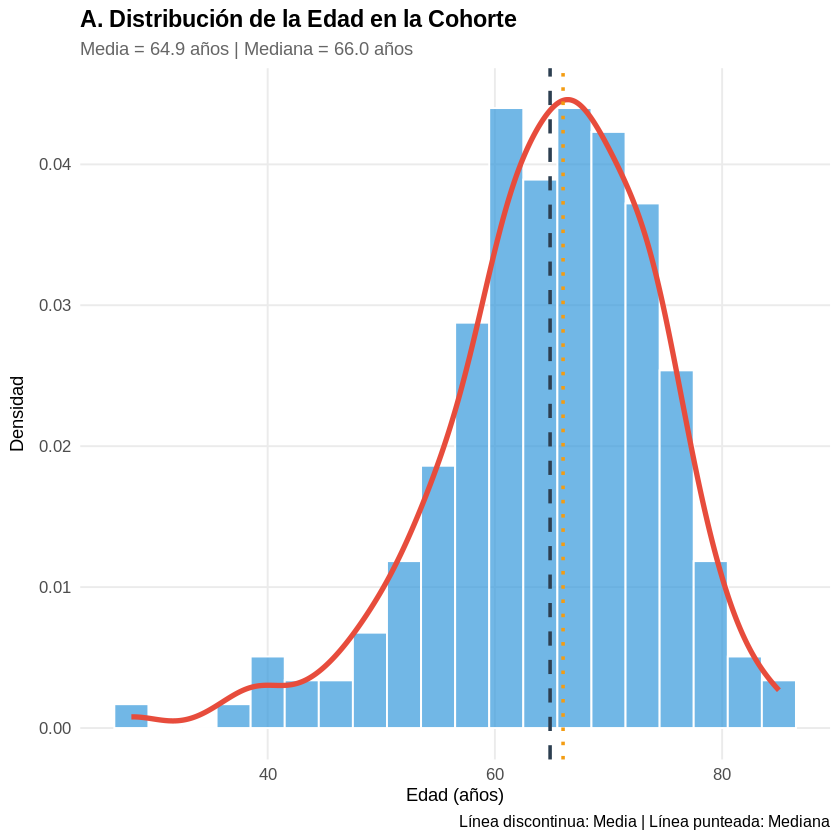

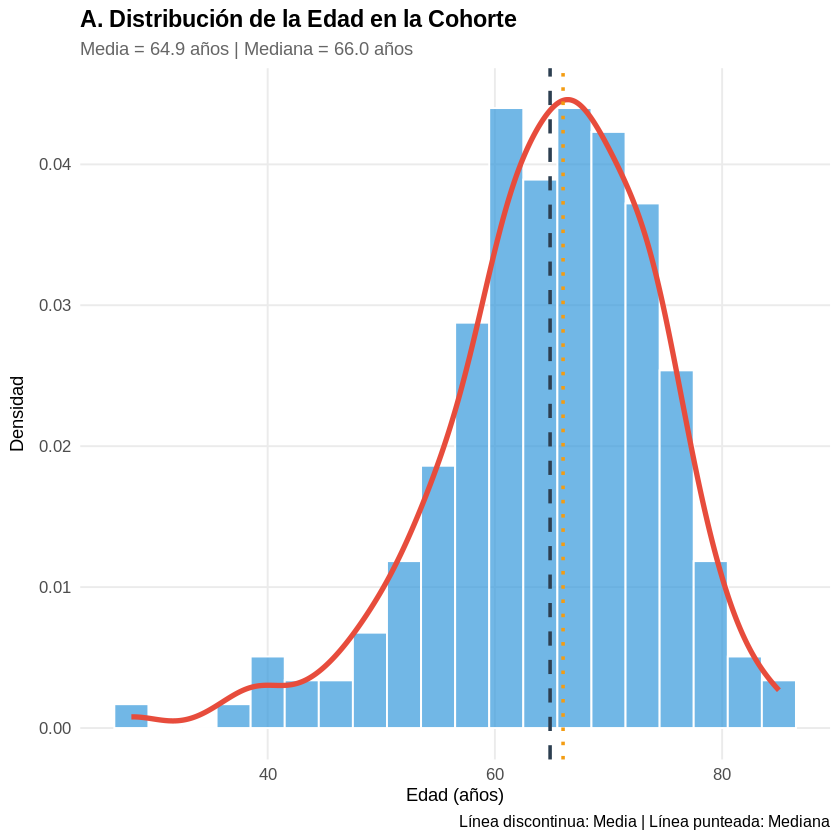

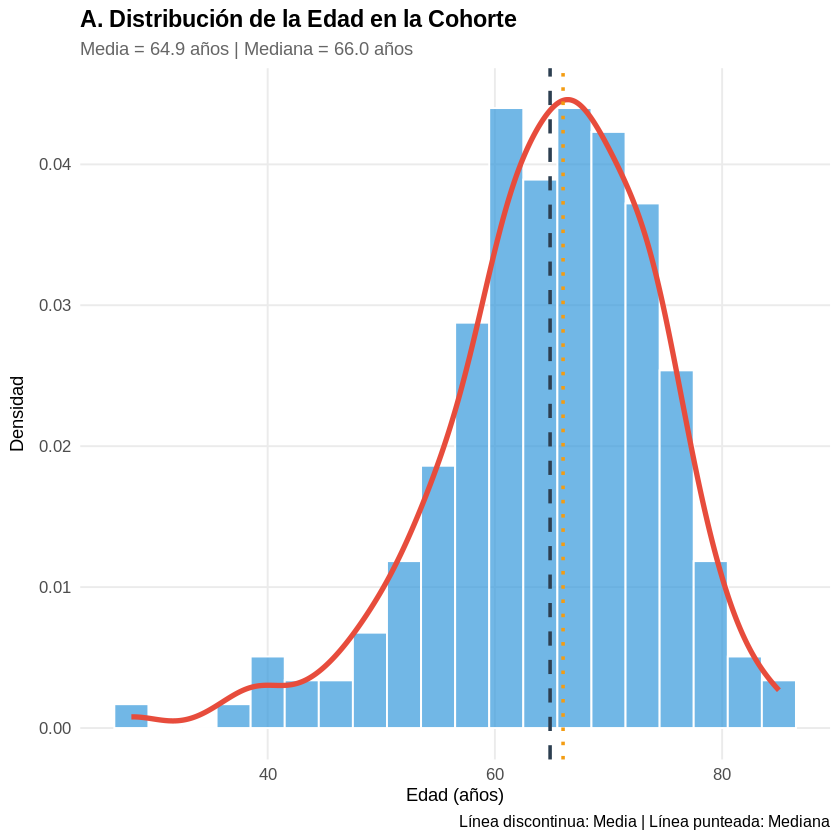

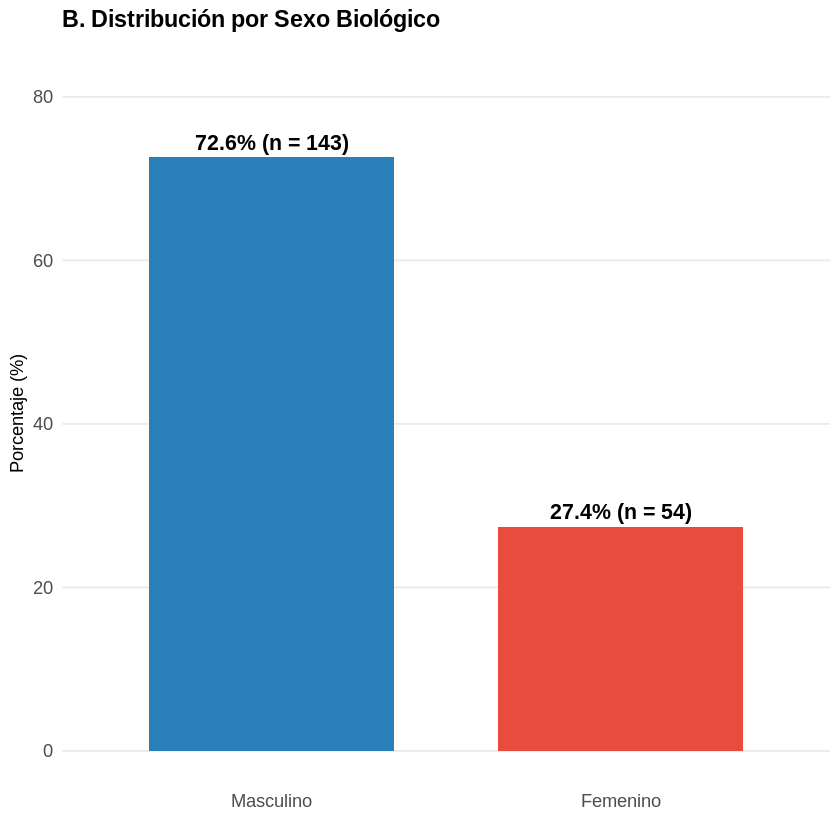

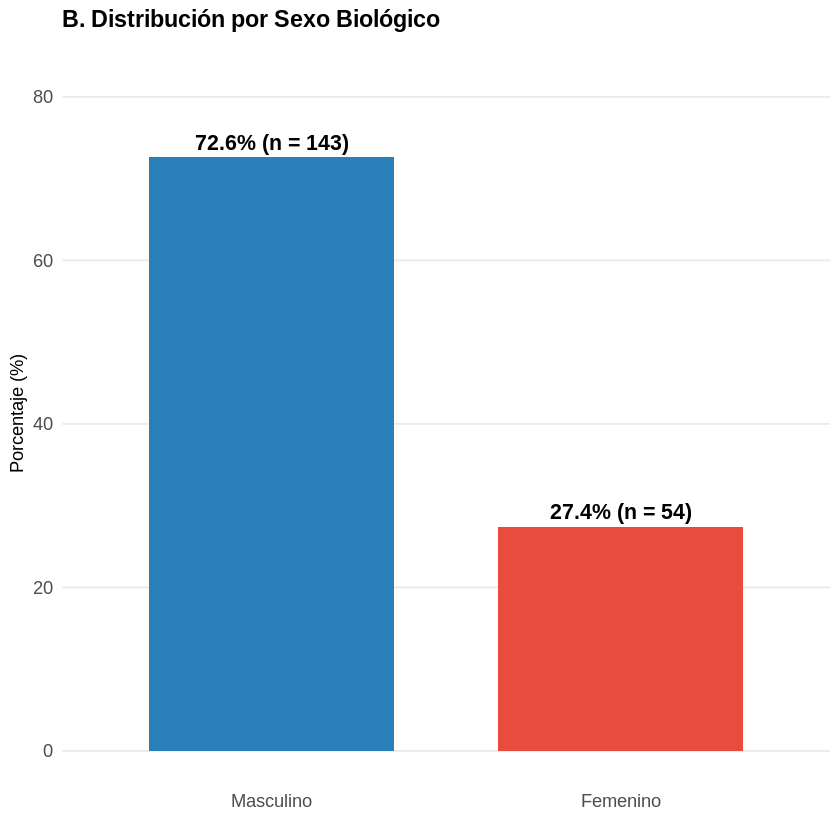

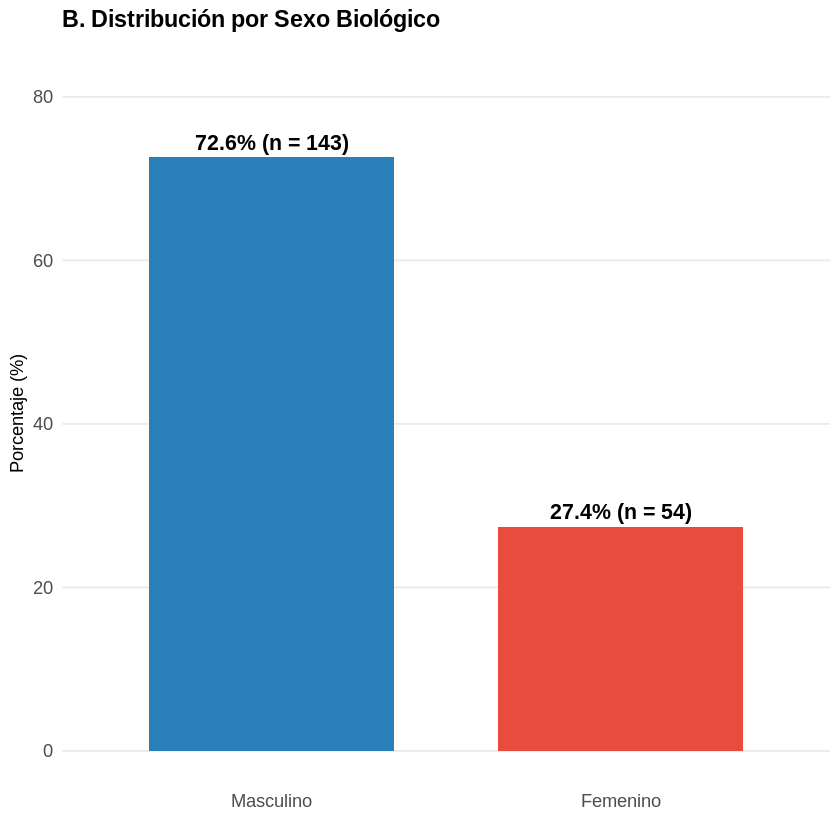

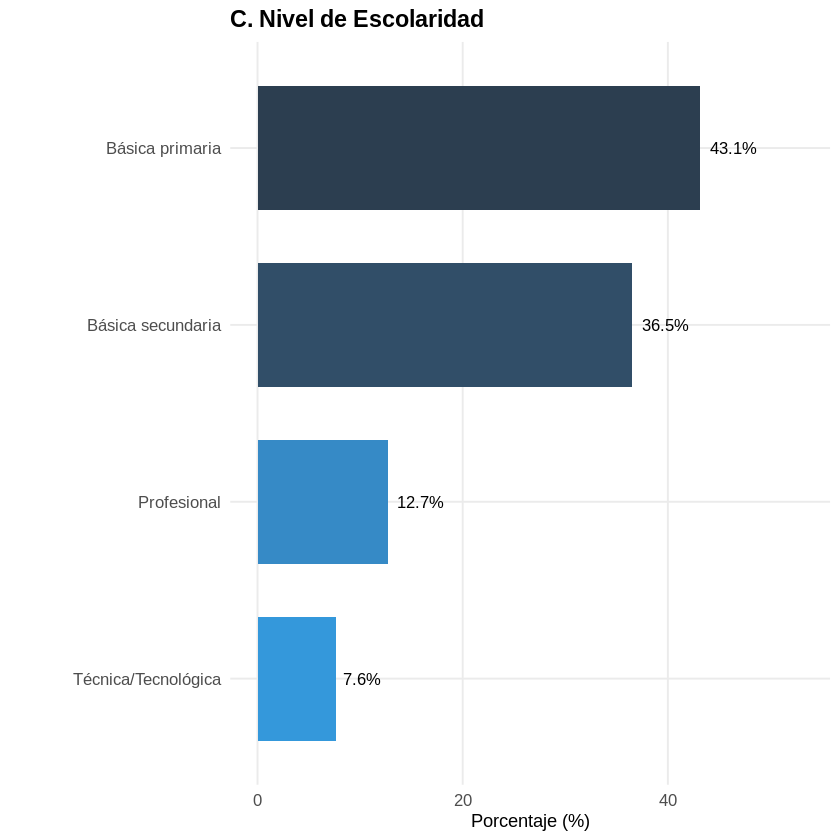

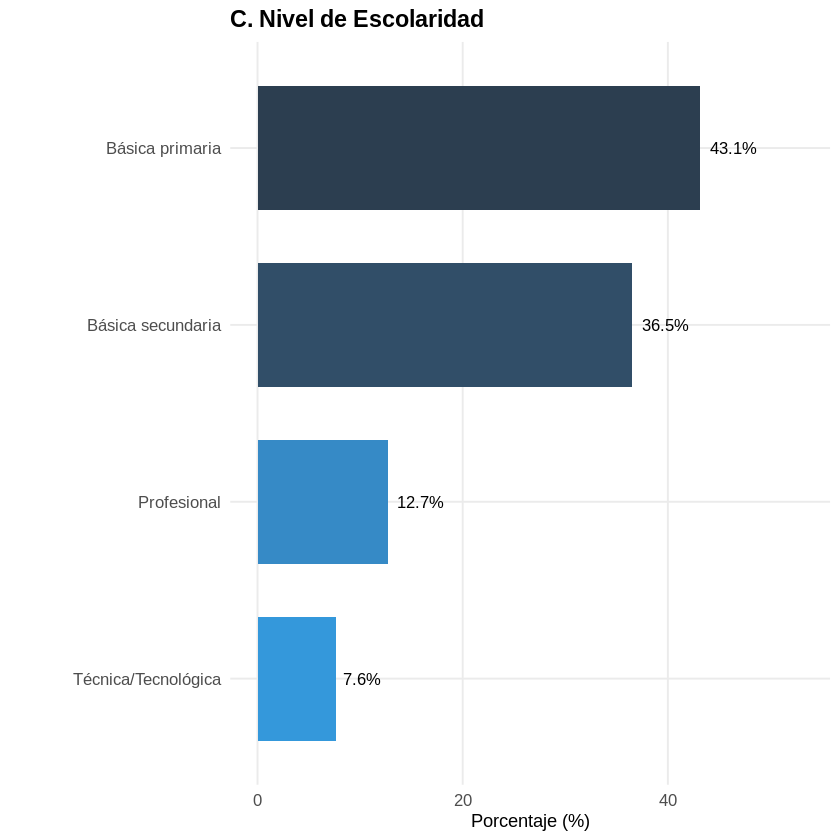

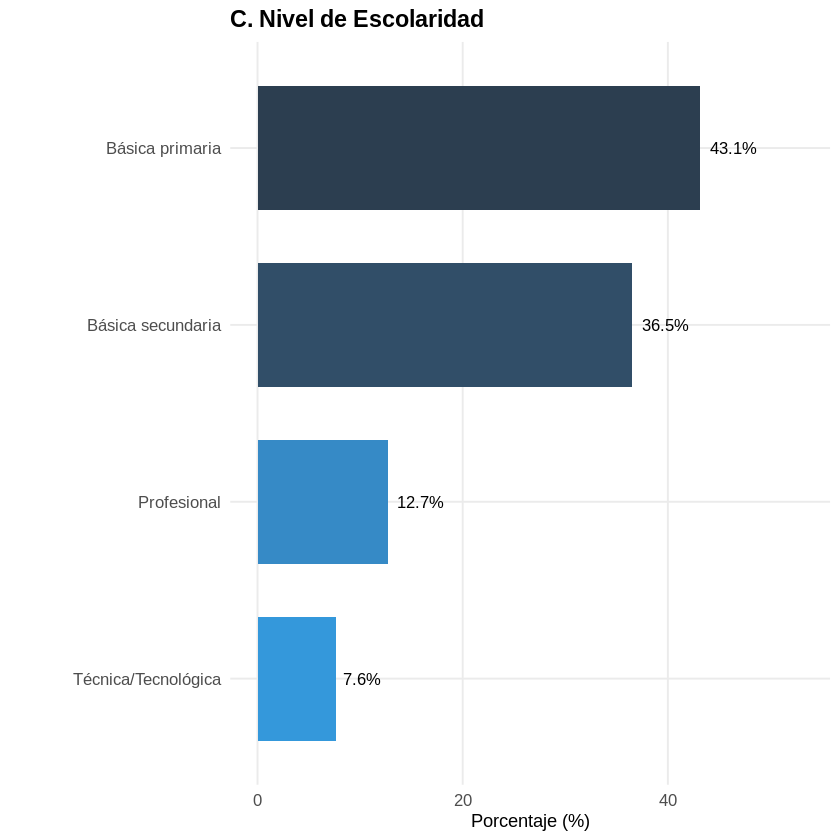

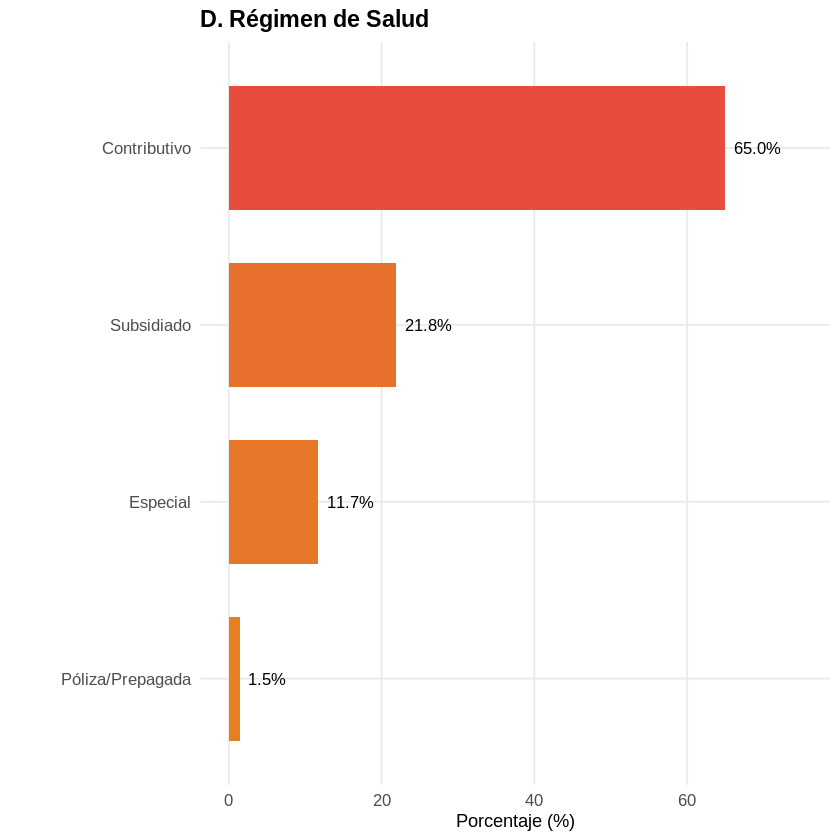

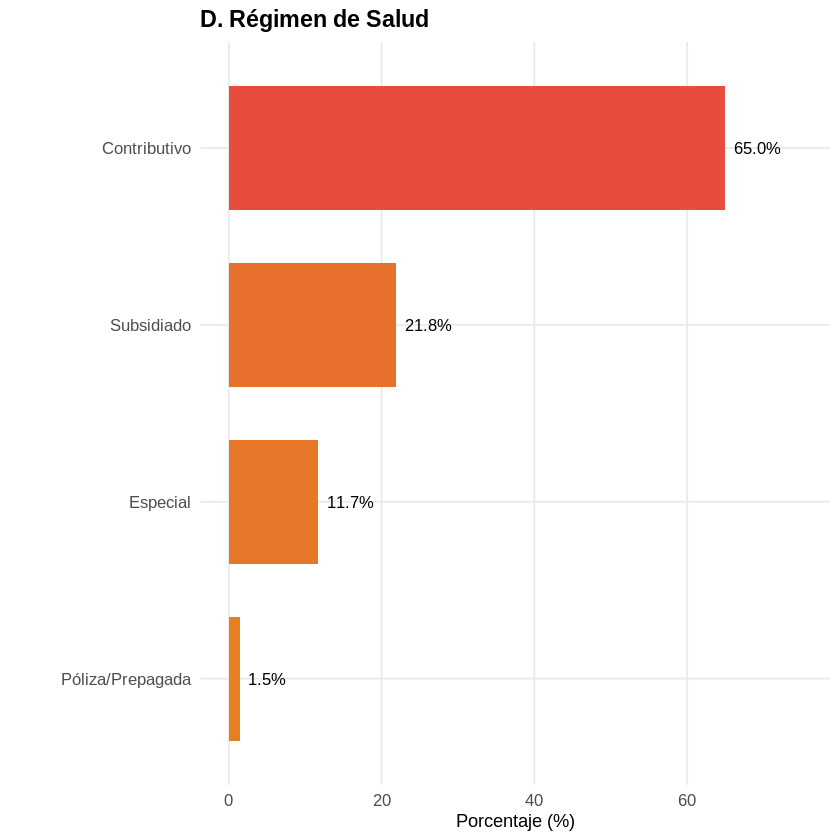

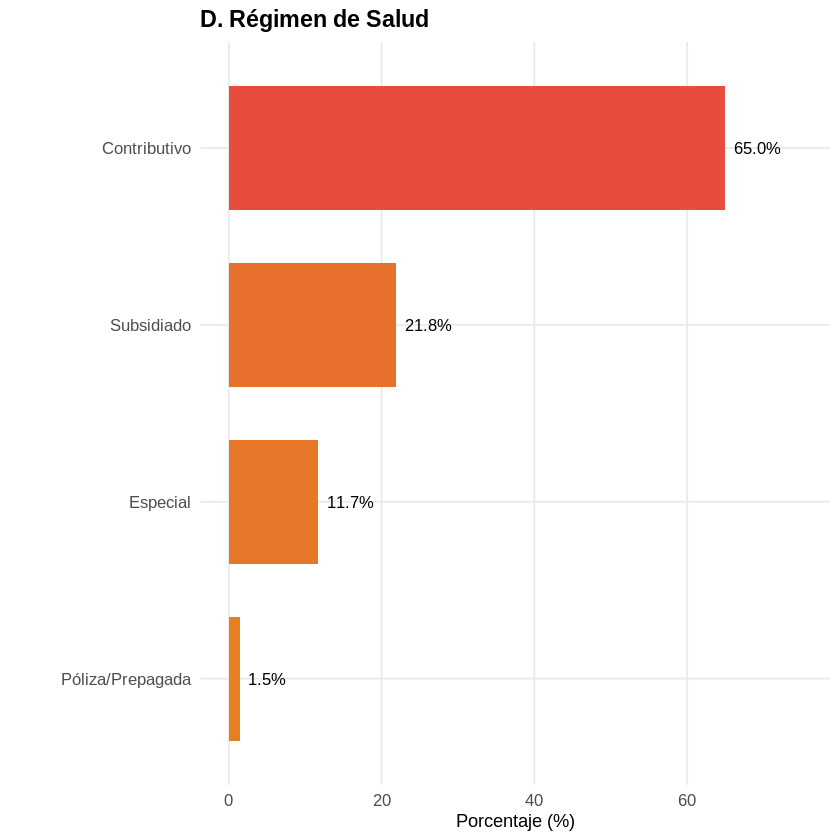




=== 4.1.5 RESUMEN EJECUTIVO ===
=== 4.1.5 RESUMEN EJECUTIVO ===
=== 4.1.5 RESUMEN EJECUTIVO ===

📊 RESUMEN DE LA COHORTE:

📊 RESUMEN DE LA COHORTE:

📊 RESUMEN DE LA COHORTE:
 • Total de pacientes: 197
 • Total de pacientes: 197
 • Total de pacientes: 197
 • Edad media: 64.9 ± 9.4 años
 • Edad media: 64.9 ± 9.4 años
 • Edad media: 64.9 ± 9.4 años
 • Rango de edad: 28 - 85 años
 • Rango de edad: 28 - 85 años
 • Rango de edad: 28 - 85 años

📊 DISTRIBUCIÓN POR SEXO:

📊 DISTRIBUCIÓN POR SEXO:

📊 DISTRIBUCIÓN POR SEXO:
 • Masculino: 143 (72.6%)
 • Femenino: 54 (27.4%)
 • Masculino: 143 (72.6%)
 • Femenino: 54 (27.4%)
 • Masculino: 143 (72.6%)
 • Femenino: 54 (27.4%)

📊 RÉGIMEN DE SALUD PREDOMINANTE:

📊 RÉGIMEN DE SALUD PREDOMINANTE:

📊 RÉGIMEN DE SALUD PREDOMINANTE:
 • Contributivo: 128 pacientes (65.0%)
 • Contributivo: 128 pacientes (65.0%)
 • Contributivo: 128 pacientes (65.0%)

📊 NIVEL EDUCATIVO PREDOMINANTE:

📊 NIVEL EDUCATIVO PREDOMINANTE:

📊 NIVEL EDUCATIVO PREDOMINANTE:
 • Básica 

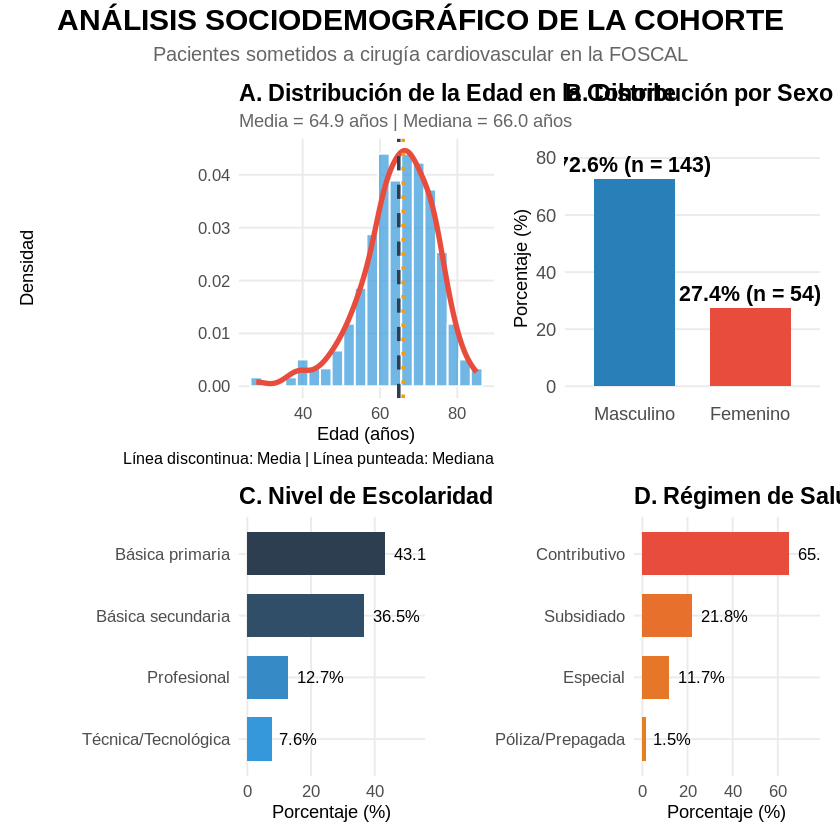

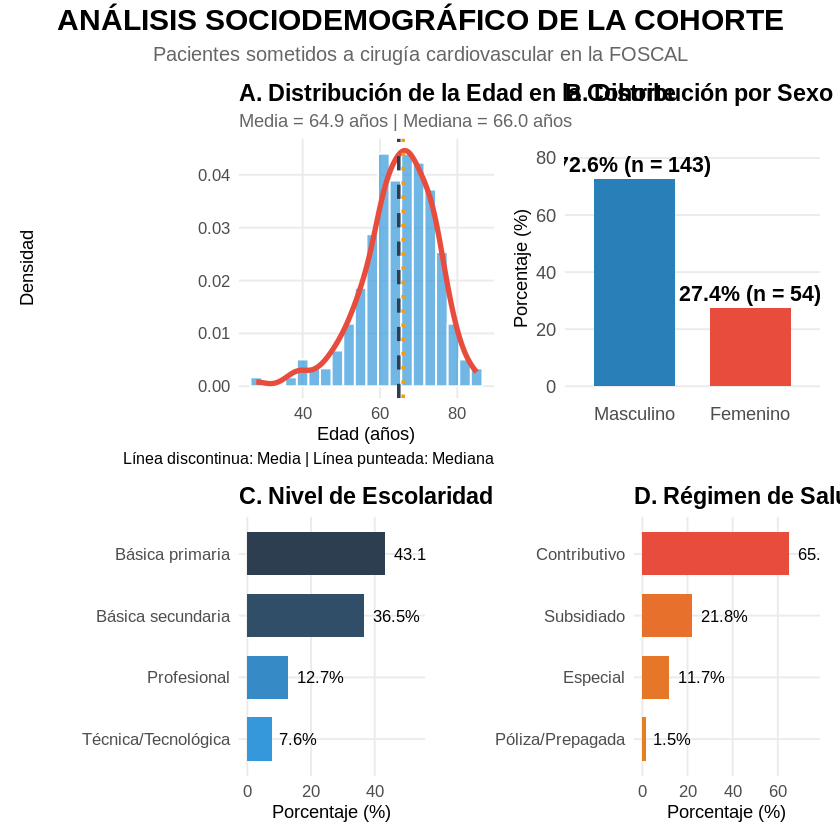

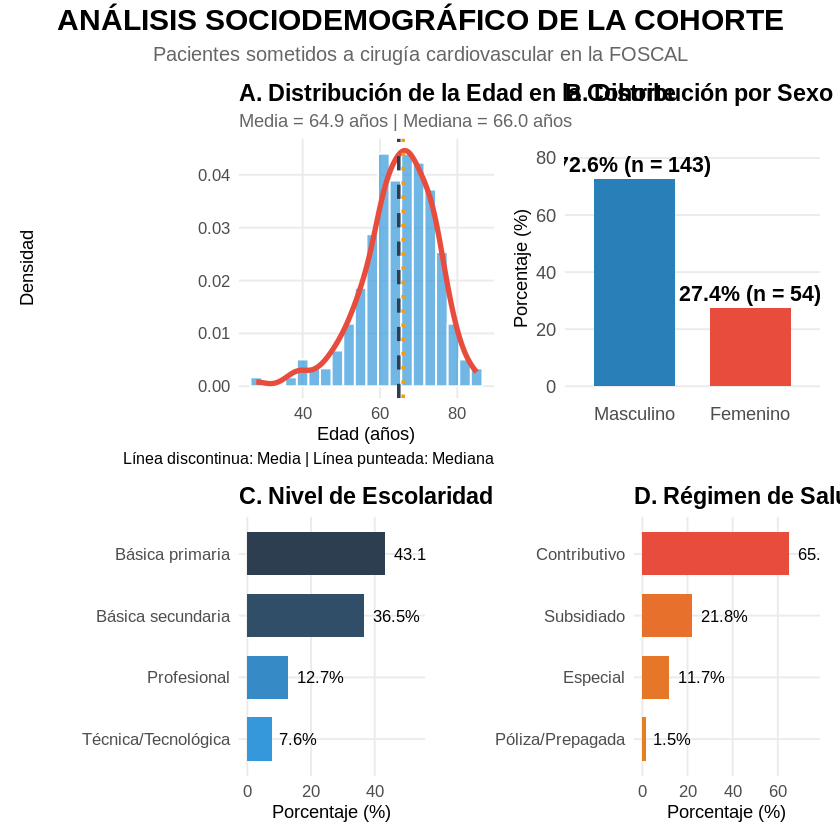

In [4]:
# ==============================================================================
# 4.1 ANÁLISIS DESCRIPTIVO Y TABLA 1
# ==============================================================================

# ------------------------------------------------------------------------------
# 4.1.1 EVALUACIÓN DE NORMALIDAD (EDAD)
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 4.1.1 EVALUACIÓN DE NORMALIDAD ===\n")
cat(rep("=", 80), "\n", sep = "")

# Prueba de Shapiro-Wilk para edad
shapiro_edad <- shapiro.test(datos_icb_clean$edad)

cat("\n📊 PRUEBA DE SHAPIRO-WILK PARA EDAD:\n")
cat(sprintf(" • Estadístico W: %.4f\n", shapiro_edad$statistic))
cat(sprintf(" • p-valor: %.4f\n", shapiro_edad$p.value))

# Decisión sobre normalidad
if (shapiro_edad$p.value > 0.05) {
  cat(" ✅ Distribución NORMAL (p > 0.05)\n")
  cat(" → Reportar: Media ± Desviación Estándar\n")
  media_edad <- mean(datos_icb_clean$edad, na.rm = TRUE)
  sd_edad <- sd(datos_icb_clean$edad, na.rm = TRUE)
  cat(sprintf(" → Edad: %.1f ± %.1f años\n", media_edad, sd_edad))
  usar_media <- TRUE
} else {
  cat(" ⚠️ Distribución NO NORMAL (p < 0.05)\n")
  cat(" → Reportar: Mediana [RIC]\n")
  mediana_edad <- median(datos_icb_clean$edad, na.rm = TRUE)
  q1_edad <- quantile(datos_icb_clean$edad, 0.25, na.rm = TRUE)
  q3_edad <- quantile(datos_icb_clean$edad, 0.75, na.rm = TRUE)
  cat(sprintf(" → Edad: %.1f [%.1f - %.1f] años\n", mediana_edad, q1_edad, q3_edad))
  usar_media <- FALSE
}

# ------------------------------------------------------------------------------
# 4.1.2 ESTADÍSTICAS DESCRIPTIVAS POR VARIABLE
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 4.1.2 ESTADÍSTICAS DESCRIPTIVAS POR VARIABLE ===\n")
cat(rep("=", 80), "\n", sep = "")

# 4.1.2.1 EDAD (Cuantitativa continua)
cat("\n📊 EDAD (Cuantitativa continua)\n")
cat("-", 40, "\n", sep = "")

edad_stats <- datos_icb_clean %>%
  summarize(
    n = n(),
    Media = round(mean(edad, na.rm = TRUE), 1),
    DE = round(sd(edad, na.rm = TRUE), 1),
    Mediana = round(median(edad, na.rm = TRUE), 1),
    Q1 = round(quantile(edad, 0.25, na.rm = TRUE), 1),
    Q3 = round(quantile(edad, 0.75, na.rm = TRUE), 1),
    Min = min(edad, na.rm = TRUE),
    Max = max(edad, na.rm = TRUE),
    `% NA` = round(sum(is.na(edad))/n()*100, 1)
  )
print(edad_stats)

# 4.1.2.2 SEXO BIOLÓGICO (Cualitativa nominal dicotómica)
cat("\n📊 SEXO BIOLÓGICO (Cualitativa nominal dicotómica)\n")
cat("-", 40, "\n", sep = "")

sexo_table <- datos_icb_clean %>%
  group_by(sexo) %>%
  summarize(
    n = n(),
    Porcentaje = round(n/nrow(datos_icb_clean)*100, 1)
  ) %>%
  mutate(Porcentaje_Acumulado = cumsum(Porcentaje))
print(sexo_table)

# 4.1.2.3 ESCOLARIDAD (Cualitativa ordinal)
cat("\n📊 ESCOLARIDAD (Cualitativa ordinal)\n")
cat("-", 40, "\n", sep = "")

escolaridad_table <- datos_icb_clean %>%
  group_by(escolaridad_maxima) %>%
  summarize(
    n = n(),
    Porcentaje = round(n/nrow(datos_icb_clean)*100, 1)
  ) %>%
  arrange(desc(n))
print(escolaridad_table)

# 4.1.2.4 SITUACIÓN LABORAL (Cualitativa nominal)
cat("\n📊 SITUACIÓN LABORAL (Cualitativa nominal)\n")
cat("-", 40, "\n", sep = "")

laboral_tabla <- datos_icb_clean %>%
  group_by(situacion_laboral) %>%
  summarise(
    n = n(),
    Porcentaje = round(n/nrow(datos_icb_clean)*100, 1)
  ) %>%
  arrange(desc(n))
print(laboral_tabla)

# 4.1.2.5 ESTADO CIVIL (Cualitativa nominal)
cat("\n📊 ESTADO CIVIL (Cualitativa nominal)\n")
cat("-", 40, "\n", sep = "")

civil_tabla <- datos_icb_clean %>%
  group_by(estado_civil) %>%
  summarise(
    n = n(),
    Porcentaje = round(n/nrow(datos_icb_clean)*100, 1)
  ) %>%
  arrange(desc(n))
print(civil_tabla)

# 4.1.2.6 RÉGIMEN DE SALUD (Cualitativa nominal)
cat("\n📊 RÉGIMEN DE SALUD (Cualitativa nominal)\n")
cat("-", 40, "\n", sep = "")

salud_tabla <- datos_icb_clean %>%
  group_by(regimen_salud) %>%
  summarise(
    n = n(),
    Porcentaje = round(n/nrow(datos_icb_clean)*100, 1)
  ) %>%
  arrange(desc(n))
print(salud_tabla)

# ------------------------------------------------------------------------------
# 4.1.3 TABLA 1: CARACTERÍSTICAS SOCIODEMOGRÁFICAS ESTRATIFICADAS POR SEXO
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 4.1.3 TABLA 1: CARACTERÍSTICAS SOCIODEMOGRÁFICAS ESTRATIFICADAS POR SEXO ===\n")
cat(rep("=", 80), "\n", sep = "")

# Generar tabla con gtsummary
tabla_1_socio <- datos_icb_clean %>%
  select(edad, sexo, escolaridad_maxima, situacion_laboral, estado_civil, regimen_salud) %>%
  tbl_summary(
    by = sexo,
    statistic = list(
      edad ~ "{mean} ({sd})",
      all_categorical() ~ "{n} ({p})"
    ),
    label = list(
      edad ~ "Edad (años)",
      escolaridad_maxima ~ "Nivel de escolaridad",
      situacion_laboral ~ "Situación laboral",
      estado_civil ~ "Estado civil",
      regimen_salud ~ "Régimen de salud"
    ),
    missing_text = "Datos no reportados",
    digits = list(
      edad ~ c(1, 1),
      all_categorical() ~ c(0, 1)
    )
  ) %>%
  add_overall(last = FALSE) %>%
  add_p(
    test = list(
      edad ~ "t.test"
    ),
    pvalue_fun = ~ style_pvalue(.x, digits = 3)
  ) %>%
  modify_header(
    label = "**Característica**",
    stat_0 = "**Total**\\nN = {N}",
    stat_1 = "**Masculino**\\nN = {n}",
    stat_2 = "**Femenino**\\nN = {n}"
  ) %>%
  bold_labels() %>%
  italicize_levels() %>%
  modify_footnote(
    all_stat_cols() ~ "Media (DE) para edad; n (%) para variables categóricas"
  )

# Mostrar tabla
if (interactive()) {
  tabla_1_socio
} else {
  cat("\n📋 TABLA 1 (formato texto):\n")
  tabla_1_texto <- tabla_1_socio %>% as_tibble()
  print(tabla_1_texto)
}

# ------------------------------------------------------------------------------
# 4.1.4 GRÁFICOS DE DISTRIBUCIÓN
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 4.1.4 GENERANDO GRÁFICOS DE DISTRIBUCIÓN ===\n")
cat(rep("=", 80), "\n", sep = "")

# 4.1.4.1 Histograma + Densidad para Edad
plot_edad <- ggplot(datos_icb_clean, aes(x = edad)) +
  geom_histogram(aes(y = ..density..), bins = 20,
                 fill = "#3498db", color = "white", alpha = 0.7) +
  geom_density(color = "#e74c3c", size = 1.5) +
  geom_vline(aes(xintercept = mean(edad, na.rm = TRUE)),
             color = "#2c3e50", linetype = "dashed", size = 1) +
  geom_vline(aes(xintercept = median(edad, na.rm = TRUE)),
             color = "#f39c12", linetype = "dotted", size = 1) +
  labs(
    title = "A. Distribución de la Edad en la Cohorte",
    subtitle = sprintf("Media = %.1f años | Mediana = %.1f años",
                       mean(datos_icb_clean$edad, na.rm = TRUE),
                       median(datos_icb_clean$edad, na.rm = TRUE)),
    x = "Edad (años)",
    y = "Densidad",
    caption = "Línea discontinua: Media | Línea punteada: Mediana"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 11, color = "gray40"),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    panel.grid.minor = element_blank()
  )

# 4.1.4.2 Gráfico de Barras para Sexo
plot_sexo <- datos_icb_clean %>%
  filter(!is.na(sexo)) %>%
  count(sexo) %>%
  mutate(porcentaje = n / sum(n) * 100) %>%
  ggplot(aes(x = sexo, y = porcentaje, fill = sexo)) +
  geom_bar(stat = "identity", show.legend = FALSE, width = 0.7) +
  geom_text(aes(label = sprintf("%.1f%% (n = %d)", porcentaje, n)),
            vjust = -0.5, size = 4.5, fontface = "bold") +
  scale_fill_manual(values = c("Masculino" = "#2980b9", "Femenino" = "#e74c3c")) +
  labs(
    title = "B. Distribución por Sexo Biológico",
    x = "",
    y = "Porcentaje (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 11),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank()
  ) +
  ylim(0, max(datos_icb_clean %>% filter(!is.na(sexo)) %>% count(sexo) %>%
                mutate(p = n/sum(n)*100) %>% pull(p)) + 10)

# 4.1.4.3 Gráfico de Barras Horizontales para Escolaridad
plot_escolaridad <- datos_icb_clean %>%
  filter(!is.na(escolaridad_maxima)) %>%
  count(escolaridad_maxima) %>%
  mutate(porcentaje = n / sum(n) * 100,
         escolaridad_maxima = fct_reorder(escolaridad_maxima, n)) %>%
  ggplot(aes(x = escolaridad_maxima, y = porcentaje, fill = porcentaje)) +
  geom_bar(stat = "identity", show.legend = FALSE, width = 0.7) +
  geom_text(aes(label = sprintf("%.1f%%", porcentaje)),
            hjust = -0.2, size = 3.5) +
  coord_flip() +
  scale_fill_gradient(low = "#3498db", high = "#2c3e50") +
  labs(
    title = "C. Nivel de Escolaridad",
    x = "",
    y = "Porcentaje (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    panel.grid.minor = element_blank()
  ) +
  ylim(0, max(datos_icb_clean %>% filter(!is.na(escolaridad_maxima)) %>%
                count(escolaridad_maxima) %>% mutate(p = n/sum(n)*100) %>% pull(p)) + 10)

# 4.1.4.4 Gráfico de Barras Horizontales para Régimen de Salud
plot_salud <- datos_icb_clean %>%
  filter(!is.na(regimen_salud)) %>%
  count(regimen_salud) %>%
  mutate(porcentaje = n / sum(n) * 100,
         regimen_salud = fct_reorder(regimen_salud, n)) %>%
  ggplot(aes(x = regimen_salud, y = porcentaje, fill = porcentaje)) +
  geom_bar(stat = "identity", show.legend = FALSE, width = 0.7) +
  geom_text(aes(label = sprintf("%.1f%%", porcentaje)),
            hjust = -0.2, size = 3.5) +
  coord_flip() +
  scale_fill_gradient(low = "#e67e22", high = "#e74c3c") +
  labs(
    title = "D. Régimen de Salud",
    x = "",
    y = "Porcentaje (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    panel.grid.minor = element_blank()
  ) +
  ylim(0, max(datos_icb_clean %>% filter(!is.na(regimen_salud)) %>%
                count(regimen_salud) %>% mutate(p = n/sum(n)*100) %>% pull(p)) + 10)

# 4.1.4.5 Gráficos combinados
graficos_combinados <- (plot_edad + plot_sexo) / (plot_escolaridad + plot_salud) +
  plot_annotation(
    title = "ANÁLISIS SOCIODEMOGRÁFICO DE LA COHORTE",
    subtitle = "Pacientes sometidos a cirugía cardiovascular en la FOSCAL",
    theme = theme(
      plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
      plot.subtitle = element_text(size = 12, hjust = 0.5, color = "gray40")
    )
  )

# Mostrar gráficos
print(plot_edad)
print(plot_sexo)
print(plot_escolaridad)
print(plot_salud)
print(graficos_combinados)

# ------------------------------------------------------------------------------
# 4.1.5 RESUMEN EJECUTIVO
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 4.1.5 RESUMEN EJECUTIVO ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📊 RESUMEN DE LA COHORTE:\n")
cat(sprintf(" • Total de pacientes: %d\n", nrow(datos_icb_clean)))
cat(sprintf(" • Edad media: %.1f ± %.1f años\n",
            mean(datos_icb_clean$edad, na.rm = TRUE),
            sd(datos_icb_clean$edad, na.rm = TRUE)))
cat(sprintf(" • Rango de edad: %.0f - %.0f años\n",
            min(datos_icb_clean$edad, na.rm = TRUE),
            max(datos_icb_clean$edad, na.rm = TRUE)))

cat("\n📊 DISTRIBUCIÓN POR SEXO:\n")
sexo_counts <- table(datos_icb_clean$sexo, useNA = "ifany")
sexo_pct <- round(prop.table(sexo_counts) * 100, 1)
for (i in 1:length(sexo_counts)) {
  cat(sprintf(" • %s: %d (%.1f%%)\n",
              names(sexo_counts)[i], sexo_counts[i], sexo_pct[i]))
}

cat("\n📊 RÉGIMEN DE SALUD PREDOMINANTE:\n")
salud_max <- datos_icb_clean %>%
  filter(!is.na(regimen_salud)) %>%
  count(regimen_salud) %>%
  arrange(desc(n)) %>%
  slice(1)
cat(sprintf(" • %s: %d pacientes (%.1f%%)\n",
            salud_max$regimen_salud, salud_max$n,
            salud_max$n/nrow(datos_icb_clean)*100))

cat("\n📊 NIVEL EDUCATIVO PREDOMINANTE:\n")
edu_max <- datos_icb_clean %>%
  filter(!is.na(escolaridad_maxima)) %>%
  count(escolaridad_maxima) %>%
  arrange(desc(n)) %>%
  slice(1)
cat(sprintf(" • %s: %d pacientes (%.1f%%)\n",
            edu_max$escolaridad_maxima, edu_max$n,
            edu_max$n/nrow(datos_icb_clean)*100))

cat("\n✅ Análisis descriptivo completado\n")

In [5]:
# ==============================================================================
# 4.2 EXPORTAR TABLA 1 Y GRÁFICOS
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 4.2 EXPORTANDO RESULTADOS ===\n")
cat(rep("=", 80), "\n", sep = "")

# ------------------------------------------------------------------------------
# 4.2.1 Exportar Tabla 1
# ------------------------------------------------------------------------------

# Tabla en formato Excel
tabla_1_export <- tabla_1_socio %>%
  as_tibble() %>%
  mutate(across(where(is.numeric), ~ round(., 2)))

write_xlsx(tabla_1_export, "tabla_1_sociodemografica.xlsx")
cat("✅ Tabla 1 exportada a 'tabla_1_sociodemografica.xlsx'\n")

# Tabla en formato CSV
write.csv2(tabla_1_export, "tabla_1_sociodemografica.csv", row.names = FALSE)
cat("✅ Tabla 1 exportada a 'tabla_1_sociodemografica.csv'\n")

# Tabla en formato texto
sink("tabla_1_texto.txt")
cat("=============================================================================\n")
cat("TABLA 1: CARACTERÍSTICAS SOCIODEMOGRÁFICAS DE LA COHORTE\n")
cat("=============================================================================\n")
print(tabla_1_socio)
cat("\n=============================================================================\n")
sink()
cat("✅ Tabla 1 exportada a 'tabla_1_texto.txt'\n")

# ------------------------------------------------------------------------------
# 4.2.2 Exportar Gráficos
# ------------------------------------------------------------------------------

# Gráficos combinados
ggsave(
  filename = "graficos_sociodemograficos.pdf",
  plot = graficos_combinados,
  width = 14,
  height = 10,
  dpi = 300,
  device = "pdf"
)
cat("✅ Gráficos combinados exportados a 'graficos_sociodemograficos.pdf'\n")

# Gráficos individuales
ggsave(
  filename = "grafico_edad.pdf",
  plot = plot_edad,
  width = 8,
  height = 6,
  dpi = 300,
  device = "pdf"
)
cat("✅ Gráfico de edad exportado a 'grafico_edad.pdf'\n")

ggsave(
  filename = "grafico_sexo.pdf",
  plot = plot_sexo,
  width = 8,
  height = 6,
  dpi = 300,
  device = "pdf"
)
cat("✅ Gráfico de sexo exportado a 'grafico_sexo.pdf'\n")

ggsave(
  filename = "grafico_escolaridad.pdf",
  plot = plot_escolaridad,
  width = 8,
  height = 6,
  dpi = 300,
  device = "pdf"
)
cat("✅ Gráfico de escolaridad exportado a 'grafico_escolaridad.pdf'\n")

ggsave(
  filename = "grafico_regimen_salud.pdf",
  plot = plot_salud,
  width = 8,
  height = 6,
  dpi = 300,
  device = "pdf"
)
cat("✅ Gráfico de régimen de salud exportado a 'grafico_regimen_salud.pdf'\n")

cat("\n📁 ARCHIVOS GENERADOS:\n")
cat("  GRÁFICOS:\n")
cat("  1. graficos_sociodemograficos.pdf - Gráficos combinados\n")
cat("  2. grafico_edad.pdf - Histograma de edad\n")
cat("  3. grafico_sexo.pdf - Barras de sexo\n")
cat("  4. grafico_escolaridad.pdf - Barras de escolaridad\n")
cat("  5. grafico_regimen_salud.pdf - Barras de régimen de salud\n")
cat("  TABLAS:\n")
cat("  6. tabla_1_sociodemografica.xlsx - Tabla 1 en Excel\n")
cat("  7. tabla_1_sociodemografica.csv - Tabla 1 en CSV\n")
cat("  8. tabla_1_texto.txt - Tabla 1 en texto\n")

cat("\n✅ PASO 4 COMPLETADO EXITOSAMENTE\n")


=== 4.2 EXPORTANDO RESULTADOS ===
✅ Tabla 1 exportada a 'tabla_1_sociodemografica.xlsx'
✅ Tabla 1 exportada a 'tabla_1_sociodemografica.xlsx'
✅ Tabla 1 exportada a 'tabla_1_sociodemografica.xlsx'
✅ Tabla 1 exportada a 'tabla_1_sociodemografica.csv'
✅ Tabla 1 exportada a 'tabla_1_sociodemografica.csv'
✅ Tabla 1 exportada a 'tabla_1_sociodemografica.csv'
✅ Tabla 1 exportada a 'tabla_1_texto.txt'
✅ Tabla 1 exportada a 'tabla_1_texto.txt'
✅ Tabla 1 exportada a 'tabla_1_texto.txt'
✅ Gráficos combinados exportados a 'graficos_sociodemograficos.pdf'
✅ Gráficos combinados exportados a 'graficos_sociodemograficos.pdf'
✅ Gráficos combinados exportados a 'graficos_sociodemograficos.pdf'
✅ Gráfico de edad exportado a 'grafico_edad.pdf'
✅ Gráfico de edad exportado a 'grafico_edad.pdf'
✅ Gráfico de edad exportado a 'grafico_edad.pdf'
✅ Gráfico de sexo exportado a 'grafico_sexo.pdf'
✅ Gráfico de sexo exportado a 'grafico_sexo.pdf'
✅ Gráfico de sexo exportado a 'grafico_sexo.pdf'
✅ Gráfico de escolar




=== 5.1.1 ESTADÍSTICAS DESCRIPTIVAS DE SCORES DE RIESGO ===
=== 5.1.1 ESTADÍSTICAS DESCRIPTIVAS DE SCORES DE RIESGO ===
=== 5.1.1 ESTADÍSTICAS DESCRIPTIVAS DE SCORES DE RIESGO ===

📊 RESUMEN DE SCORES DE RIESGO (PROBABILIDAD DECIMAL 0-1):

📊 RESUMEN DE SCORES DE RIESGO (PROBABILIDAD DECIMAL 0-1):

📊 RESUMEN DE SCORES DE RIESGO (PROBABILIDAD DECIMAL 0-1):
-60
-60
-60

📈 EuroSCORE II:
  • Media (DE): 0.0369 (±0.0555)
  • Mediana [RIC]: 0.0169 [0.0110 - 0.0311]
  • Rango: 0.0053 - 0.3735

📈 STS Mortalidad:
  • Media (DE): 0.0191 (±0.0234)
  • Mediana [RIC]: 0.0124 [0.0068 - 0.0218]
  • Rango: 0.0014 - 0.1990

📈 APACHE IV Mortalidad:
  • Media (DE): 0.0163 (±0.0176)
  • Mediana [RIC]: 0.0120 [0.0060 - 0.0190]
  • Rango: 0.0020 - 0.1300

📈 EuroSCORE II:
  • Media (DE): 0.0369 (±0.0555)
  • Mediana [RIC]: 0.0169 [0.0110 - 0.0311]
  • Rango: 0.0053 - 0.3735

📈 STS Mortalidad:
  • Media (DE): 0.0191 (±0.0234)
  • Mediana [RIC]: 0.0124 [0.0068 - 0.0218]
  • Rango: 0.0014 - 0.1990

📈 APACHE I

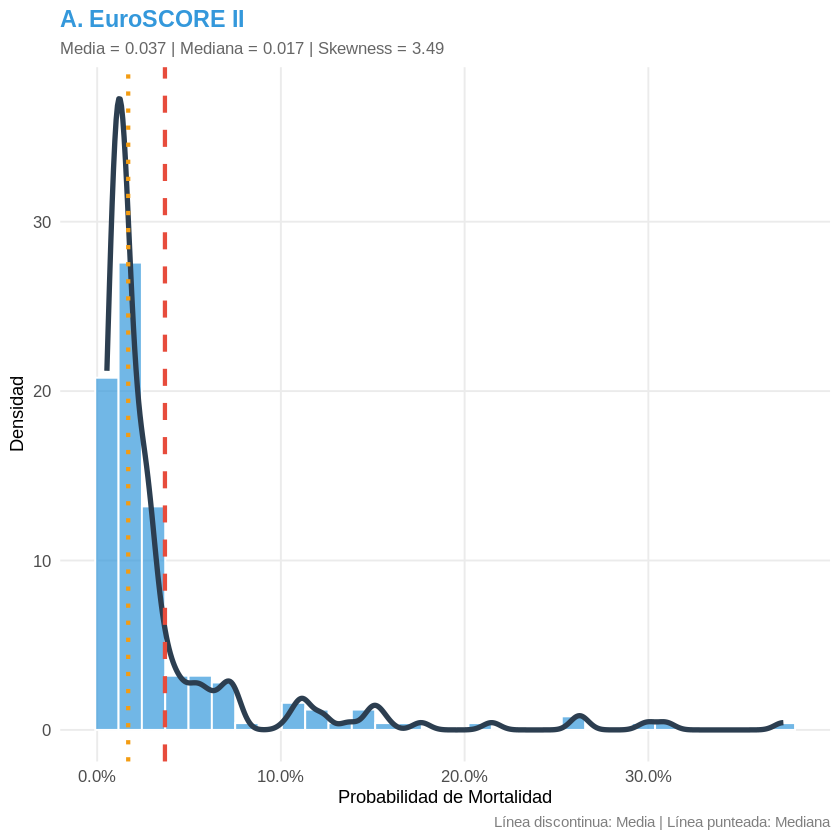

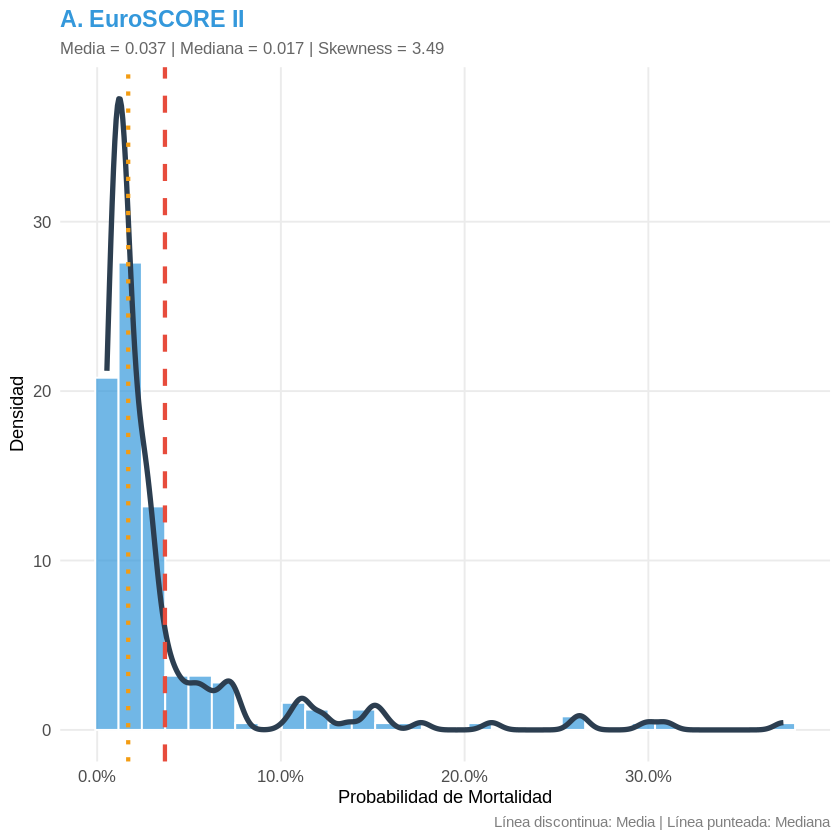

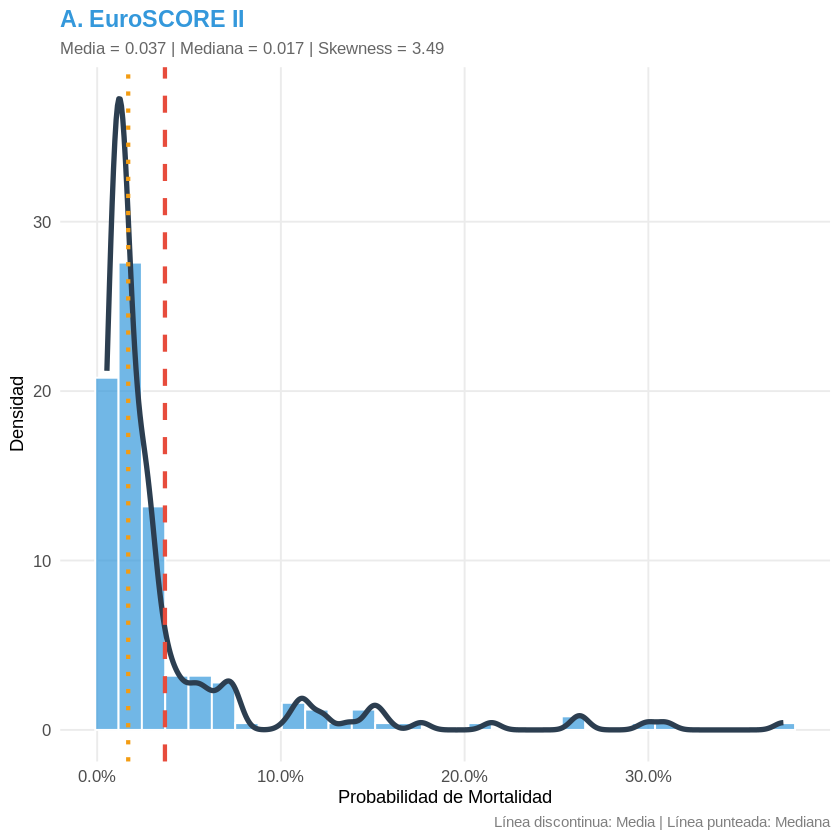

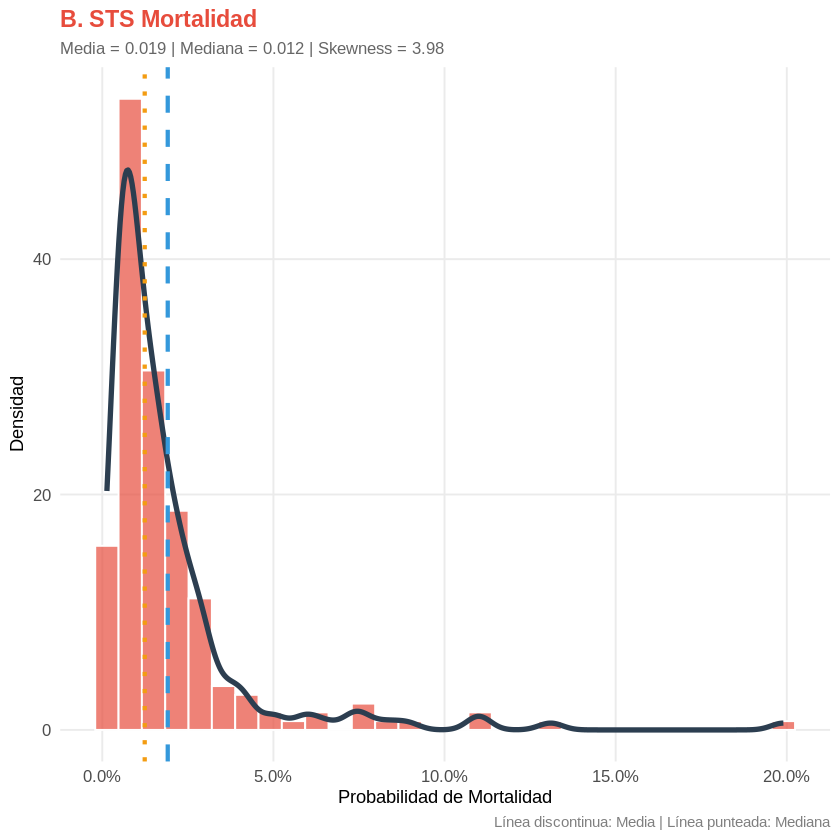

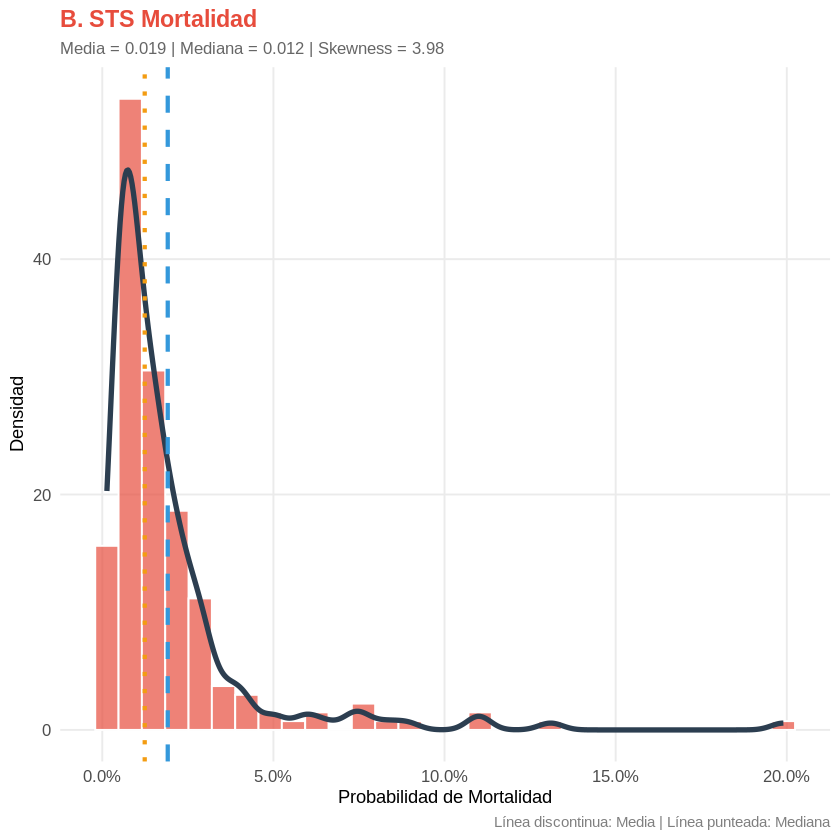

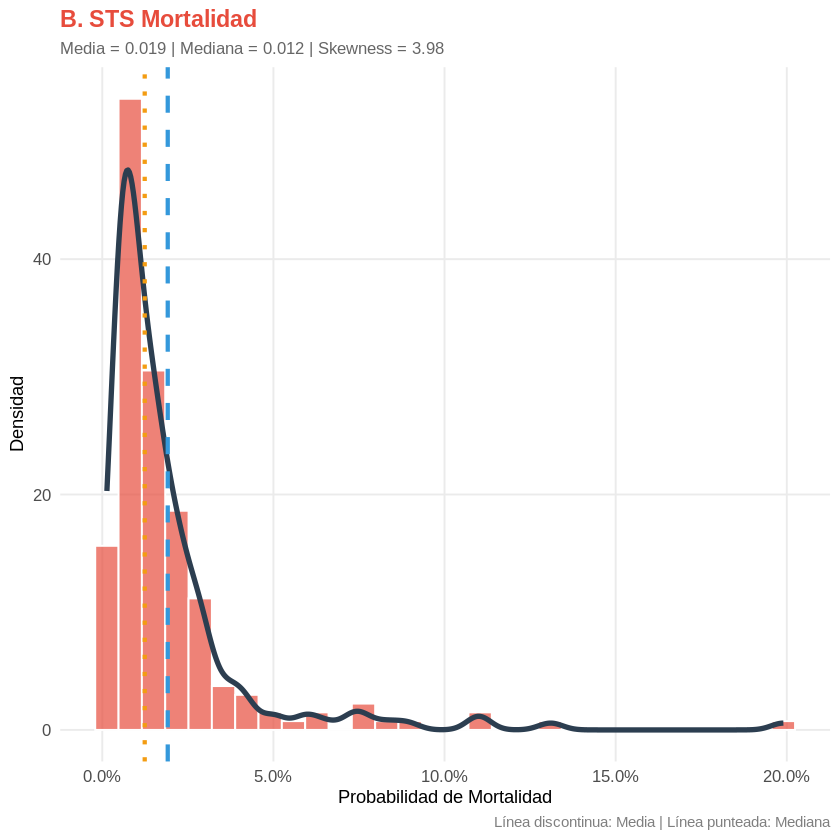

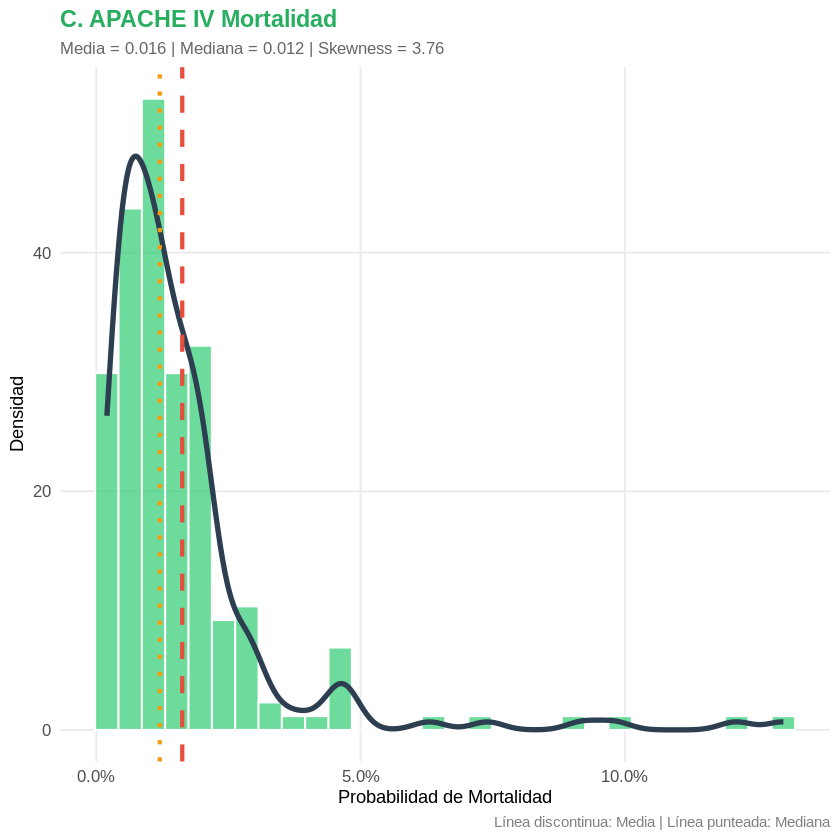

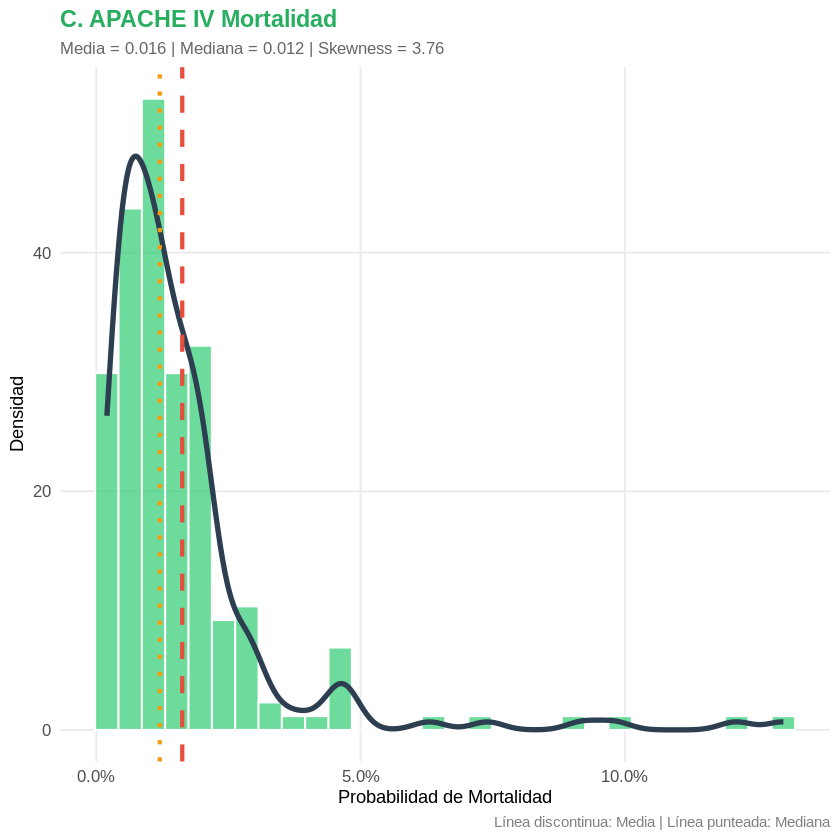

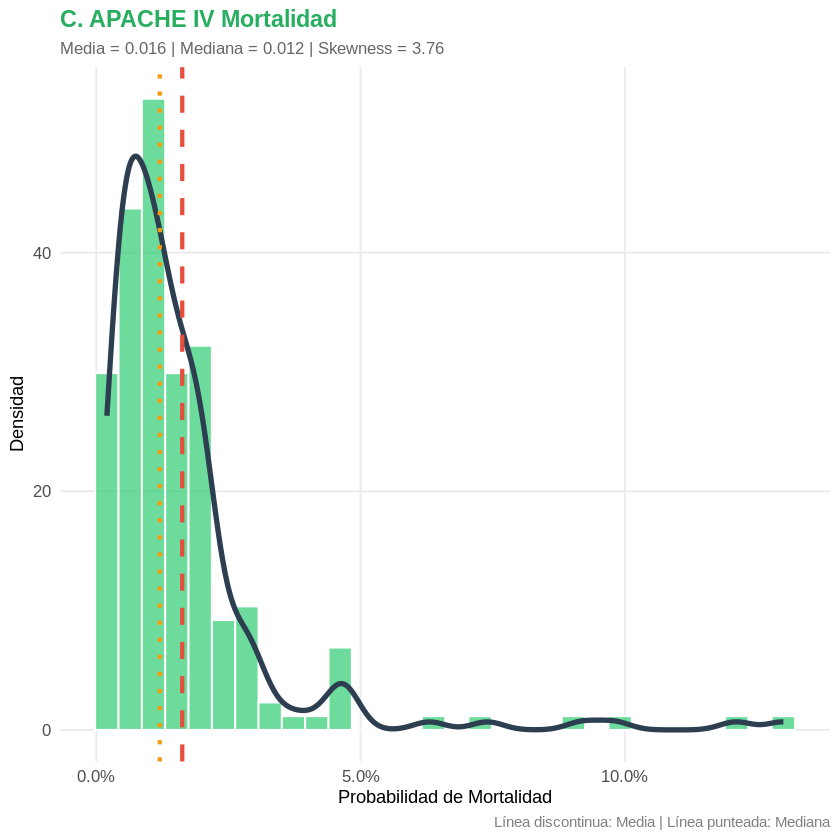




=== 5.1.4 DENSIDADES COMPARATIVAS ===
=== 5.1.4 DENSIDADES COMPARATIVAS ===
=== 5.1.4 DENSIDADES COMPARATIVAS ===


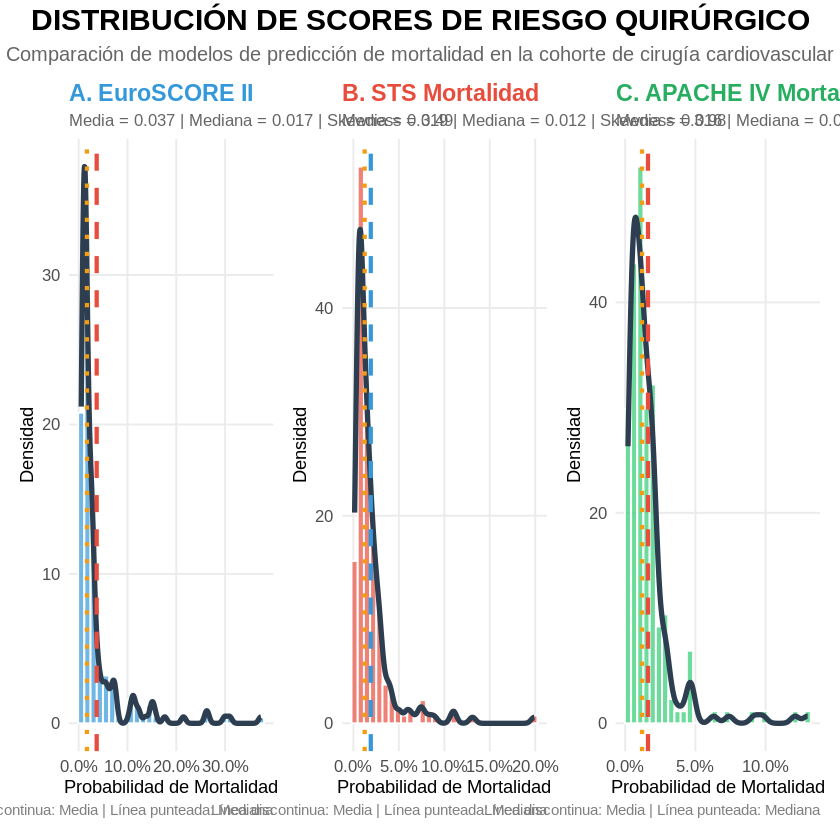

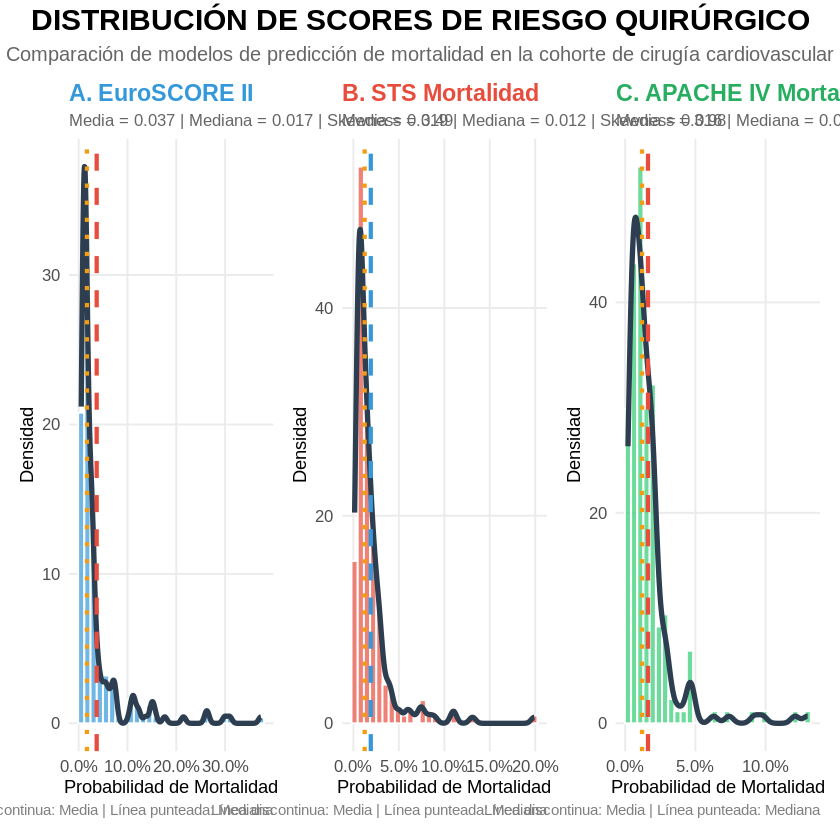

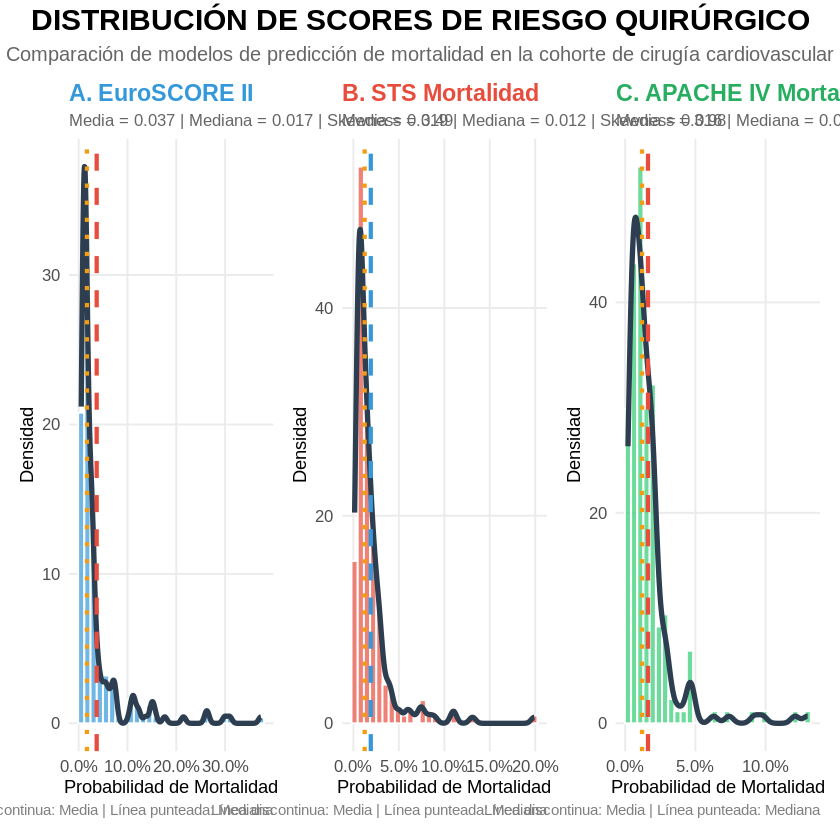

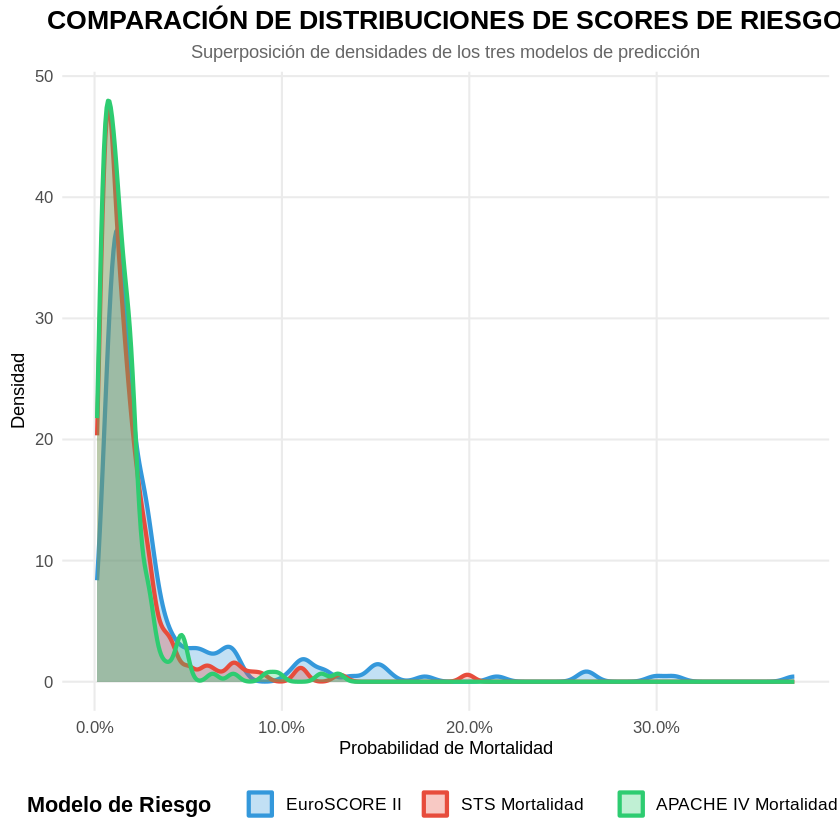

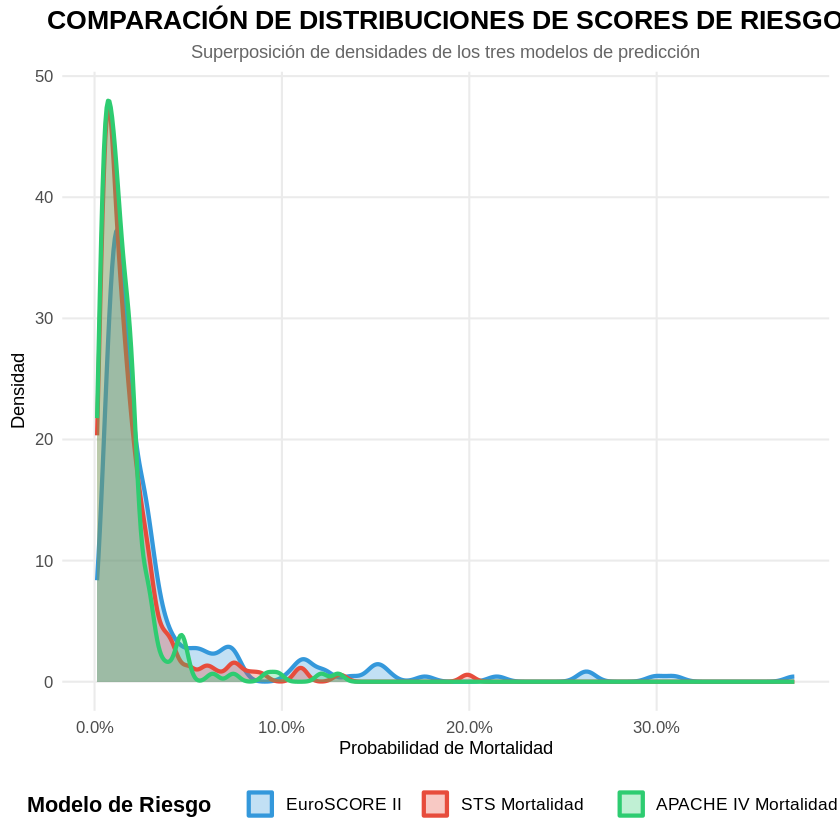

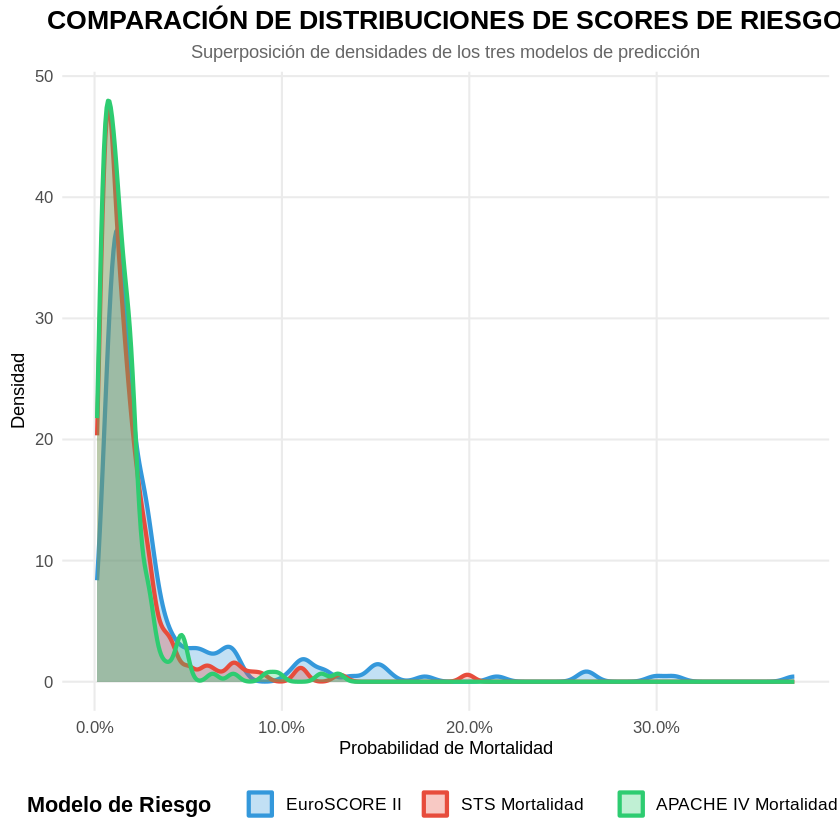




=== 5.1.6 EXPORTANDO RESULTADOS ===
=== 5.1.6 EXPORTANDO RESULTADOS ===
=== 5.1.6 EXPORTANDO RESULTADOS ===
✅ Gráficos de paneles exportados a 'scores_distribucion_paneles.pdf'
✅ Gráficos de paneles exportados a 'scores_distribucion_paneles.pdf'
✅ Gráficos de paneles exportados a 'scores_distribucion_paneles.pdf'
✅ Densidades comparativas exportadas a 'scores_densidades_comparativas.pdf'
✅ Densidades comparativas exportadas a 'scores_densidades_comparativas.pdf'
✅ Densidades comparativas exportadas a 'scores_densidades_comparativas.pdf'
✅ Boxplot comparativo exportado a 'scores_boxplot_comparativo.pdf'
✅ Boxplot comparativo exportado a 'scores_boxplot_comparativo.pdf'
✅ Boxplot comparativo exportado a 'scores_boxplot_comparativo.pdf'
✅ EuroSCORE II exportado a 'scores_euroscore2.pdf'
✅ EuroSCORE II exportado a 'scores_euroscore2.pdf'
✅ EuroSCORE II exportado a 'scores_euroscore2.pdf'
✅ STS Mortalidad exportado a 'scores_sts_mortalidad.pdf'
✅ STS Mortalidad exportado a 'scores_sts_mo

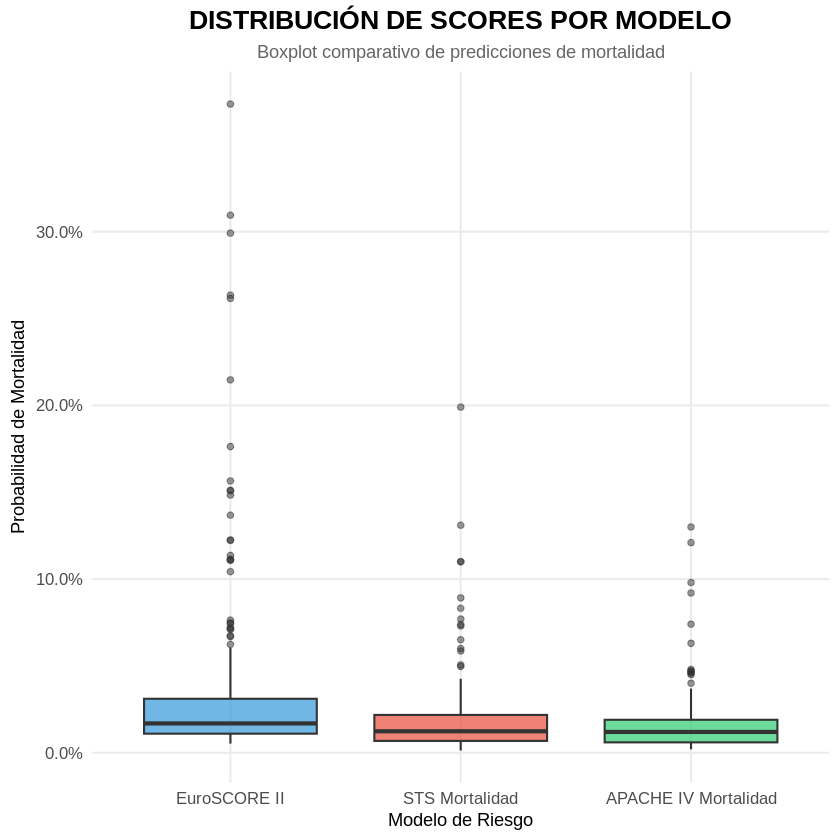

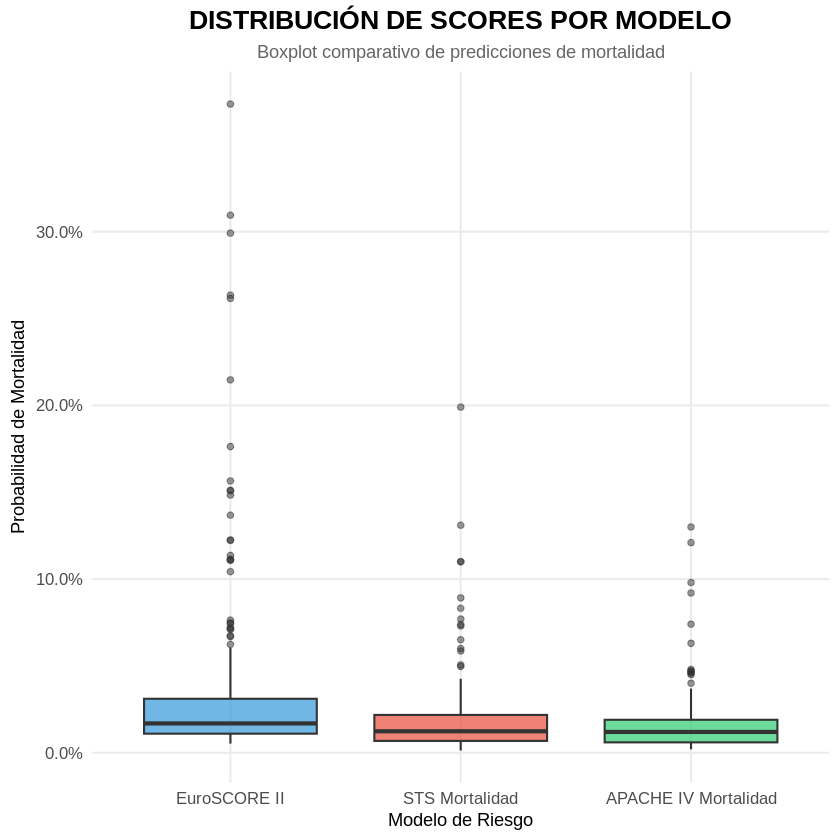

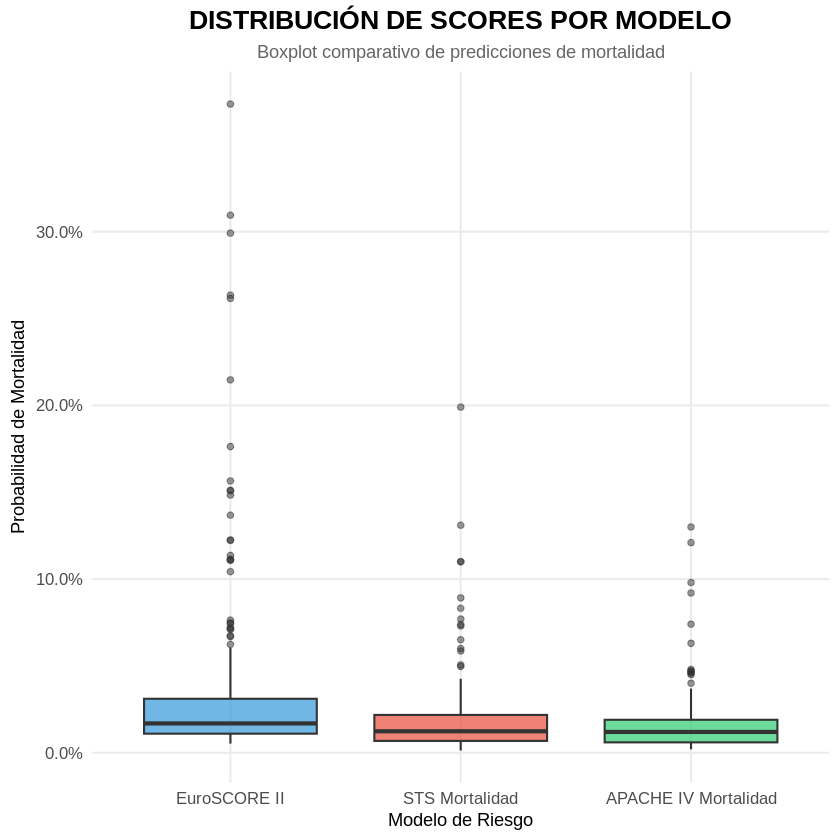

In [6]:
# ==============================================================================
# 5.1 DISTRIBUCIÓN DE SCORES DE RIESGO (EuroSCORE II, STS, APACHE IV)
# ==============================================================================

# ------------------------------------------------------------------------------
# 5.1.1 ESTADÍSTICAS DESCRIPTIVAS DE SCORES DE RIESGO
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.1.1 ESTADÍSTICAS DESCRIPTIVAS DE SCORES DE RIESGO ===\n")
cat(rep("=", 80), "\n", sep = "")

# Variables a analizar
scores_vars <- c(
  "prob_euroscore2",
  "prob_sts_mortalidad",
  "prob_apache_mortalidad"
)

# Etiquetas para los scores
scores_labels <- c(
  "EuroSCORE II",
  "STS Mortalidad",
  "APACHE IV Mortalidad"
)

# Calcular estadísticas descriptivas
estadisticas_scores <- data.frame()

for (i in 1:length(scores_vars)) {
  var <- scores_vars[i]
  label <- scores_labels[i]

  datos <- datos_icb_clean[[var]]
  datos <- datos[!is.na(datos)]

  stats <- data.frame(
    Score = label,
    Media = round(mean(datos, na.rm = TRUE), 4),
    DE = round(sd(datos, na.rm = TRUE), 4),
    Mediana = round(median(datos, na.rm = TRUE), 4),
    Q1 = round(quantile(datos, 0.25, na.rm = TRUE), 4),
    Q3 = round(quantile(datos, 0.75, na.rm = TRUE), 4),
    Min = round(min(datos, na.rm = TRUE), 4),
    Max = round(max(datos, na.rm = TRUE), 4),
    N = length(datos)
  )

  estadisticas_scores <- rbind(estadisticas_scores, stats)
}

cat("\n📊 RESUMEN DE SCORES DE RIESGO (PROBABILIDAD DECIMAL 0-1):\n")
cat("-", 60, "\n", sep = "")

for (i in 1:nrow(estadisticas_scores)) {
  cat(sprintf("\n📈 %s:\n", estadisticas_scores$Score[i]))
  cat(sprintf("  • Media (DE): %.4f (±%.4f)\n",
              estadisticas_scores$Media[i],
              estadisticas_scores$DE[i]))
  cat(sprintf("  • Mediana [RIC]: %.4f [%.4f - %.4f]\n",
              estadisticas_scores$Mediana[i],
              estadisticas_scores$Q1[i],
              estadisticas_scores$Q3[i]))
  cat(sprintf("  • Rango: %.4f - %.4f\n",
              estadisticas_scores$Min[i],
              estadisticas_scores$Max[i]))
}

# ------------------------------------------------------------------------------
# 5.1.2 PRUEBAS DE NORMALIDAD Y ASIMETRÍA
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.1.2 PRUEBAS DE NORMALIDAD Y ASIMETRÍA ===\n")
cat(rep("=", 80), "\n", sep = "")

# Función para evaluar normalidad y asimetría
evaluar_normalidad <- function(datos, nombre) {
  datos_clean <- datos[!is.na(datos)]
  n <- length(datos_clean)

  # Shapiro-Wilk
  shapiro_result <- shapiro.test(datos_clean)

  # Skewness
  skew_val <- skewness(datos_clean)

  # Interpretación de skewness
  if (abs(skew_val) < 0.5) {
    interpretacion <- "Simétrica"
  } else if (abs(skew_val) < 1) {
    interpretacion <- ifelse(skew_val > 0, "Sesgo moderado derecho", "Sesgo moderado izquierdo")
  } else if (abs(skew_val) < 2) {
    interpretacion <- ifelse(skew_val > 0, "Fuerte sesgo derecho", "Fuerte sesgo izquierdo")
  } else {
    interpretacion <- ifelse(skew_val > 0, "Sesgo extremo derecho", "Sesgo extremo izquierdo")
  }

  return(list(
    nombre = nombre,
    n = n,
    W = shapiro_result$statistic,
    p_valor = shapiro_result$p.value,
    normal = shapiro_result$p.value > 0.05,
    skewness = skew_val,
    interpretacion = interpretacion
  ))
}

# Evaluar cada score
cat("\n📊 PRUEBA DE SHAPIRO-WILK (Normalidad):\n")
cat("-", 60, "\n", sep = "")

resultados_normalidad <- list()

for (i in 1:length(scores_vars)) {
  datos <- datos_icb_clean[[scores_vars[i]]]
  resultado <- evaluar_normalidad(datos, scores_labels[i])
  resultados_normalidad[[i]] <- resultado

  cat(sprintf("\n📈 %s:\n", resultado$nombre))
  cat(sprintf("  • W: %.4f\n", resultado$W))
  cat(sprintf("  • p-valor: %.4f\n", resultado$p_valor))
  cat(sprintf("  • ¿Normal?: %s\n", ifelse(resultado$normal, "✅ Sí", "❌ No")))
}

cat("\n📊 ASIMETRÍA (Skewness):\n")
cat("-", 60, "\n", sep = "")

for (i in 1:length(resultados_normalidad)) {
  r <- resultados_normalidad[[i]]
  cat(sprintf("\n📈 %s: %.2f (%s)\n",
              r$nombre,
              r$skewness,
              r$interpretacion))
}

# ------------------------------------------------------------------------------
# 5.1.3 GRÁFICOS DE DISTRIBUCIÓN DE SCORES
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.1.3 GENERANDO GRÁFICOS DE DISTRIBUCIÓN ===\n")
cat(rep("=", 80), "\n", sep = "")

# 5.1.3.1 Histograma + Densidad para EuroSCORE II
plot_euro <- ggplot(datos_icb_clean, aes(x = prob_euroscore2)) +
  geom_histogram(aes(y = ..density..), bins = 30,
                 fill = "#3498db", color = "white", alpha = 0.7) +
  geom_density(color = "#2c3e50", size = 1.5) +
  geom_vline(aes(xintercept = mean(prob_euroscore2, na.rm = TRUE)),
             color = "#e74c3c", linetype = "dashed", size = 1.2) +
  geom_vline(aes(xintercept = median(prob_euroscore2, na.rm = TRUE)),
             color = "#f39c12", linetype = "dotted", size = 1.2) +
  labs(
    title = "A. EuroSCORE II",
    subtitle = sprintf("Media = %.3f | Mediana = %.3f | Skewness = %.2f",
                       mean(datos_icb_clean$prob_euroscore2, na.rm = TRUE),
                       median(datos_icb_clean$prob_euroscore2, na.rm = TRUE),
                       resultados_normalidad[[1]]$skewness),
    x = "Probabilidad de Mortalidad",
    y = "Densidad",
    caption = "Línea discontinua: Media | Línea punteada: Mediana"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14, color = "#3498db"),
    plot.subtitle = element_text(size = 10, color = "gray40"),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    panel.grid.minor = element_blank(),
    plot.caption = element_text(size = 9, color = "gray50")
  ) +
  scale_x_continuous(labels = scales::percent_format(accuracy = 0.1)) +
  scale_y_continuous(labels = scales::comma)

# 5.1.3.2 Histograma + Densidad para STS Mortalidad
plot_sts <- ggplot(datos_icb_clean, aes(x = prob_sts_mortalidad)) +
  geom_histogram(aes(y = ..density..), bins = 30,
                 fill = "#e74c3c", color = "white", alpha = 0.7) +
  geom_density(color = "#2c3e50", size = 1.5) +
  geom_vline(aes(xintercept = mean(prob_sts_mortalidad, na.rm = TRUE)),
             color = "#3498db", linetype = "dashed", size = 1.2) +
  geom_vline(aes(xintercept = median(prob_sts_mortalidad, na.rm = TRUE)),
             color = "#f39c12", linetype = "dotted", size = 1.2) +
  labs(
    title = "B. STS Mortalidad",
    subtitle = sprintf("Media = %.3f | Mediana = %.3f | Skewness = %.2f",
                       mean(datos_icb_clean$prob_sts_mortalidad, na.rm = TRUE),
                       median(datos_icb_clean$prob_sts_mortalidad, na.rm = TRUE),
                       resultados_normalidad[[2]]$skewness),
    x = "Probabilidad de Mortalidad",
    y = "Densidad",
    caption = "Línea discontinua: Media | Línea punteada: Mediana"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14, color = "#e74c3c"),
    plot.subtitle = element_text(size = 10, color = "gray40"),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    panel.grid.minor = element_blank(),
    plot.caption = element_text(size = 9, color = "gray50")
  ) +
  scale_x_continuous(labels = scales::percent_format(accuracy = 0.1)) +
  scale_y_continuous(labels = scales::comma)

# 5.1.3.3 Histograma + Densidad para APACHE IV Mortalidad
plot_apache <- ggplot(datos_icb_clean, aes(x = prob_apache_mortalidad)) +
  geom_histogram(aes(y = ..density..), bins = 30,
                 fill = "#2ecc71", color = "white", alpha = 0.7) +
  geom_density(color = "#2c3e50", size = 1.5) +
  geom_vline(aes(xintercept = mean(prob_apache_mortalidad, na.rm = TRUE)),
             color = "#e74c3c", linetype = "dashed", size = 1.2) +
  geom_vline(aes(xintercept = median(prob_apache_mortalidad, na.rm = TRUE)),
             color = "#f39c12", linetype = "dotted", size = 1.2) +
  labs(
    title = "C. APACHE IV Mortalidad",
    subtitle = sprintf("Media = %.3f | Mediana = %.3f | Skewness = %.2f",
                       mean(datos_icb_clean$prob_apache_mortalidad, na.rm = TRUE),
                       median(datos_icb_clean$prob_apache_mortalidad, na.rm = TRUE),
                       resultados_normalidad[[3]]$skewness),
    x = "Probabilidad de Mortalidad",
    y = "Densidad",
    caption = "Línea discontinua: Media | Línea punteada: Mediana"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14, color = "#27ae60"),
    plot.subtitle = element_text(size = 10, color = "gray40"),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    panel.grid.minor = element_blank(),
    plot.caption = element_text(size = 9, color = "gray50")
  ) +
  scale_x_continuous(labels = scales::percent_format(accuracy = 0.1)) +
  scale_y_continuous(labels = scales::comma)

# Mostrar gráficos individuales
print(plot_euro)
print(plot_sts)
print(plot_apache)

# 5.1.3.4 Gráficos combinados (tres paneles)
graficos_scores_combinados <- (plot_euro | plot_sts | plot_apache) +
  plot_annotation(
    title = "DISTRIBUCIÓN DE SCORES DE RIESGO QUIRÚRGICO",
    subtitle = "Comparación de modelos de predicción de mortalidad en la cohorte de cirugía cardiovascular",
    theme = theme(
      plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
      plot.subtitle = element_text(size = 12, hjust = 0.5, color = "gray40")
    )
  )

print(graficos_scores_combinados)

# ------------------------------------------------------------------------------
# 5.1.4 DENSIDADES COMPARATIVAS (Superposición)
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.1.4 DENSIDADES COMPARATIVAS ===\n")
cat(rep("=", 80), "\n", sep = "")

# Preparar datos para densidades comparativas
datos_densidades <- datos_icb_clean %>%
  select(prob_euroscore2, prob_sts_mortalidad, prob_apache_mortalidad) %>%
  pivot_longer(
    cols = everything(),
    names_to = "Score",
    values_to = "Probabilidad"
  ) %>%
  mutate(
    Score = case_when(
      Score == "prob_euroscore2" ~ "EuroSCORE II",
      Score == "prob_sts_mortalidad" ~ "STS Mortalidad",
      Score == "prob_apache_mortalidad" ~ "APACHE IV Mortalidad"
    ),
    Score = factor(Score, levels = c("EuroSCORE II", "STS Mortalidad", "APACHE IV Mortalidad"))
  )

# Gráfico de densidades superpuestas
plot_densidades <- ggplot(datos_densidades, aes(x = Probabilidad, color = Score, fill = Score)) +
  geom_density(alpha = 0.3, size = 1.2) +
  scale_color_manual(values = c("EuroSCORE II" = "#3498db",
                                "STS Mortalidad" = "#e74c3c",
                                "APACHE IV Mortalidad" = "#2ecc71")) +
  scale_fill_manual(values = c("EuroSCORE II" = "#3498db",
                               "STS Mortalidad" = "#e74c3c",
                               "APACHE IV Mortalidad" = "#2ecc71")) +
  labs(
    title = "COMPARACIÓN DE DISTRIBUCIONES DE SCORES DE RIESGO",
    subtitle = "Superposición de densidades de los tres modelos de predicción",
    x = "Probabilidad de Mortalidad",
    y = "Densidad",
    color = "Modelo de Riesgo",
    fill = "Modelo de Riesgo"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5, color = "gray40"),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  ) +
  scale_x_continuous(labels = scales::percent_format(accuracy = 0.1)) +
  scale_y_continuous(labels = scales::comma)

print(plot_densidades)

# ------------------------------------------------------------------------------
# 5.1.5 BOXPLOT COMPARATIVO
# ------------------------------------------------------------------------------

plot_boxplot <- datos_densidades %>%
  ggplot(aes(x = Score, y = Probabilidad, fill = Score)) +
  geom_boxplot(alpha = 0.7, outlier.size = 1.5, outlier.alpha = 0.5) +
  scale_fill_manual(values = c("EuroSCORE II" = "#3498db",
                               "STS Mortalidad" = "#e74c3c",
                               "APACHE IV Mortalidad" = "#2ecc71")) +
  labs(
    title = "DISTRIBUCIÓN DE SCORES POR MODELO",
    subtitle = "Boxplot comparativo de predicciones de mortalidad",
    x = "Modelo de Riesgo",
    y = "Probabilidad de Mortalidad"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5, color = "gray40"),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    legend.position = "none",
    panel.grid.minor = element_blank()
  ) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 0.1))

print(plot_boxplot)

# ------------------------------------------------------------------------------
# 5.1.6 EXPORTACIÓN DE RESULTADOS
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.1.6 EXPORTANDO RESULTADOS ===\n")
cat(rep("=", 80), "\n", sep = "")

# 5.1.6.1 Exportar gráficos combinados
ggsave(
  filename = "scores_distribucion_paneles.pdf",
  plot = graficos_scores_combinados,
  width = 16,
  height = 6,
  dpi = 300,
  device = "pdf"
)
cat("✅ Gráficos de paneles exportados a 'scores_distribucion_paneles.pdf'\n")

# 5.1.6.2 Exportar densidades comparativas
ggsave(
  filename = "scores_densidades_comparativas.pdf",
  plot = plot_densidades,
  width = 10,
  height = 7,
  dpi = 300,
  device = "pdf"
)
cat("✅ Densidades comparativas exportadas a 'scores_densidades_comparativas.pdf'\n")

# 5.1.6.3 Exportar boxplot comparativo
ggsave(
  filename = "scores_boxplot_comparativo.pdf",
  plot = plot_boxplot,
  width = 10,
  height = 7,
  dpi = 300,
  device = "pdf"
)
cat("✅ Boxplot comparativo exportado a 'scores_boxplot_comparativo.pdf'\n")

# 5.1.6.4 Exportar gráficos individuales
ggsave(
  filename = "scores_euroscore2.pdf",
  plot = plot_euro,
  width = 8,
  height = 6,
  dpi = 300,
  device = "pdf"
)
cat("✅ EuroSCORE II exportado a 'scores_euroscore2.pdf'\n")

ggsave(
  filename = "scores_sts_mortalidad.pdf",
  plot = plot_sts,
  width = 8,
  height = 6,
  dpi = 300,
  device = "pdf"
)
cat("✅ STS Mortalidad exportado a 'scores_sts_mortalidad.pdf'\n")

ggsave(
  filename = "scores_apache_mortalidad.pdf",
  plot = plot_apache,
  width = 8,
  height = 6,
  dpi = 300,
  device = "pdf"
)
cat("✅ APACHE IV Mortalidad exportado a 'scores_apache_mortalidad.pdf'\n")

# 5.1.6.5 Exportar estadísticas a Excel
write_xlsx(estadisticas_scores, "scores_estadisticas.xlsx")
cat("✅ Estadísticas exportadas a 'scores_estadisticas.xlsx'\n")

write.csv2(estadisticas_scores, "scores_estadisticas.csv", row.names = FALSE)
cat("✅ Estadísticas exportadas a 'scores_estadisticas.csv'\n")

# 5.1.6.6 Resumen ejecutivo
cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.1.7 RESUMEN EJECUTIVO ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📊 PRINCIPALES HALLAZGOS:\n")
cat("-", 60, "\n", sep = "")

for (i in 1:nrow(estadisticas_scores)) {
  cat(sprintf("\n📈 %s:\n", estadisticas_scores$Score[i]))
  cat(sprintf("  • Riesgo medio: %.2f%%\n", estadisticas_scores$Media[i] * 100))
  cat(sprintf("  • Riesgo mediano: %.2f%%\n", estadisticas_scores$Mediana[i] * 100))
  cat(sprintf("  • Rango intercuartílico: %.2f%% - %.2f%%\n",
              estadisticas_scores$Q1[i] * 100,
              estadisticas_scores$Q3[i] * 100))
  cat(sprintf("  • Asimetría: %.2f (Sesgo derecho)\n",
              resultados_normalidad[[i]]$skewness))
}

cat("\n📊 CONCLUSIÓN SOBRE NORMALIDAD:\n")
cat("  • Los tres scores presentan distribución NO NORMAL (p < 0.001)\n")
cat("  • Todos presentan sesgo positivo (asimetría a la derecha)\n")
cat("  • Esto confirma que la mayoría de los pacientes son de bajo riesgo\n")
cat("  • Solo una minoría presenta riesgo extremo\n")

cat("\n📁 ARCHIVOS GENERADOS:\n")
cat("  GRÁFICOS:\n")
cat("  1. scores_distribucion_paneles.pdf - Tres paneles comparativos\n")
cat("  2. scores_densidades_comparativas.pdf - Densidades superpuestas\n")
cat("  3. scores_boxplot_comparativo.pdf - Boxplot comparativo\n")
cat("  4. scores_euroscore2.pdf - EuroSCORE II individual\n")
cat("  5. scores_sts_mortalidad.pdf - STS individual\n")
cat("  6. scores_apache_mortalidad.pdf - APACHE IV individual\n")
cat("  TABLAS:\n")
cat("  7. scores_estadisticas.xlsx - Estadísticas en Excel\n")
cat("  8. scores_estadisticas.csv - Estadísticas en CSV\n")

cat("\n✅ ANÁLISIS DE SCORES COMPLETADO EXITOSAMENTE\n")

In [ ]:

# ==============================================================================
# 5.2 CASE-MIX QUIRÚRGICO Y TIEMPOS INTRAOPERATORIOS
# ==============================================================================

# ------------------------------------------------------------------------------
# 5.2.1 ANÁLISIS DE DIAGNÓSTICOS BASALES
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.2.1 ANÁLISIS DE DIAGNÓSTICOS BASALES ===\n")
cat(rep("=", 80), "\n", sep = "")

# Lista de variables de diagnóstico (dicotómicas)
diagnosticos_vars <- c(
  "dx_coronaria",
  "dx_insuf_aortica",
  "dx_estenosis_aortica",
  "dx_insuf_mitral",
  "dx_estenosis_mitral",
  "dx_insuf_tricuspidea",
  "dx_endocarditis",
  "dx_dilatacion_aorta",
  "dx_ruptura_cuerda",
  "dx_disf_protesica",
  "dx_cia",
  "dx_hipertrofia_septal",
  "dx_mixoma",
  "dx_fistula_coronaria"
)

# Etiquetas para diagnósticos
diagnosticos_labels <- c(
  "Enfermedad coronaria",
  "Insuficiencia aórtica",
  "Estenosis aórtica",
  "Insuficiencia mitral",
  "Estenosis mitral",
  "Insuficiencia tricuspídea",
  "Endocarditis",
  "Dilatación de aorta",
  "Ruptura de cuerda",
  "Disfunción protésica",
  "Comunicación interauricular",
  "Hipertrofia septal",
  "Mixoma",
  "Fístula coronaria"
)

# Calcular frecuencias y porcentajes
cat("\n📊 FRECUENCIA DE DIAGNÓSTICOS BASALES:\n")
cat("-", 60, "\n", sep = "")

diagnosticos_df <- data.frame(
  Diagnóstico = diagnosticos_labels,
  n = sapply(diagnosticos_vars, function(x) sum(datos_icb_clean[[x]] == 1, na.rm = TRUE)),
  Porcentaje = sapply(diagnosticos_vars, function(x) round(sum(datos_icb_clean[[x]] == 1, na.rm = TRUE) / nrow(datos_icb_clean) * 100, 1))
) %>%
  arrange(desc(n))

print(diagnosticos_df)

# ------------------------------------------------------------------------------
# 5.2.2 ANÁLISIS DE COMPLEJIDAD (NÚMERO DE DIAGNÓSTICOS)
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.2.2 ANÁLISIS DE COMPLEJIDAD (NÚMERO DE DIAGNÓSTICOS) ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📊 DISTRIBUCIÓN DEL NÚMERO DE DIAGNÓSTICOS:\n")
cat("-", 60, "\n", sep = "")

# Tabla de frecuencia
num_dx_table <- datos_icb_clean %>%
  group_by(num_diagnosticos) %>%
  summarize(
    n = n(),
    Porcentaje = round(n/nrow(datos_icb_clean)*100, 1)
  ) %>%
  arrange(num_diagnosticos)

print(num_dx_table)

# Estadísticas descriptivas
cat("\n📊 ESTADÍSTICAS DESCRIPTIVAS DE COMPLEJIDAD:\n")
cat("-", 60, "\n", sep = "")

num_dx_stats <- datos_icb_clean %>%
  summarize(
    Media = round(mean(num_diagnosticos, na.rm = TRUE), 2),
    DE = round(sd(num_diagnosticos, na.rm = TRUE), 2),
    Mediana = round(median(num_diagnosticos, na.rm = TRUE), 1),
    Q1 = round(quantile(num_diagnosticos, 0.25, na.rm = TRUE), 1),
    Q3 = round(quantile(num_diagnosticos, 0.75, na.rm = TRUE), 1),
    Min = min(num_diagnosticos, na.rm = TRUE),
    Max = max(num_diagnosticos, na.rm = TRUE)
  )

print(num_dx_stats)

# Prueba de normalidad
shapiro_dx <- shapiro.test(datos_icb_clean$num_diagnosticos)

cat(sprintf("\n📊 Prueba de normalidad (Shapiro-Wilk):\n"))
cat(sprintf("  • W: %.4f\n", shapiro_dx$statistic))
cat(sprintf("  • p-valor: %.4f\n", shapiro_dx$p.value))
cat(sprintf("  • ¿Normal?: %s\n", ifelse(shapiro_dx$p.value > 0.05, "✅ Sí", "❌ No")))

# ------------------------------------------------------------------------------
# 5.2.3 ANÁLISIS DE TIPO DE CIRUGÍA REALIZADA
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.2.3 ANÁLISIS DE TIPO DE CIRUGÍA REALIZADA ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📊 DISTRIBUCIÓN POR TIPO DE CIRUGÍA:\n")
cat("-", 60, "\n", sep = "")

# Tabla de frecuencia
cirugia_tabla <- datos_icb_clean %>%
  group_by(categoria_cirugia_realizada) %>%
  summarise(
    n = n(),
    Porcentaje = round(n/nrow(datos_icb_clean)*100, 1)
  ) %>%
  arrange(desc(n))

print(cirugia_tabla)

# ------------------------------------------------------------------------------
# 5.2.4 FRECUENCIA DE PROCEDIMIENTOS ESPECÍFICOS
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.2.4 FRECUENCIA DE PROCEDIMIENTOS ESPECÍFICOS ===\n")
cat(rep("=", 80), "\n", sep = "")

procedimientos_vars <- c(
  "real_rvm_1vaso", "real_rvm_2vasos", "real_rvm_3vasos", "real_rvm_4vasos",
  "real_rvamx", "real_rvabi", "real_rvmx", "real_rvmbi",
  "real_aorta_toracica", "real_plastia_trico", "real_maze",
  "real_cierre_auricul", "real_valvulop_mitral", "real_plastia_aortica",
  "real_cierre_cia", "real_resecc_endomic", "real_esccion_mixoma"
)

procedimientos_labels <- c(
  "RVM 1 vaso", "RVM 2 vasos", "RVM 3 vasos", "RVM 4 vasos",
  "RVA mecánica", "RVA biológica", "RVM mecánica", "RVM biológica",
  "Aorta torácica", "Plastia tricuspídea", "Maze",
  "Cierre auriculilla", "Valvuloplastia mitral", "Plastia aórtica",
  "Cierre CIA", "Resección endomiocárdica", "Escisión mixoma"
)

cat("\n📊 FRECUENCIA DE PROCEDIMIENTOS ESPECÍFICOS:\n")
cat("-", 60, "\n", sep = "")

procedimientos_df <- data.frame(
  Procedimiento = procedimientos_labels,
  n = sapply(procedimientos_vars, function(x) sum(datos_icb_clean[[x]] == 1, na.rm = TRUE)),
  Porcentaje = sapply(procedimientos_vars, function(x) round(sum(datos_icb_clean[[x]] == 1, na.rm = TRUE) / nrow(datos_icb_clean) * 100, 1))
) %>%
  arrange(desc(n))

print(procedimientos_df)

# ------------------------------------------------------------------------------
# 5.2.5 ANÁLISIS DE USO DE BOMBA DE CIRCULACIÓN EXTRACORPÓREA
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.2.5 ANÁLISIS DE USO DE BOMBA DE CIRCULACIÓN EXTRACORPÓREA ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📊 DISTRIBUCIÓN POR USO DE BOMBA:\n")
cat("-", 60, "\n", sep = "")

bomba_tabla <- datos_icb_clean %>%
  filter(!is.na(bomba)) %>%
  count(bomba) %>%
  mutate(
    Tipo = case_when(
      bomba == 1 ~ "Con bomba (On-pump)",
      bomba == 0 ~ "Sin bomba (Off-pump)"
    ),
    Porcentaje = round(n / sum(n) * 100, 1)
  ) %>%
  select(Tipo, n, Porcentaje)

print(bomba_tabla)

In [ ]:
# ------------------------------------------------------------------------------
# 5.2.6 ANÁLISIS DE TIEMPOS INTRAOPERATORIOS
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.2.6 ANÁLISIS DE TIEMPOS INTRAOPERATORIOS ===\n")
cat(rep("=", 80), "\n", sep = "")

# Función para analizar tiempos intraoperatorios
analizar_tiempo <- function(datos, variable, nombre, color) {
  datos_clean <- datos[!is.na(datos)]

  if (length(datos_clean) == 0) {
    cat(sprintf("\n⚠️ No hay datos disponibles para %s\n", nombre))
    return(NULL)
  }

  cat(sprintf("\n📊 %s (minutos):\n", nombre))
  cat("-", 60, "\n", sep = "")

  cat(sprintf("  • Pacientes: %d\n", length(datos_clean)))

  # Estadísticas descriptivas
  stats <- data.frame(
    Media = round(mean(datos_clean, na.rm = TRUE), 1),
    DE = round(sd(datos_clean, na.rm = TRUE), 1),
    Mediana = round(median(datos_clean, na.rm = TRUE), 1),
    Q1 = round(quantile(datos_clean, 0.25, na.rm = TRUE), 1),
    Q3 = round(quantile(datos_clean, 0.75, na.rm = TRUE), 1),
    Min = min(datos_clean, na.rm = TRUE),
    Max = max(datos_clean, na.rm = TRUE)
  )

  cat(sprintf("  • Mediana [RIC]: %.1f [%.1f - %.1f] minutos\n",
              stats$Mediana, stats$Q1, stats$Q3))
  cat(sprintf("  • Media ± DE: %.1f ± %.1f minutos\n",
              stats$Media, stats$DE))
  cat(sprintf("  • Rango: %.0f - %.0f minutos\n",
              stats$Min, stats$Max))

  # Prueba de normalidad
  if (length(datos_clean) >= 3) {
    shapiro_result <- shapiro.test(datos_clean)
    cat(sprintf("\n  • Prueba de normalidad (Shapiro-Wilk):\n"))
    cat(sprintf("    - W: %.4f\n", shapiro_result$statistic))
    cat(sprintf("    - p-valor: %.4f\n", shapiro_result$p.value))
    cat(sprintf("    - ¿Normal?: %s\n",
                ifelse(shapiro_result$p.value > 0.05, "✅ Sí", "❌ No")))

    # Asimetría
    skew_val <- skewness(datos_clean)
    if (abs(skew_val) < 0.5) {
      interpretacion <- "Simétrica"
    } else if (abs(skew_val) < 1) {
      interpretacion <- ifelse(skew_val > 0, "Sesgo moderado derecho", "Sesgo moderado izquierdo")
    } else if (abs(skew_val) < 2) {
      interpretacion <- ifelse(skew_val > 0, "Fuerte sesgo derecho", "Fuerte sesgo izquierdo")
    } else {
      interpretacion <- ifelse(skew_val > 0, "Sesgo extremo derecho", "Sesgo extremo izquierdo")
    }
    cat(sprintf("  • Asimetría (Skewness): %.2f (%s)\n", skew_val, interpretacion))
  }

  return(list(stats = stats, datos = datos_clean))
}

# 5.2.6.1 Tiempo de perfusión
perfusion_data <- datos_icb_clean$perfusion_corregida
resultado_perfusion <- analizar_tiempo(perfusion_data, "perfusion_corregida", "TIEMPO DE PERFUSIÓN", "#3498db")

if (!is.null(resultado_perfusion)) {
  perfusion_stats <- resultado_perfusion$stats
}

# 5.2.6.2 Tiempo de clampeo
clampeo_data <- datos_icb_clean$clampeo_corregido
resultado_clampeo <- analizar_tiempo(clampeo_data, "clampeo_corregido", "TIEMPO DE CLAMPEO AÓRTICO", "#e74c3c")

if (!is.null(resultado_clampeo)) {
  clampeo_stats <- resultado_clampeo$stats
}

# ------------------------------------------------------------------------------
# 5.2.7 GRÁFICOS DE TIEMPOS INTRAOPERATORIOS
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.2.7 GENERANDO GRÁFICOS DE TIEMPOS INTRAOPERATORIOS ===\n")
cat(rep("=", 80), "\n", sep = "")

# 5.2.7.1 Histograma + Densidad para Tiempo de Perfusión
if (exists("resultado_perfusion") && !is.null(resultado_perfusion)) {
  perf_datos <- resultado_perfusion$datos

  plot_perfusion <- ggplot(data.frame(tiempo = perf_datos), aes(x = tiempo)) +
    geom_histogram(aes(y = ..density..), bins = 20,
                   fill = "#3498db", color = "white", alpha = 0.7) +
    geom_density(color = "#2c3e50", size = 1.5) +
    geom_vline(aes(xintercept = mean(tiempo, na.rm = TRUE)),
               color = "#e74c3c", linetype = "dashed", size = 1.2) +
    geom_vline(aes(xintercept = median(tiempo, na.rm = TRUE)),
               color = "#f39c12", linetype = "dotted", size = 1.2) +
    labs(
      title = "A. Tiempo de Perfusión (Bomba)",
      subtitle = sprintf("Mediana = %.1f min | Media = %.1f ± %.1f min",
                         median(perf_datos, na.rm = TRUE),
                         mean(perf_datos, na.rm = TRUE),
                         sd(perf_datos, na.rm = TRUE)),
      x = "Tiempo de Perfusión (minutos)",
      y = "Densidad",
      caption = "Línea discontinua: Media | Línea punteada: Mediana"
    ) +
    theme_minimal(base_size = 12) +
    theme(
      plot.title = element_text(face = "bold", size = 14, color = "#3498db"),
      plot.subtitle = element_text(size = 10, color = "gray40"),
      axis.text = element_text(size = 10),
      axis.title = element_text(size = 11),
      panel.grid.minor = element_blank(),
      plot.caption = element_text(size = 9, color = "gray50")
    )

  print(plot_perfusion)
}

# 5.2.7.2 Histograma + Densidad para Tiempo de Clampeo
if (exists("resultado_clampeo") && !is.null(resultado_clampeo)) {
  clam_datos <- resultado_clampeo$datos

  plot_clampeo <- ggplot(data.frame(tiempo = clam_datos), aes(x = tiempo)) +
    geom_histogram(aes(y = ..density..), bins = 20,
                   fill = "#e74c3c", color = "white", alpha = 0.7) +
    geom_density(color = "#2c3e50", size = 1.5) +
    geom_vline(aes(xintercept = mean(tiempo, na.rm = TRUE)),
               color = "#3498db", linetype = "dashed", size = 1.2) +
    geom_vline(aes(xintercept = median(tiempo, na.rm = TRUE)),
               color = "#f39c12", linetype = "dotted", size = 1.2) +
    labs(
      title = "B. Tiempo de Clampeo Aórtico",
      subtitle = sprintf("Mediana = %.1f min | Media = %.1f ± %.1f min",
                         median(clam_datos, na.rm = TRUE),
                         mean(clam_datos, na.rm = TRUE),
                         sd(clam_datos, na.rm = TRUE)),
      x = "Tiempo de Clampeo (minutos)",
      y = "Densidad",
      caption = "Línea discontinua: Media | Línea punteada: Mediana"
    ) +
    theme_minimal(base_size = 12) +
    theme(
      plot.title = element_text(face = "bold", size = 14, color = "#e74c3c"),
      plot.subtitle = element_text(size = 10, color = "gray40"),
      axis.text = element_text(size = 10),
      axis.title = element_text(size = 11),
      panel.grid.minor = element_blank(),
      plot.caption = element_text(size = 9, color = "gray50")
    )

  print(plot_clampeo)
}

# 5.2.7.3 Boxplot comparativo de tiempos
if (exists("resultado_perfusion") && !is.null(resultado_perfusion) &&
    exists("resultado_clampeo") && !is.null(resultado_clampeo)) {

  # Preparar datos para boxplot comparativo
  tiempos_data <- bind_rows(
    data.frame(tiempo = resultado_perfusion$datos) %>% mutate(Tipo = "Perfusión"),
    data.frame(tiempo = resultado_clampeo$datos) %>% mutate(Tipo = "Clampeo")
  )

  plot_tiempos_box <- ggplot(tiempos_data, aes(x = Tipo, y = tiempo, fill = Tipo)) +
    geom_boxplot(alpha = 0.7, outlier.size = 1.5, outlier.alpha = 0.5) +
    scale_fill_manual(values = c("Perfusión" = "#3498db", "Clampeo" = "#e74c3c")) +
    labs(
      title = "COMPARACIÓN DE TIEMPOS INTRAOPERATORIOS",
      subtitle = "Boxplot de tiempos de perfusión y clampeo aórtico",
      x = "",
      y = "Tiempo (minutos)"
    ) +
    theme_minimal(base_size = 13) +
    theme(
      plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
      plot.subtitle = element_text(size = 11, hjust = 0.5, color = "gray40"),
      axis.text = element_text(size = 11),
      axis.title = element_text(size = 11),
      legend.position = "none",
      panel.grid.minor = element_blank()
    )

  print(plot_tiempos_box)
}

# 5.2.7.4 Gráfico de barras para tipo de cirugía
plot_cirugia <- datos_icb_clean %>%
  filter(!is.na(categoria_cirugia_realizada)) %>%
  count(categoria_cirugia_realizada) %>%
  mutate(porcentaje = n / sum(n) * 100,
         categoria_cirugia_realizada = fct_reorder(categoria_cirugia_realizada, n)) %>%
  ggplot(aes(x = categoria_cirugia_realizada, y = porcentaje, fill = categoria_cirugia_realizada)) +
  geom_bar(stat = "identity", show.legend = FALSE, width = 0.7) +
  geom_text(aes(label = sprintf("%.1f%% (n = %d)", porcentaje, n)),
            hjust = -0.1, size = 4) +
  coord_flip() +
  scale_fill_viridis_d(option = "plasma", begin = 0.3, end = 0.8) +
  labs(
    title = "C. Distribución por Tipo de Cirugía Realizada",
    x = "",
    y = "Porcentaje (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    panel.grid.minor = element_blank()
  ) +
  ylim(0, max(datos_icb_clean %>% filter(!is.na(categoria_cirugia_realizada)) %>%
                count(categoria_cirugia_realizada) %>% mutate(p = n/sum(n)*100) %>% pull(p)) + 10)

print(plot_cirugia)

# 5.2.7.5 Gráfico de barras para uso de bomba
plot_bomba <- datos_icb_clean %>%
  filter(!is.na(bomba)) %>%
  count(bomba) %>%
  mutate(
    porcentaje = n / sum(n) * 100,
    Tipo = case_when(
      bomba == 1 ~ "Con bomba (On-pump)",
      bomba == 0 ~ "Sin bomba (Off-pump)"
    )
  ) %>%
  ggplot(aes(x = Tipo, y = porcentaje, fill = Tipo)) +
  geom_bar(stat = "identity", show.legend = FALSE, width = 0.7) +
  geom_text(aes(label = sprintf("%.1f%% (n = %d)", porcentaje, n)),
            vjust = -0.5, size = 4.5, fontface = "bold") +
  scale_fill_manual(values = c("Con bomba (On-pump)" = "#2980b9",
                               "Sin bomba (Off-pump)" = "#e67e22")) +
  labs(
    title = "D. Uso de Bomba de Circulación Extracorpórea",
    x = "",
    y = "Porcentaje (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank()
  )

print(plot_bomba)

# ------------------------------------------------------------------------------
# 5.2.8 EXPORTACIÓN DE RESULTADOS
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.2.8 EXPORTANDO RESULTADOS ===\n")
cat(rep("=", 80), "\n", sep = "")

# 5.2.8.1 Exportar gráficos
if (exists("plot_perfusion")) {
  ggsave(filename = "tiempo_perfusion.pdf", plot = plot_perfusion,
         width = 8, height = 6, dpi = 300, device = "pdf")
  cat("✅ Tiempo de perfusión exportado a 'tiempo_perfusion.pdf'\n")
}

if (exists("plot_clampeo")) {
  ggsave(filename = "tiempo_clampeo.pdf", plot = plot_clampeo,
         width = 8, height = 6, dpi = 300, device = "pdf")
  cat("✅ Tiempo de clampeo exportado a 'tiempo_clampeo.pdf'\n")
}

if (exists("plot_tiempos_box")) {
  ggsave(filename = "tiempos_boxplot_comparativo.pdf", plot = plot_tiempos_box,
         width = 10, height = 7, dpi = 300, device = "pdf")
  cat("✅ Boxplot comparativo exportado a 'tiempos_boxplot_comparativo.pdf'\n")
}

ggsave(filename = "distribucion_cirugia.pdf", plot = plot_cirugia,
       width = 8, height = 6, dpi = 300, device = "pdf")
cat("✅ Distribución de cirugía exportada a 'distribucion_cirugia.pdf'\n")

ggsave(filename = "uso_bomba.pdf", plot = plot_bomba,
       width = 8, height = 6, dpi = 300, device = "pdf")
cat("✅ Uso de bomba exportado a 'uso_bomba.pdf'\n")

# 5.2.8.2 Exportar tablas a Excel
write_xlsx(diagnosticos_df, "diagnosticos_frecuencia.xlsx")
cat("✅ Diagnósticos exportados a 'diagnosticos_frecuencia.xlsx'\n")

write_xlsx(procedimientos_df, "procedimientos_frecuencia.xlsx")
cat("✅ Procedimientos exportados a 'procedimientos_frecuencia.xlsx'\n")

write_xlsx(cirugia_tabla, "tipo_cirugia.xlsx")
cat("✅ Tipo de cirugía exportado a 'tipo_cirugia.xlsx'\n")

write_xlsx(bomba_tabla, "uso_bomba.xlsx")
cat("✅ Uso de bomba exportado a 'uso_bomba.xlsx'\n")

# Exportar estadísticas de tiempos
if (exists("perfusion_stats")) {
  perfusion_export <- perfusion_stats %>%
    mutate(Variable = "Tiempo de perfusión") %>%
    select(Variable, everything())
  write_xlsx(perfusion_export, "tiempo_perfusion_stats.xlsx")
  cat("✅ Estadísticas de perfusión exportadas a 'tiempo_perfusion_stats.xlsx'\n")
}

if (exists("clampeo_stats")) {
  clampeo_export <- clampeo_stats %>%
    mutate(Variable = "Tiempo de clampeo") %>%
    select(Variable, everything())
  write_xlsx(clampeo_export, "tiempo_clampeo_stats.xlsx")
  cat("✅ Estadísticas de clampeo exportadas a 'tiempo_clampeo_stats.xlsx'\n")
}

# 5.2.8.3 Exportar a CSV
write.csv2(diagnosticos_df, "diagnosticos_frecuencia.csv", row.names = FALSE)
write.csv2(procedimientos_df, "procedimientos_frecuencia.csv", row.names = FALSE)
write.csv2(cirugia_tabla, "tipo_cirugia.csv", row.names = FALSE)
write.csv2(bomba_tabla, "uso_bomba.csv", row.names = FALSE)
cat("✅ Todos los archivos CSV generados\n")

# ------------------------------------------------------------------------------
# 5.2.9 RESUMEN EJECUTIVO
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.2.9 RESUMEN EJECUTIVO ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📊 PRINCIPALES HALLAZGOS:\n")
cat("-", 60, "\n", sep = "")

# Diagnóstico más frecuente
dx_mas_frec <- diagnosticos_df %>% slice(1)
cat(sprintf("\n✅ DIAGNÓSTICO MÁS FRECUENTE:\n"))
cat(sprintf("  • %s: %d pacientes (%.1f%%)\n",
            dx_mas_frec$Diagnóstico, dx_mas_frec$n, dx_mas_frec$Porcentaje))

# Tipo de cirugía más frecuente
cirugia_mas_frec <- cirugia_tabla %>% slice(1)
cat(sprintf("\n✅ TIPO DE CIRUGÍA MÁS FRECUENTE:\n"))
cat(sprintf("  • %s: %d pacientes (%.1f%%)\n",
            cirugia_mas_frec$categoria_cirugia_realizada,
            cirugia_mas_frec$n, cirugia_mas_frec$Porcentaje))

# Uso de bomba
bomba_on_pump <- bomba_tabla %>% filter(Tipo == "Con bomba (On-pump)")
bomba_off_pump <- bomba_tabla %>% filter(Tipo == "Sin bomba (Off-pump)")
cat(sprintf("\n✅ USO DE BOMBA:\n"))
cat(sprintf("  • On-pump: %d pacientes (%.1f%%)\n",
            bomba_on_pump$n, bomba_on_pump$Porcentaje))
cat(sprintf("  • Off-pump: %d pacientes (%.1f%%)\n",
            bomba_off_pump$n, bomba_off_pump$Porcentaje))

# Tiempos intraoperatorios
if (exists("perfusion_stats") && exists("clampeo_stats")) {
  cat(sprintf("\n✅ TIEMPOS INTRAOPERATORIOS (Mediana [RIC]):\n"))
  cat(sprintf("  • Tiempo de perfusión: %.1f [%.1f - %.1f] minutos\n",
              perfusion_stats$Mediana, perfusion_stats$Q1, perfusion_stats$Q3))
  cat(sprintf("  • Tiempo de clampeo: %.1f [%.1f - %.1f] minutos\n",
              clampeo_stats$Mediana, clampeo_stats$Q1, clampeo_stats$Q3))
}

cat("\n📁 ARCHIVOS GENERADOS:\n")
cat("  GRÁFICOS:\n")
cat("  1. tiempo_perfusion.pdf - Histograma de perfusión\n")
cat("  2. tiempo_clampeo.pdf - Histograma de clampeo\n")
cat("  3. tiempos_boxplot_comparativo.pdf - Boxplot comparativo\n")
cat("  4. distribucion_cirugia.pdf - Barras de tipo de cirugía\n")
cat("  5. uso_bomba.pdf - Barras de uso de bomba\n")
cat("  TABLAS:\n")
cat("  6. diagnosticos_frecuencia.xlsx - Frecuencia de diagnósticos\n")
cat("  7. procedimientos_frecuencia.xlsx - Frecuencia de procedimientos\n")
cat("  8. tipo_cirugia.xlsx - Tipo de cirugía\n")
cat("  9. uso_bomba.xlsx - Uso de bomba\n")
if (exists("perfusion_stats")) {
  cat("  10. tiempo_perfusion_stats.xlsx - Estadísticas de perfusión\n")
}
if (exists("clampeo_stats")) {
  cat("  11. tiempo_clampeo_stats.xlsx - Estadísticas de clampeo\n")
}

cat("\n✅ ANÁLISIS CASE-MIX COMPLETADO EXITOSAMENTE\n")

In [ ]:
# ==============================================================================
# 5.3 DESENLACES CLÍNICOS (Mortalidad y Morbilidad)
# ==============================================================================

# ------------------------------------------------------------------------------
# 5.3.1 FUNCIONES AUXILIARES
# ------------------------------------------------------------------------------

# Función para calcular intervalo de confianza de una proporción (método de Wilson)
calcular_ic_proporcion <- function(eventos, total, alpha = 0.05) {
  if (total == 0) return(c(0, 0))

  p <- eventos / total
  z <- qnorm(1 - alpha/2)

  # Método de Wilson
  numerator <- p + z^2/(2*total) + c(-1, 1) * z * sqrt((p*(1-p) + z^2/(4*total))/total)
  denominator <- 1 + z^2/total

  ic <- numerator / denominator
  return(ic)
}

# ------------------------------------------------------------------------------
# 5.3.2 ANÁLISIS DE MORTALIDAD A 30 DÍAS
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.3.1 ANÁLISIS DE MORTALIDAD A 30 DÍAS ===\n")
cat(rep("=", 80), "\n", sep = "")

# 5.3.1.1 Mortalidad global a 30 días
cat("\n📊 MORTALIDAD GLOBAL A 30 DÍAS:\n")
cat("-", 60, "\n", sep = "")

n_mortalidad <- sum(datos_icb_clean$mortalidad_30d == 1, na.rm = TRUE)
n_total <- nrow(datos_icb_clean)
porcentaje_mortalidad <- round(n_mortalidad / n_total * 100, 2)
ic_mortalidad <- calcular_ic_proporcion(n_mortalidad, n_total)

cat(sprintf("  • Eventos: %d de %d pacientes\n", n_mortalidad, n_total))
cat(sprintf("  • Tasa de mortalidad: %.2f%%\n", porcentaje_mortalidad))
cat(sprintf("  • IC 95%%: %.2f%% - %.2f%%\n",
            round(ic_mortalidad[1]*100, 2),
            round(ic_mortalidad[2]*100, 2)))

# 5.3.1.2 Mortalidad en <24 horas
cat("\n📊 MORTALIDAD EN <24 HORAS:\n")
cat("-", 60, "\n", sep = "")

n_mortalidad_24h <- sum(datos_icb_clean$fallecido_24h == 1, na.rm = TRUE)
porcentaje_24h <- round(n_mortalidad_24h / n_total * 100, 2)
ic_24h <- calcular_ic_proporcion(n_mortalidad_24h, n_total)

cat(sprintf("  • Eventos: %d de %d pacientes\n", n_mortalidad_24h, n_total))
cat(sprintf("  • Tasa de mortalidad <24h: %.2f%%\n", porcentaje_24h))
cat(sprintf("  • IC 95%%: %.2f%% - %.2f%%\n",
            round(ic_24h[1]*100, 2),
            round(ic_24h[2]*100, 2)))

# 5.3.1.3 Mortalidad entre 24h y 30 días
cat("\n📊 MORTALIDAD ENTRE 24H Y 30 DÍAS:\n")
cat("-", 60, "\n", sep = "")

n_mortalidad_30d_unic <- sum(datos_icb_clean$fallecido_30d_unic == 1, na.rm = TRUE)
porcentaje_30d_unic <- round(n_mortalidad_30d_unic / n_total * 100, 2)
ic_30d_unic <- calcular_ic_proporcion(n_mortalidad_30d_unic, n_total)

cat(sprintf("  • Eventos: %d de %d pacientes\n", n_mortalidad_30d_unic, n_total))
cat(sprintf("  • Tasa de mortalidad 24h-30d: %.2f%%\n", porcentaje_30d_unic))
cat(sprintf("  • IC 95%%: %.2f%% - %.2f%%\n",
            round(ic_30d_unic[1]*100, 2),
            round(ic_30d_unic[2]*100, 2)))

# ------------------------------------------------------------------------------
# 5.3.2 ANÁLISIS DE MORBILIDAD PERIOPERATORIA
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.3.2 ANÁLISIS DE MORBILIDAD PERIOPERATORIA ===\n")
cat(rep("=", 80), "\n", sep = "")

# Lista de complicaciones a analizar
complicaciones <- list(
  "ACV perioperatorio" = "acv_real",
  "Insuficiencia Renal Aguda (IRA)" = "ira_real",
  "Reintervención quirúrgica" = "reintervencion_real",
  "Infección profunda de herida (ISOP)" = "isop_real"
)

# Calcular para cada complicación
resultados_complicaciones <- data.frame()

cat("\n📊 FRECUENCIA DE COMPLICACIONES:\n")
cat("-", 60, "\n", sep = "")

for (nombre in names(complicaciones)) {
  var <- complicaciones[[nombre]]
  n_eventos <- sum(datos_icb_clean[[var]] == 1, na.rm = TRUE)
  porcentaje <- round(n_eventos / n_total * 100, 2)
  ic <- calcular_ic_proporcion(n_eventos, n_total)

  cat(sprintf("\n📈 %s:\n", nombre))
  cat(sprintf("  • Eventos: %d de %d pacientes\n", n_eventos, n_total))
  cat(sprintf("  • Tasa: %.2f%%\n", porcentaje))
  cat(sprintf("  • IC 95%%: %.2f%% - %.2f%%\n",
              round(ic[1]*100, 2),
              round(ic[2]*100, 2)))

  resultados_complicaciones <- rbind(resultados_complicaciones,
    data.frame(
      Complicación = nombre,
      n = n_eventos,
      Total = n_total,
      Porcentaje = porcentaje,
      IC_Inf = round(ic[1]*100, 2),
      IC_Sup = round(ic[2]*100, 2)
    ))
}

# ------------------------------------------------------------------------------
# 5.3.3 ANÁLISIS DE ESTANCIAS POSTOPERATORIAS
# ------------------------------------------------------------------------------

cat("\n", rep="=", 80, "\n", sep = "")
cat("=== 5.3.3 ANÁLISIS DE ESTANCIAS POSTOPERATORIAS ===\n")
cat(rep("=", 80), "\n", sep = "")

# Función para analizar estancias
analizar_estancia <- function(datos, nombre, puntos_corte = NULL) {
  datos_clean <- datos[!is.na(datos)]

  if (length(datos_clean) == 0) {
    cat(sprintf("\n⚠️ No hay datos disponibles para %s\n", nombre))
    return(NULL)
  }

  cat(sprintf("\n📊 %s:\n", nombre))
  cat("-", 60, "\n", sep = "")

  # Estadísticas descriptivas
  stats <- data.frame(
    Mediana = round(median(datos_clean), 1),
    Q1 = round(quantile(datos_clean, 0.25), 1),
    Q3 = round(quantile(datos_clean, 0.75), 1),
    Media = round(mean(datos_clean), 1),
    DE = round(sd(datos_clean), 1),
    Min = min(datos_clean),
    Max = max(datos_clean)
  )

  cat(sprintf("  • Mediana [RIC]: %.1f [%.1f - %.1f] días\n",
              stats$Mediana, stats$Q1, stats$Q3))
  cat(sprintf("  • Media ± DE: %.1f ± %.1f días\n",
              stats$Media, stats$DE))
  cat(sprintf("  • Rango: %.0f - %.0f días\n",
              stats$Min, stats$Max))

  # Prueba de normalidad
  if (length(datos_clean) >= 3) {
    shapiro_result <- shapiro.test(datos_clean)
    cat(sprintf("\n  • Prueba de normalidad (Shapiro-Wilk): p = %.4f\n",
                shapiro_result$p.value))
    cat(sprintf("  • ¿Normal?: %s\n",
                ifelse(shapiro_result$p.value > 0.05, "✅ Sí", "❌ No")))
  }

  # Puntos de corte si se especifican
  if (!is.null(puntos_corte)) {
    for (pc in names(puntos_corte)) {
      n_corte <- sum(datos_clean > puntos_corte[[pc]], na.rm = TRUE)
      pct_corte <- round(n_corte / length(datos_clean) * 100, 2)
      ic_corte <- calcular_ic_proporcion(n_corte, length(datos_clean))

      cat(sprintf("\n  • %s (>%.0f días): %d (%.2f%%)",
                  pc, puntos_corte[[pc]], n_corte, pct_corte))
      cat(sprintf("\n    IC 95%%: %.2f%% - %.2f%%\n",
                  round(ic_corte[1]*100, 2),
                  round(ic_corte[2]*100, 2)))
    }
  }

  return(list(stats = stats, datos = datos_clean, shapiro = shapiro_result))
}

# 5.3.3.1 Días de ventilación mecánica
ventilacion_result <- analizar_estancia(
  datos_icb_clean$dias_ventilacion_mecanica,
  "DÍAS DE VENTILACIÓN MECÁNICA",
  puntos_corte = list("Ventilación prolongada" = 2)
)

if (!is.null(ventilacion_result)) {
  ventilation_stats <- ventilacion_result$stats
  shapiro_vent <- ventilacion_result$shapiro
  n_vent_prolongada <- sum(ventilacion_result$datos > 2, na.rm = TRUE)
  pct_vent_prolongada <- round(n_vent_prolongada / length(ventilacion_result$datos) * 100, 2)
  ic_vent_prolongada <- calcular_ic_proporcion(n_vent_prolongada, length(ventilacion_result$datos))
}

# 5.3.3.2 Días de estancia en UCI
uci_result <- analizar_estancia(
  datos_icb_clean$estancia_uci,
  "DÍAS DE ESTANCIA EN UCI",
  puntos_corte = list("Estancia UCI prolongada" = 7)
)

if (!is.null(uci_result)) {
  uci_stats <- uci_result$stats
  shapiro_uci <- uci_result$shapiro
  n_uci_prolongada <- sum(uci_result$datos > 7, na.rm = TRUE)
  pct_uci_prolongada <- round(n_uci_prolongada / length(uci_result$datos) * 100, 2)
  ic_uci_prolongada <- calcular_ic_proporcion(n_uci_prolongada, length(uci_result$datos))
}

# 5.3.3.3 Días de estancia hospitalaria total
hospitalaria_result <- analizar_estancia(
  datos_icb_clean$estancia_hospitalaria,
  "DÍAS DE ESTANCIA HOSPITALARIA TOTAL",
  puntos_corte = list("Estancia prolongada" = 14, "Estancia corta" = 6)
)

if (!is.null(hospitalaria_result)) {
  hospitalaria_stats <- hospitalaria_result$stats
  shapiro_hosp <- hospitalaria_result$shapiro
  n_hosp_prolongada <- sum(hospitalaria_result$datos > 14, na.rm = TRUE)
  pct_hosp_prolongada <- round(n_hosp_prolongada / length(hospitalaria_result$datos) * 100, 2)
  ic_hosp_prolongada <- calcular_ic_proporcion(n_hosp_prolongada, length(hospitalaria_result$datos))

  n_hosp_corta <- sum(hospitalaria_result$datos < 6, na.rm = TRUE)
  pct_hosp_corta <- round(n_hosp_corta / length(hospitalaria_result$datos) * 100, 2)
  ic_hosp_corta <- calcular_ic_proporcion(n_hosp_corta, length(hospitalaria_result$datos))
}

# ------------------------------------------------------------------------------
# 5.3.4 GRÁFICOS DE DESENLACES
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.3.4 GENERANDO GRÁFICOS DE DESENLACES ===\n")
cat(rep("=", 80), "\n", sep = "")

# 5.3.4.1 Gráfico de barras para complicaciones con IC 95%
datos_complicaciones_grafico <- resultados_complicaciones %>%
  mutate(
    Complicación = factor(Complicación, levels = Complicación[order(Porcentaje)]),
    IC_Inf = IC_Inf,
    IC_Sup = IC_Sup
  )

plot_complicaciones <- ggplot(datos_complicaciones_grafico,
                              aes(x = Complicación, y = Porcentaje, fill = Complicación)) +
  geom_bar(stat = "identity", show.legend = FALSE, width = 0.7) +
  geom_errorbar(aes(ymin = IC_Inf, ymax = IC_Sup),
                width = 0.2, color = "black", size = 0.8) +
  geom_text(aes(label = sprintf("%.1f%%", Porcentaje)),
            vjust = -0.5, size = 3.5, fontface = "bold") +
  scale_fill_viridis_d(option = "plasma", begin = 0.2, end = 0.8) +
  labs(
    title = "A. Complicaciones Perioperatorias",
    subtitle = "Barras con intervalos de confianza al 95%",
    x = "",
    y = "Porcentaje (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 10, color = "gray40"),
    axis.text.x = element_text(size = 9, angle = 45, hjust = 1),
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 11),
    panel.grid.minor = element_blank()
  ) +
  ylim(0, max(datos_complicaciones_grafico$IC_Sup) + 5)

print(plot_complicaciones)

# 5.3.4.2 Boxplot para estancias
if (exists("ventilacion_result") && exists("uci_result") && exists("hospitalaria_result")) {

  estancias_data <- data.frame(
    Dias = c(ventilacion_result$datos,
             uci_result$datos,
             hospitalaria_result$datos),
    Tipo = c(rep("Ventilación Mecánica", length(ventilacion_result$datos)),
             rep("Estancia UCI", length(uci_result$datos)),
             rep("Estancia Hospitalaria", length(hospitalaria_result$datos)))
  )

  plot_estancias <- ggplot(estancias_data, aes(x = Tipo, y = Dias, fill = Tipo)) +
    geom_boxplot(alpha = 0.7, outlier.size = 1.5, outlier.alpha = 0.5) +
    scale_fill_manual(values = c("Ventilación Mecánica" = "#3498db",
                                 "Estancia UCI" = "#e67e22",
                                 "Estancia Hospitalaria" = "#2ecc71")) +
    labs(
      title = "B. Distribución de Estancias Postoperatorias",
      subtitle = "Boxplot con medianas y rangos intercuartílicos",
      x = "",
      y = "Días"
    ) +
    theme_minimal(base_size = 12) +
    theme(
      plot.title = element_text(face = "bold", size = 14),
      plot.subtitle = element_text(size = 10, color = "gray40"),
      axis.text = element_text(size = 10),
      axis.title = element_text(size = 11),
      legend.position = "none",
      panel.grid.minor = element_blank()
    ) +
    coord_flip()

  print(plot_estancias)
}

# 5.3.4.3 Gráfico de barras para mortalidad
datos_mortalidad <- data.frame(
  Categoria = c("Sobrevivientes", "Fallecidos"),
  n = c(n_total - n_mortalidad, n_mortalidad),
  Porcentaje = c(100 - porcentaje_mortalidad, porcentaje_mortalidad)
)

plot_mortalidad <- ggplot(datos_mortalidad, aes(x = "", y = Porcentaje, fill = Categoria)) +
  geom_bar(stat = "identity", width = 0.5) +
  geom_text(
    aes(label = sprintf("%.1f%%\n(n = %d)", Porcentaje, n)),
    position = position_stack(vjust = 0.5),
    size = 4.5, fontface = "bold"
  ) +
  scale_fill_manual(values = c("Sobrevivientes" = "#2ecc71", "Fallecidos" = "#e74c3c")) +
  labs(
    title = "C. Mortalidad a 30 Días",
    x = "",
    y = "Porcentaje (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    axis.text.x = element_blank(),
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 11),
    legend.position = "bottom",
    legend.title = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank()
  )

print(plot_mortalidad)

# ------------------------------------------------------------------------------
# 5.3.5 EXPORTACIÓN DE RESULTADOS
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.3.5 EXPORTANDO RESULTADOS ===\n")
cat(rep("=", 80), "\n", sep = "")

# 5.3.5.1 Exportar gráficos
ggsave(filename = "complicaciones_ic95.pdf", plot = plot_complicaciones,
       width = 8, height = 6, dpi = 300, device = "pdf")
cat("✅ Gráfico de complicaciones exportado a 'complicaciones_ic95.pdf'\n")

if (exists("plot_estancias")) {
  ggsave(filename = "estancias_boxplot.pdf", plot = plot_estancias,
         width = 8, height = 6, dpi = 300, device = "pdf")
  cat("✅ Boxplot de estancias exportado a 'estancias_boxplot.pdf'\n")
}

ggsave(filename = "mortalidad_grafico.pdf", plot = plot_mortalidad,
       width = 6, height = 6, dpi = 300, device = "pdf")
cat("✅ Gráfico de mortalidad exportado a 'mortalidad_grafico.pdf'\n")

# 5.3.5.2 Exportar tablas a Excel
# Tabla de mortalidad
mortalidad_export <- data.frame(
  Indicador = c("Mortalidad global 30 días", "Mortalidad <24h", "Mortalidad 24h-30d"),
  n = c(n_mortalidad, n_mortalidad_24h, n_mortalidad_30d_unic),
  Total = n_total,
  Porcentaje = round(c(porcentaje_mortalidad, porcentaje_24h, porcentaje_30d_unic), 2),
  IC_Inf = round(c(ic_mortalidad[1]*100, ic_24h[1]*100, ic_30d_unic[1]*100), 2),
  IC_Sup = round(c(ic_mortalidad[2]*100, ic_24h[2]*100, ic_30d_unic[2]*100), 2)
)

write_xlsx(mortalidad_export, "mortalidad_resultados.xlsx")
cat("✅ Tabla de mortalidad exportada a 'mortalidad_resultados.xlsx'\n")

# Tabla de complicaciones
write_xlsx(resultados_complicaciones, "complicaciones_resultados.xlsx")
cat("✅ Tabla de complicaciones exportada a 'complicaciones_resultados.xlsx'\n")

# Tabla de estancias
if (exists("ventilation_stats") && exists("uci_stats") && exists("hospitalaria_stats")) {
  estancias_export <- data.frame(
    Variable = c("Ventilación mecánica", "Estancia UCI", "Estancia hospitalaria"),
    Mediana = c(ventilation_stats$Mediana, uci_stats$Mediana, hospitalaria_stats$Mediana),
    Q1 = c(ventilation_stats$Q1, uci_stats$Q1, hospitalaria_stats$Q1),
    Q3 = c(ventilation_stats$Q3, uci_stats$Q3, hospitalaria_stats$Q3),
    Media = c(ventilation_stats$Media, uci_stats$Media, hospitalaria_stats$Media),
    DE = c(ventilation_stats$DE, uci_stats$DE, hospitalaria_stats$DE),
    Min = c(ventilation_stats$Min, uci_stats$Min, hospitalaria_stats$Min),
    Max = c(ventilation_stats$Max, uci_stats$Max, hospitalaria_stats$Max)
  )

  write_xlsx(estancias_export, "estancias_resultados.xlsx")
  cat("✅ Tabla de estancias exportada a 'estancias_resultados.xlsx'\n")
}

# 5.3.5.3 Exportar a CSV
write.csv2(mortalidad_export, "mortalidad_resultados.csv", row.names = FALSE)
write.csv2(resultados_complicaciones, "complicaciones_resultados.csv", row.names = FALSE)
if (exists("estancias_export")) {
  write.csv2(estancias_export, "estancias_resultados.csv", row.names = FALSE)
}
cat("✅ Todos los archivos CSV generados\n")

# ------------------------------------------------------------------------------
# 5.3.6 RESUMEN EJECUTIVO
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 5.3.6 RESUMEN EJECUTIVO DE DESENLACES ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📊 PRINCIPALES HALLAZGOS:\n")
cat("-", 60, "\n", sep = "")

cat(sprintf("\n📈 MORTALIDAD:\n"))
cat(sprintf("  • Mortalidad global: %.2f%% (IC 95%%: %.2f%% - %.2f%%)\n",
            porcentaje_mortalidad,
            round(ic_mortalidad[1]*100, 2),
            round(ic_mortalidad[2]*100, 2)))

cat(sprintf("\n📈 COMPLICACIONES MÁS FRECUENTES:\n"))
complicacion_mas_frec <- resultados_complicaciones %>% slice(which.max(Porcentaje))
cat(sprintf("  • %s: %.2f%% (IC 95%%: %.2f%% - %.2f%%)\n",
            complicacion_mas_frec$Complicación,
            complicacion_mas_frec$Porcentaje,
            complicacion_mas_frec$IC_Inf,
            complicacion_mas_frec$IC_Sup))

if (exists("ventilation_stats") && exists("uci_stats") && exists("hospitalaria_stats")) {
  cat(sprintf("\n📈 ESTANCIAS (Mediana [RIC]):\n"))
  cat(sprintf("  • Ventilación mecánica: %.1f [%.1f - %.1f] días\n",
              ventilation_stats$Mediana, ventilation_stats$Q1, ventilation_stats$Q3))
  cat(sprintf("  • Estancia UCI: %.1f [%.1f - %.1f] días\n",
              uci_stats$Mediana, uci_stats$Q1, uci_stats$Q3))
  cat(sprintf("  • Estancia hospitalaria: %.1f [%.1f - %.1f] días\n",
              hospitalaria_stats$Mediana, hospitalaria_stats$Q1, hospitalaria_stats$Q3))
}

cat("\n📁 ARCHIVOS GENERADOS:\n")
cat("  GRÁFICOS:\n")
cat("  1. complicaciones_ic95.pdf - Complicaciones con IC 95%\n")
cat("  2. estancias_boxplot.pdf - Boxplot de estancias\n")
cat("  3. mortalidad_grafico.pdf - Mortalidad a 30 días\n")
cat("  TABLAS:\n")
cat("  4. mortalidad_resultados.xlsx - Mortalidad\n")
cat("  5. complicaciones_resultados.xlsx - Complicaciones\n")
cat("  6. estancias_resultados.xlsx - Estancias\n")

cat("\n✅ ANÁLISIS DE DESENLACES COMPLETADO EXITOSAMENTE\n")




=== 6.1.1 PREPARACIÓN DE VARIABLES ===
=== 6.1.1 PREPARACIÓN DE VARIABLES ===
=== 6.1.1 PREPARACIÓN DE VARIABLES ===

📊 Distribución de complicación global:

📊 Distribución de complicación global:

📊 Distribución de complicación global:

 No  Sí 
176  21 

 No  Sí 
176  21 

 No  Sí 
176  21 



=== 6.1.3 ASOCIACIONES CATEGÓRICAS ===
=== 6.1.3 ASOCIACIONES CATEGÓRICAS ===
=== 6.1.3 ASOCIACIONES CATEGÓRICAS ===

📊 SEXO vs COMPLICACIÓN GLOBAL:

📊 SEXO vs COMPLICACIÓN GLOBAL:

📊 SEXO vs COMPLICACIÓN GLOBAL:
-60
-60
-60

Tabla de contingencia:

Tabla de contingencia:

Tabla de contingencia:
           
              0   1
  Masculino 130  13
  Femenino   46   8
           
              0   1
  Masculino 130  13
  Femenino   46   8
           
              0   1
  Masculino 130  13
  Femenino   46   8

Porcentajes por fila:

Porcentajes por fila:

Porcentajes por fila:
           
               0    1
  Masculino 90.9  9.1
  Femenino  85.2 14.8
           
               0    1
  Masc

Warning message in chisq.test(tabla):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(tabla):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(tabla):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”



Tabla de contingencia:

Tabla de contingencia:

Tabla de contingencia:
           
              0   1
  Masculino 142   1
  Femenino   52   2
           
              0   1
  Masculino 142   1
  Femenino   52   2
           
              0   1
  Masculino 142   1
  Femenino   52   2

Porcentajes por fila:

Porcentajes por fila:

Porcentajes por fila:
           
               0    1
  Masculino 99.3  0.7
  Femenino  96.3  3.7
           
               0    1
  Masculino 99.3  0.7
  Femenino  96.3  3.7
           
               0    1
  Masculino 99.3  0.7
  Femenino  96.3  3.7

Método: Prueba Exacta de Fisher

Método: Prueba Exacta de Fisher

Método: Prueba Exacta de Fisher
p-valor: 0.1828
p-valor: 0.1828
p-valor: 0.1828
Significativo: ❌ No
Significativo: ❌ No
Significativo: ❌ No


📊 TIPO DE CIRUGÍA vs COMPLICACIÓN GLOBAL:


📊 TIPO DE CIRUGÍA vs COMPLICACIÓN GLOBAL:


📊 TIPO DE CIRUGÍA vs COMPLICACIÓN GLOBAL:
-60
-60
-60


Warning message in chisq.test(tabla):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(tabla):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(tabla):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, correct = correction):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(xx, cor


Tabla de contingencia:

Tabla de contingencia:

Tabla de contingencia:
                                    
                                       0   1
  CABG aislada                       102   5
  Valvular aislada                    49   5
  Procedimiento combinado / Complejo  25  11
                                    
                                       0   1
  CABG aislada                       102   5
  Valvular aislada                    49   5
  Procedimiento combinado / Complejo  25  11
                                    
                                       0   1
  CABG aislada                       102   5
  Valvular aislada                    49   5
  Procedimiento combinado / Complejo  25  11

Porcentajes por fila:

Porcentajes por fila:

Porcentajes por fila:
                                    
                                        0    1
  CABG aislada                       95.3  4.7
  Valvular aislada                   90.7  9.3
  Procedimiento combinado / Co

...

  • Rho de Spearman: 0.328
  • p-valor: 0.0000
  • Significativo: ✅ Sí
  • Interpretación: Asociación moderada

📊 CORRELACIÓN: Clampeo vs Ventilación Mecánica
-60
  • Rho de Spearman: 0.328
  • p-valor: 0.0000
  • Significativo: ✅ Sí
  • Interpretación: Asociación moderada

📊 CORRELACIÓN: Clampeo vs Ventilación Mecánica
-60
  • Rho de Spearman: 0.328
  • p-valor: 0.0000
  • Significativo: ✅ Sí
  • Interpretación: Asociación moderada

📊 CORRELACIÓN: Clampeo vs Ventilación Mecánica
-60


Warning message in cor.test.default(datos_on_pump$clampeo_corregido, datos_on_pump$dias_ventilacion_mecanica, :
“cannot compute exact p-value with ties”
Warning message in cor.test.default(datos_on_pump$clampeo_corregido, datos_on_pump$dias_ventilacion_mecanica, :
“cannot compute exact p-value with ties”
Warning message in cor.test.default(datos_on_pump$clampeo_corregido, datos_on_pump$dias_ventilacion_mecanica, :
“cannot compute exact p-value with ties”


  • Rho de Spearman: 0.235
  • p-valor: 0.0019
  • Significativo: ✅ Sí
  • Interpretación: Asociación débil

📊 CORRELACIÓN: Clampeo vs Estancia UCI
-60
  • Rho de Spearman: 0.235
  • p-valor: 0.0019
  • Significativo: ✅ Sí
  • Interpretación: Asociación débil

📊 CORRELACIÓN: Clampeo vs Estancia UCI
-60
  • Rho de Spearman: 0.235
  • p-valor: 0.0019
  • Significativo: ✅ Sí
  • Interpretación: Asociación débil

📊 CORRELACIÓN: Clampeo vs Estancia UCI
-60


Warning message in cor.test.default(datos_on_pump$clampeo_corregido, datos_on_pump$estancia_uci, :
“cannot compute exact p-value with ties”
Warning message in cor.test.default(datos_on_pump$clampeo_corregido, datos_on_pump$estancia_uci, :
“cannot compute exact p-value with ties”
Warning message in cor.test.default(datos_on_pump$clampeo_corregido, datos_on_pump$estancia_uci, :
“cannot compute exact p-value with ties”


  • Rho de Spearman: 0.252
  • p-valor: 0.0009
  • Significativo: ✅ Sí
  • Interpretación: Asociación débil

📊 RESUMEN DE CORRELACIONES DE SPEARMAN:
-60
  Variable1    Variable2       Rho      p_valor Significativo
1 Perfusión  Ventilación 0.2543238 7.609155e-04          TRUE
2 Perfusión Estancia UCI 0.3280335 1.118364e-05          TRUE
3   Clampeo  Ventilación 0.2354501 1.875864e-03          TRUE
4   Clampeo Estancia UCI 0.2517525 8.639461e-04          TRUE
  • Rho de Spearman: 0.252
  • p-valor: 0.0009
  • Significativo: ✅ Sí
  • Interpretación: Asociación débil

📊 RESUMEN DE CORRELACIONES DE SPEARMAN:
-60
  Variable1    Variable2       Rho      p_valor Significativo
1 Perfusión  Ventilación 0.2543238 7.609155e-04          TRUE
2 Perfusión Estancia UCI 0.3280335 1.118364e-05          TRUE
3   Clampeo  Ventilación 0.2354501 1.875864e-03          TRUE
4   Clampeo Estancia UCI 0.2517525 8.639461e-04          TRUE
  • Rho de Spearman: 0.252
  • p-valor: 0.0009
  • Significativo: ✅ Sí
  •

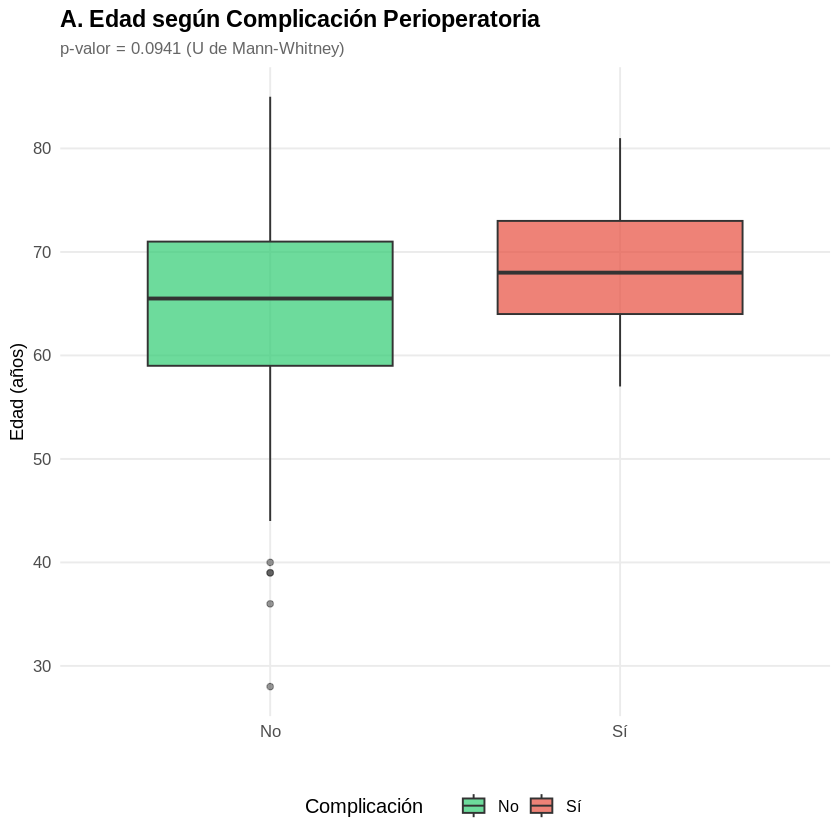

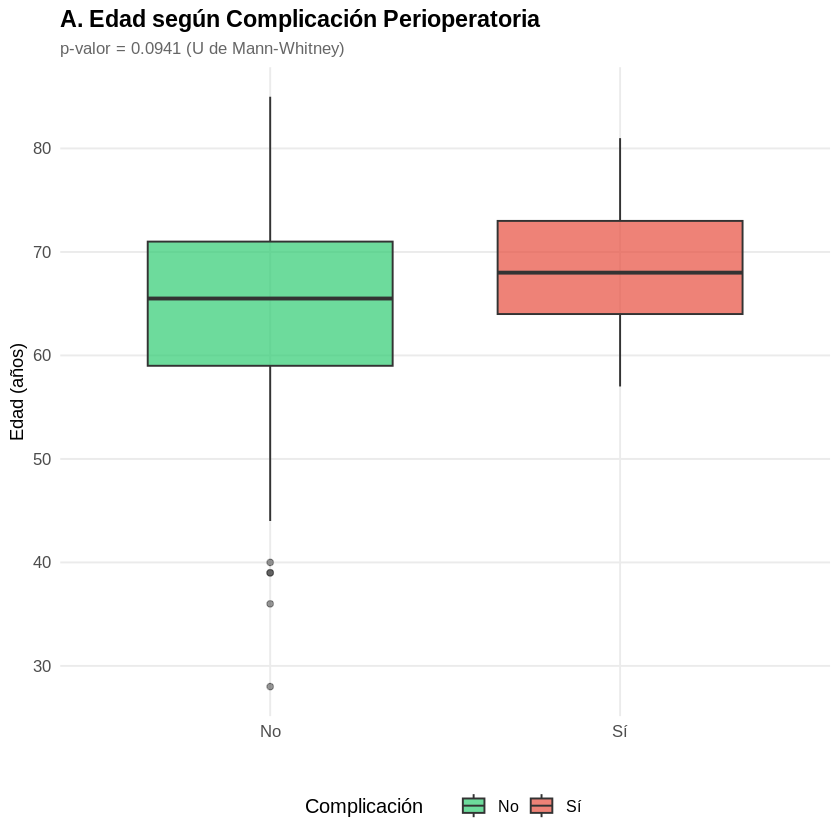

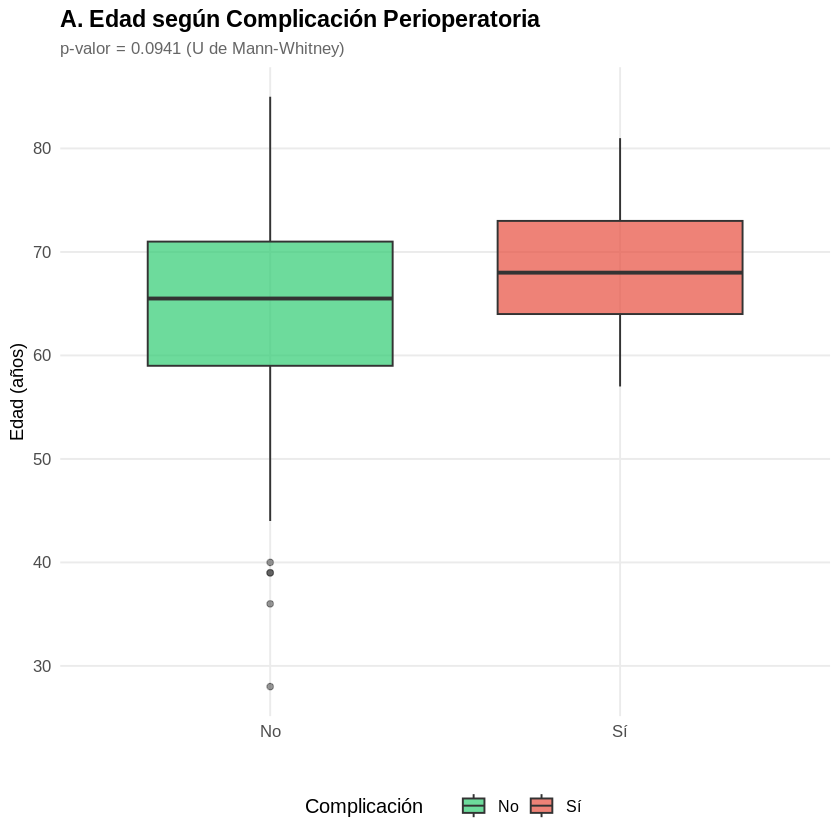

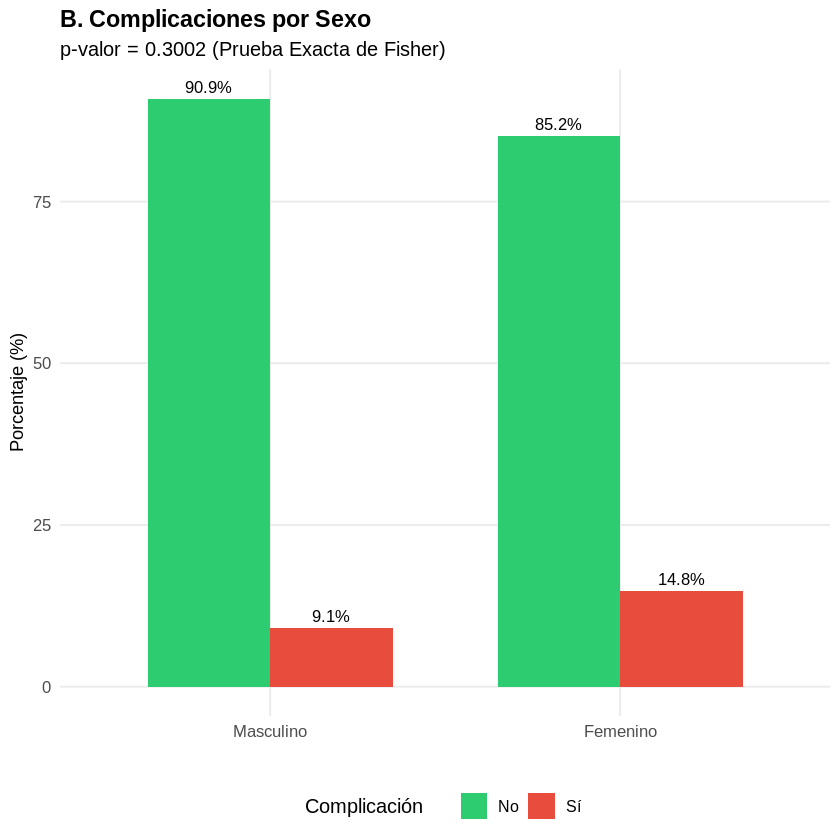

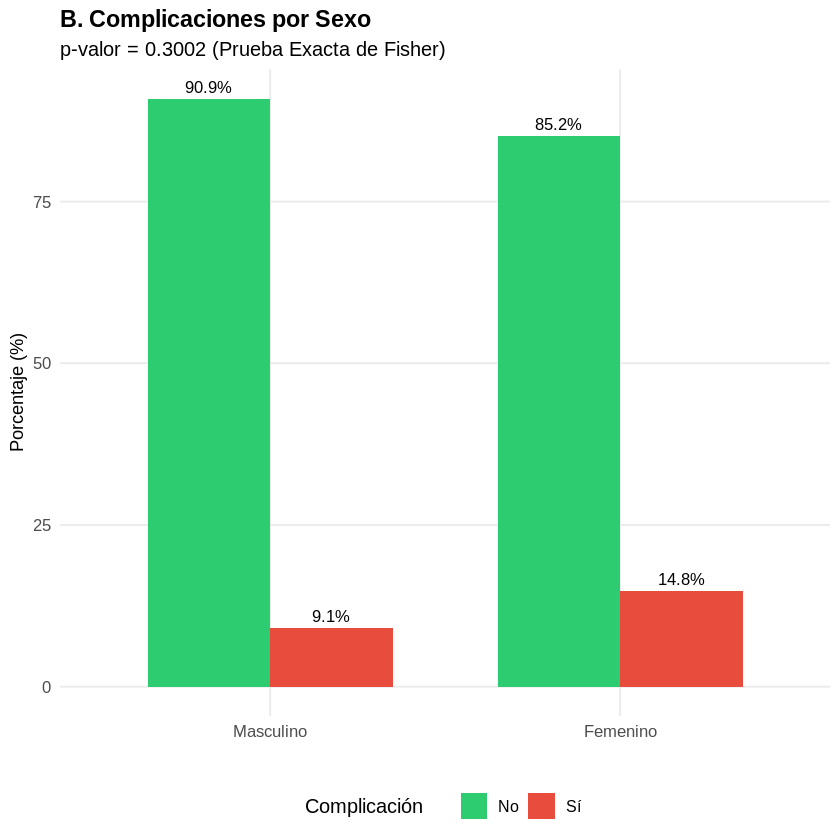

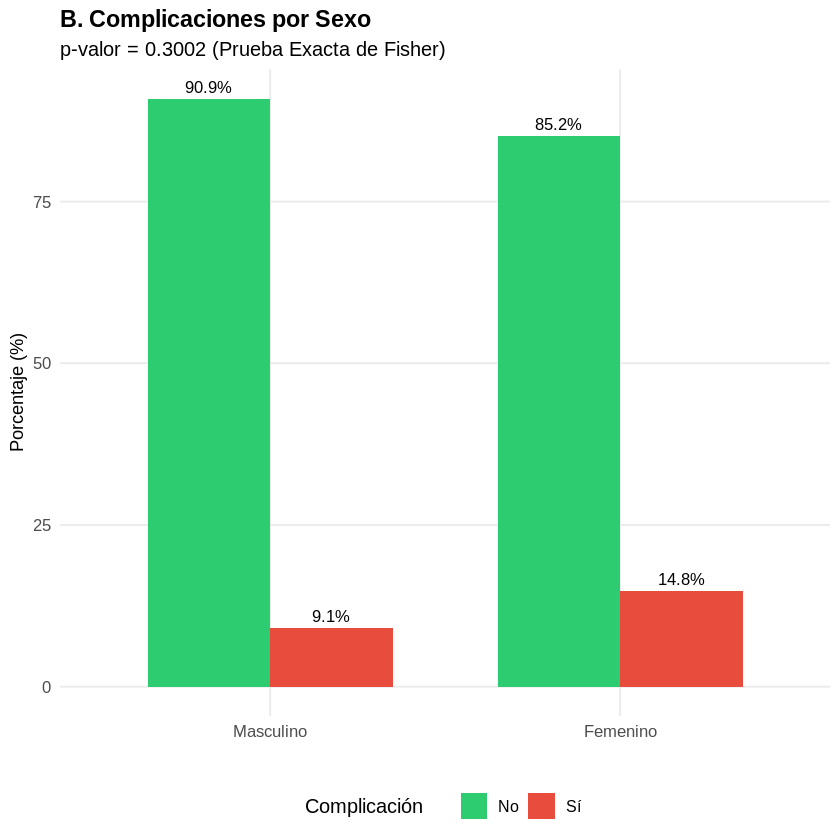

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


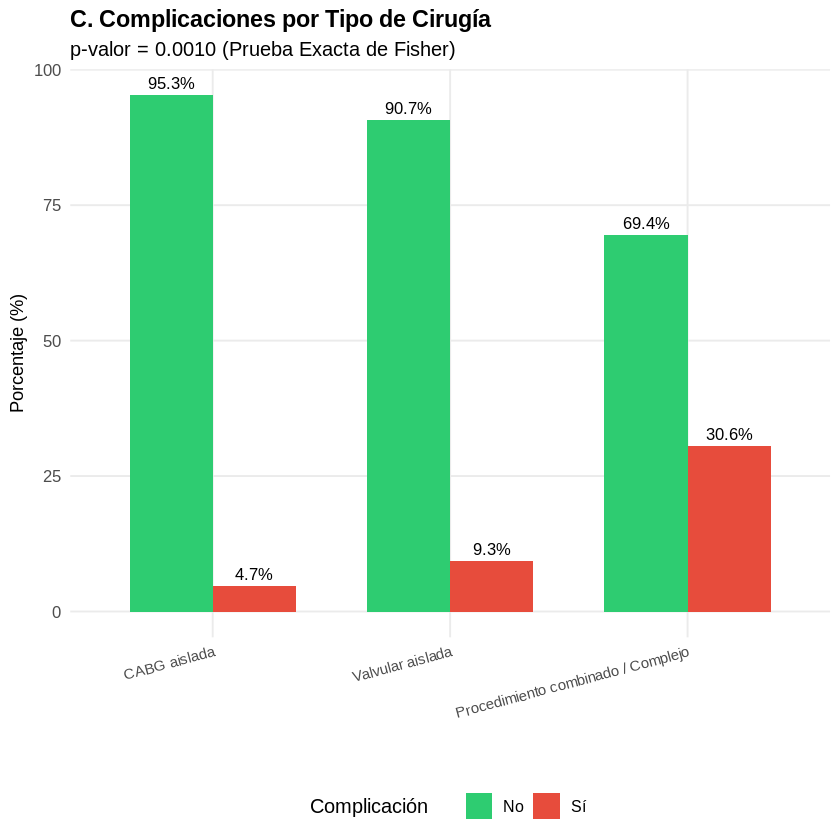

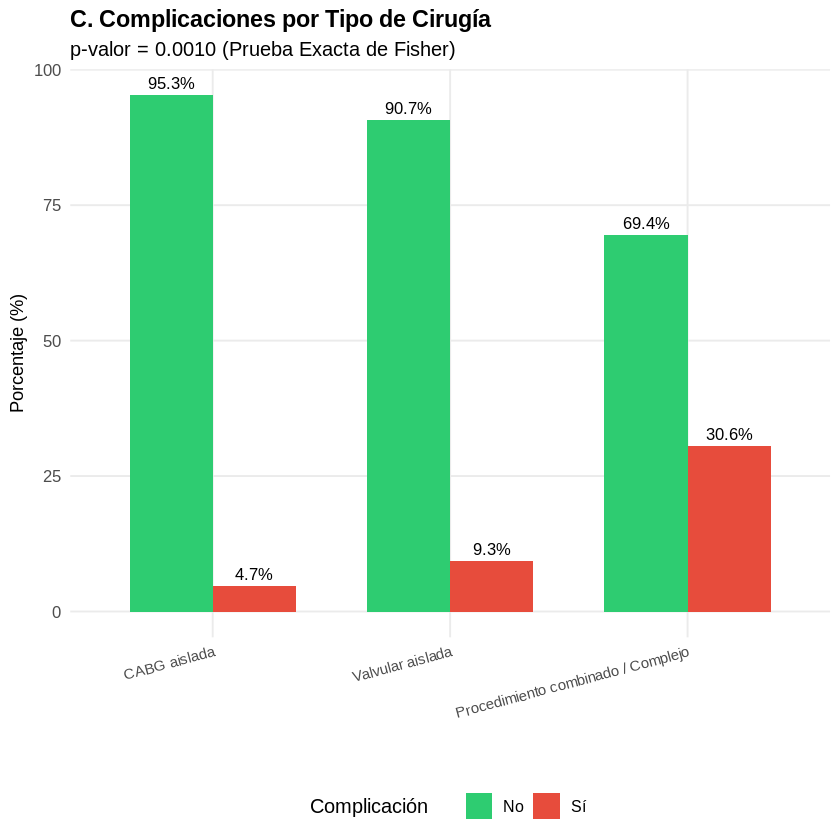

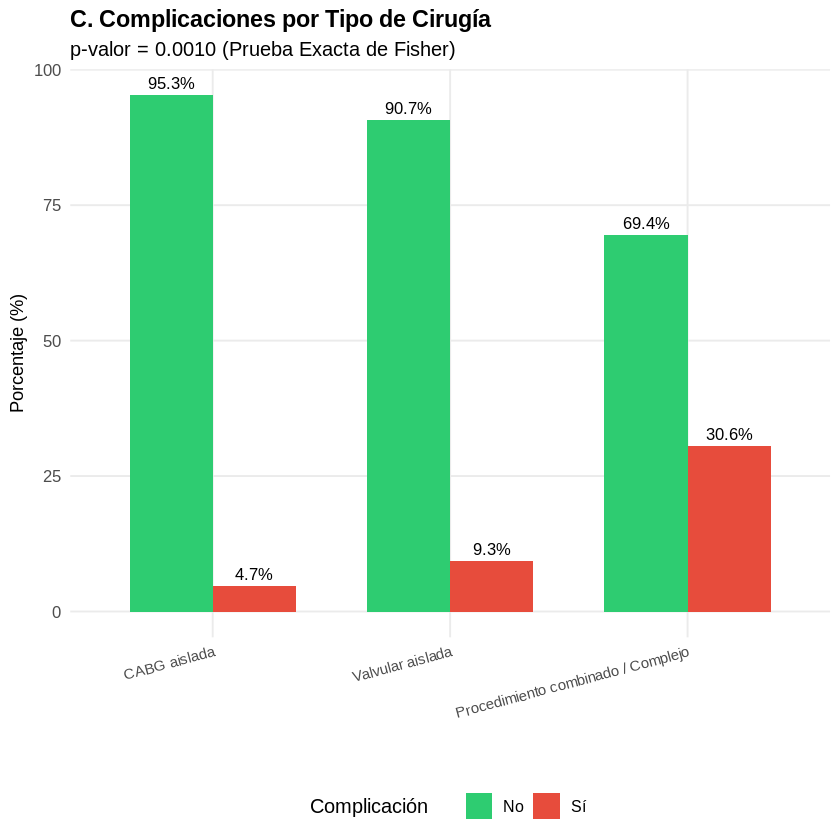

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


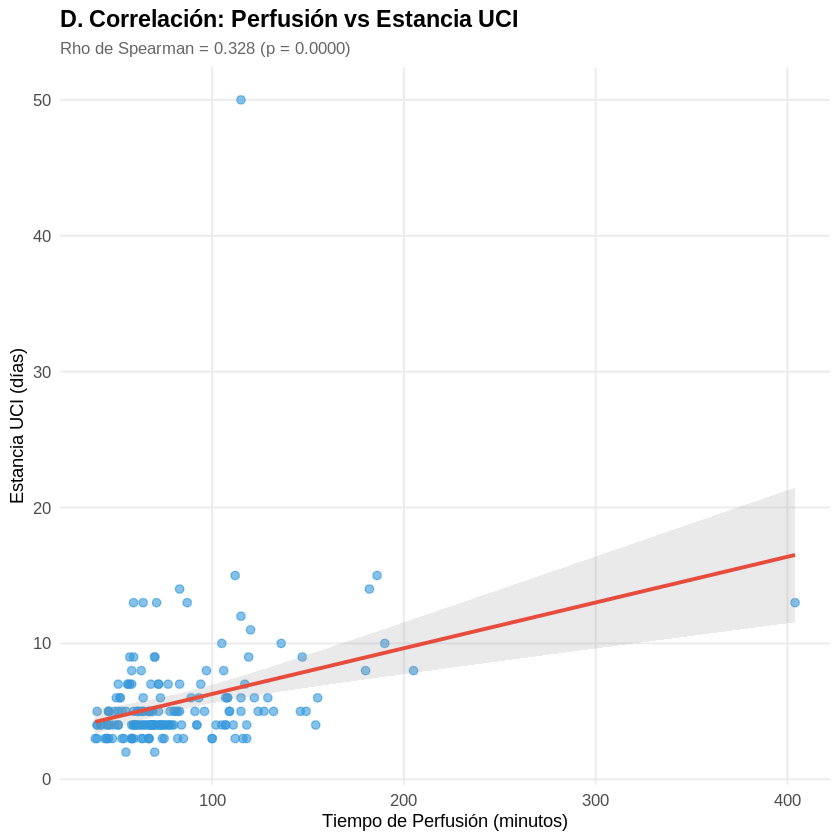

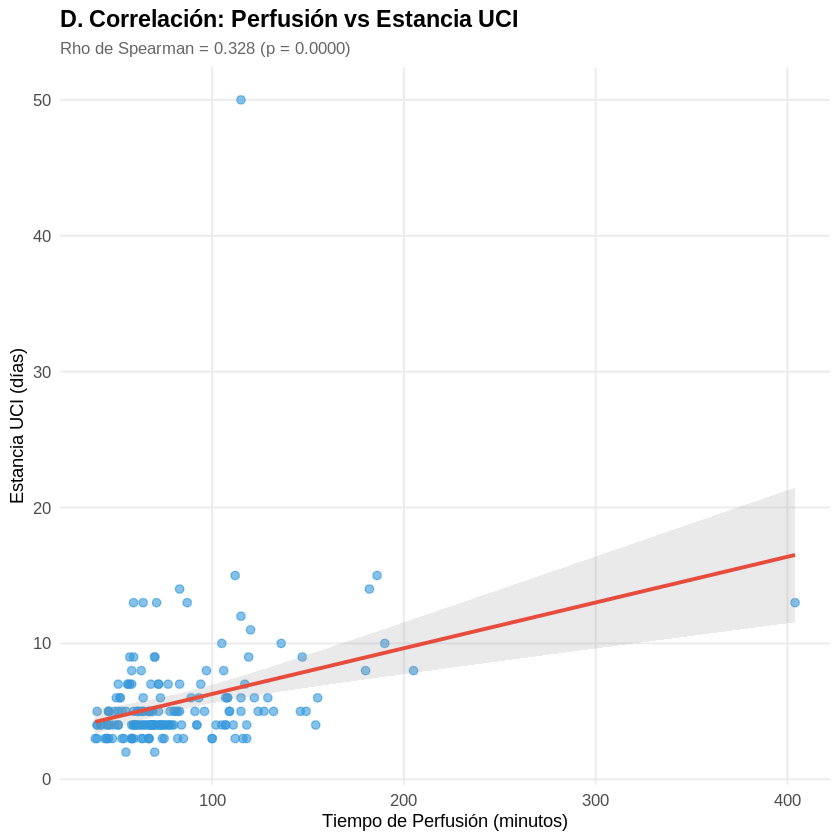

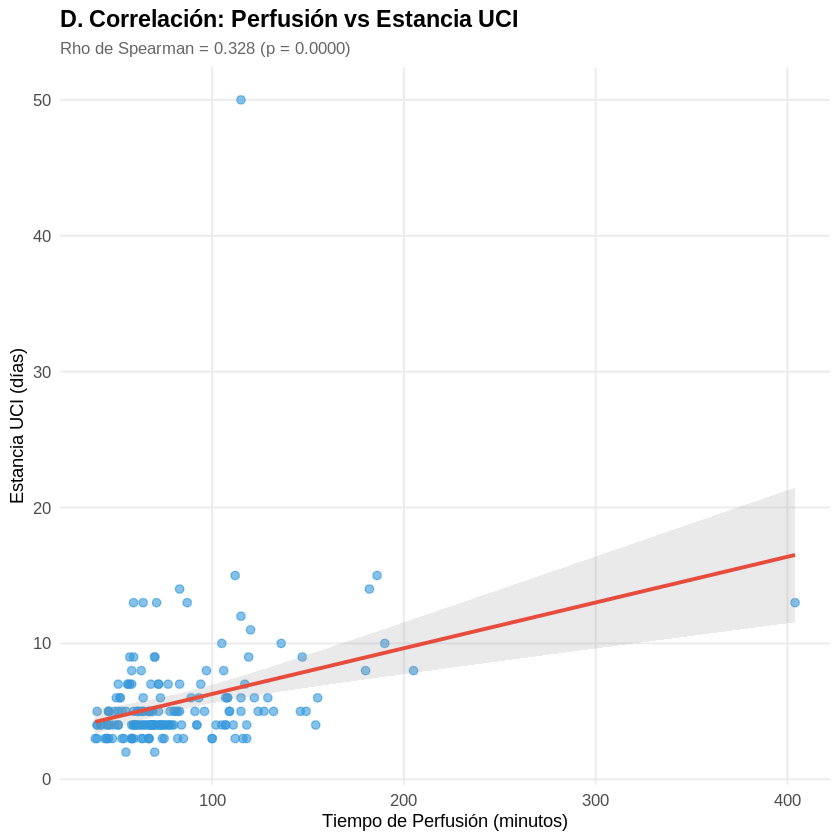




=== 6.1.7 EXPORTANDO RESULTADOS ===
=== 6.1.7 EXPORTANDO RESULTADOS ===
=== 6.1.7 EXPORTANDO RESULTADOS ===
✅ Gráfico edad vs complicación exportado a 'bivariado_edad_complicacion.pdf'
✅ Gráfico edad vs complicación exportado a 'bivariado_edad_complicacion.pdf'
✅ Gráfico edad vs complicación exportado a 'bivariado_edad_complicacion.pdf'
✅ Gráfico sexo vs complicación exportado a 'bivariado_sexo_complicacion.pdf'
✅ Gráfico sexo vs complicación exportado a 'bivariado_sexo_complicacion.pdf'
✅ Gráfico sexo vs complicación exportado a 'bivariado_sexo_complicacion.pdf'
✅ Gráfico cirugía vs complicación exportado a 'bivariado_cirugia_complicacion.pdf'
✅ Gráfico cirugía vs complicación exportado a 'bivariado_cirugia_complicacion.pdf'
✅ Gráfico cirugía vs complicación exportado a 'bivariado_cirugia_complicacion.pdf'


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


✅ Gráfico perfusión vs UCI exportado a 'bivariado_perfusion_uci.pdf'
✅ Gráfico perfusión vs UCI exportado a 'bivariado_perfusion_uci.pdf'
✅ Gráfico perfusión vs UCI exportado a 'bivariado_perfusion_uci.pdf'


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


✅ Gráfico clampeo vs UCI exportado a 'bivariado_clampeo_uci.pdf'
✅ Gráfico clampeo vs UCI exportado a 'bivariado_clampeo_uci.pdf'
✅ Gráfico clampeo vs UCI exportado a 'bivariado_clampeo_uci.pdf'
✅ Resultados categóricos exportados a 'bivariado_resultados_categoricos.xlsx'
✅ Resultados categóricos exportados a 'bivariado_resultados_categoricos.xlsx'
✅ Resultados categóricos exportados a 'bivariado_resultados_categoricos.xlsx'
✅ Estadísticas de edad exportadas a 'bivariado_edad_stats.xlsx'
✅ Estadísticas de edad exportadas a 'bivariado_edad_stats.xlsx'
✅ Estadísticas de edad exportadas a 'bivariado_edad_stats.xlsx'
✅ Correlaciones de Spearman exportadas a 'bivariado_correlaciones_spearman.xlsx'
✅ Correlaciones de Spearman exportadas a 'bivariado_correlaciones_spearman.xlsx'
✅ Correlaciones de Spearman exportadas a 'bivariado_correlaciones_spearman.xlsx'
✅ Todos los archivos CSV generados
✅ Todos los archivos CSV generados
✅ Todos los archivos CSV generados



=== 6.1.8 RESUMEN EJECUTIVO 

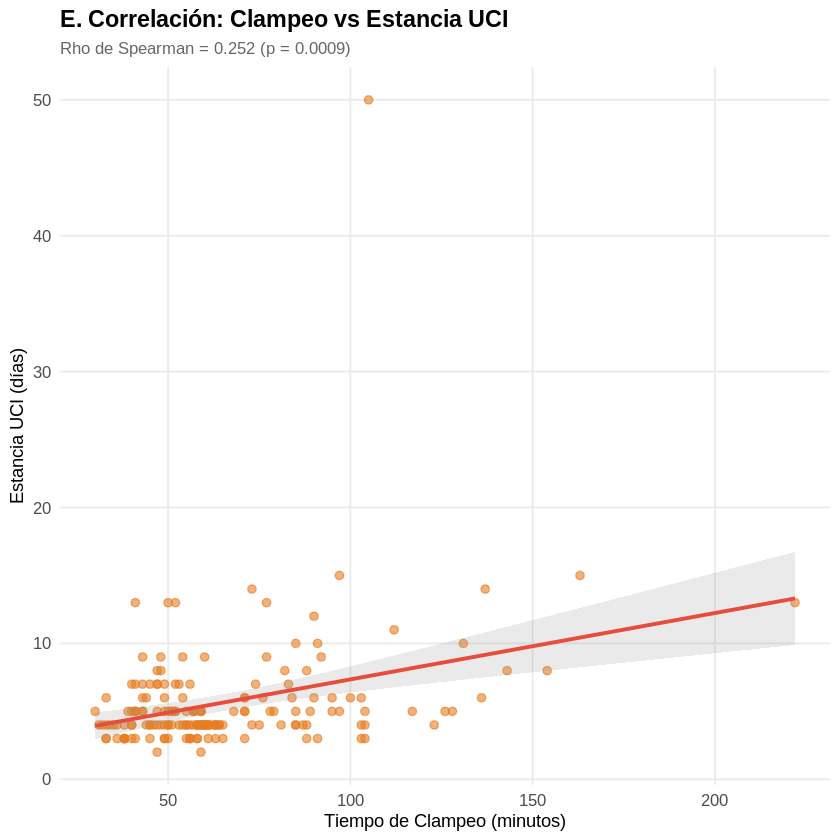

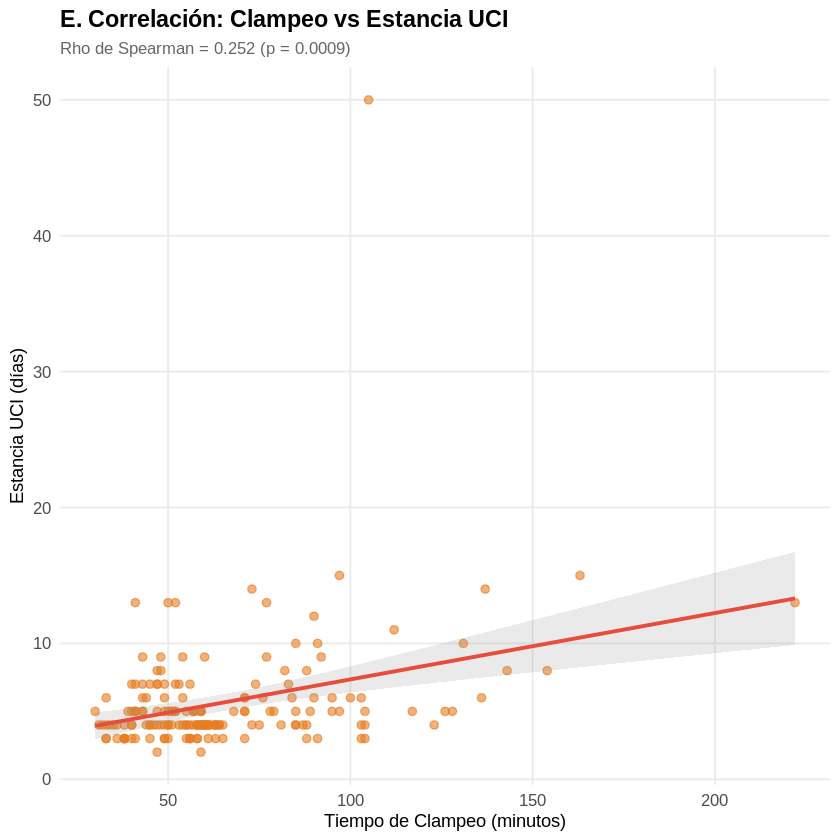

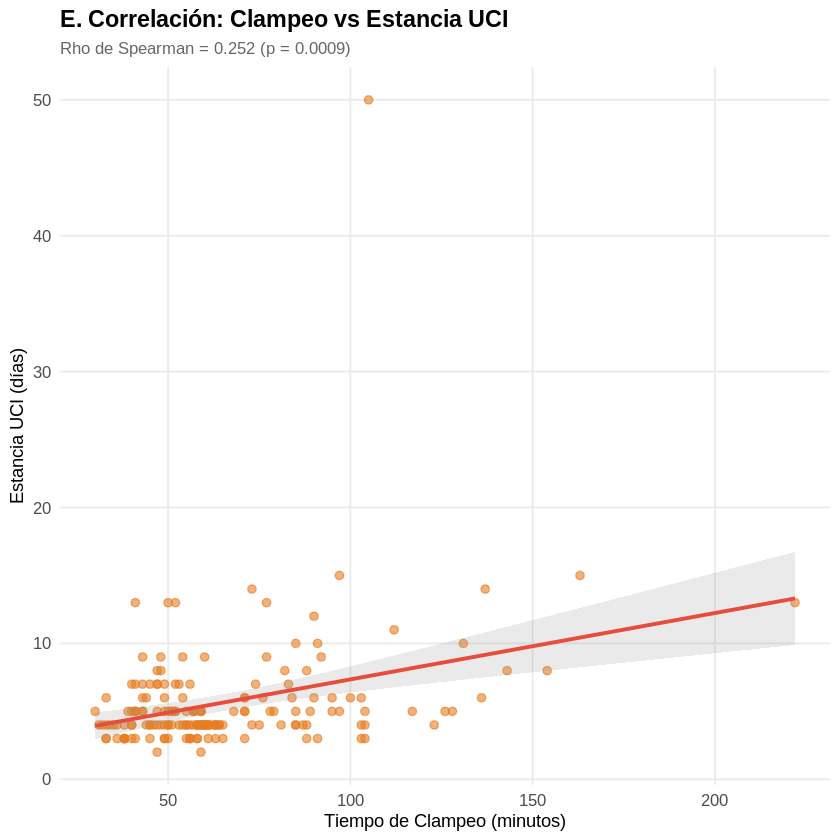

In [10]:
# ==============================================================================
# 6.1 ANÁLISIS BIVARIADO EXPLORATORIO
# ==============================================================================

# ------------------------------------------------------------------------------
# 6.1.1 PREPARACIÓN DE VARIABLES
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 6.1.1 PREPARACIÓN DE VARIABLES ===\n")
cat(rep("=", 80), "\n", sep = "")

# Crear variable de complicación global (cualquier complicación)
datos_icb_clean <- datos_icb_clean %>%
  mutate(
    complicacion_global = ifelse(
      acv_real == 1 | ira_real == 1 | reintervencion_real == 1 | isop_real == 1 |
      fallecido_24h == 1 | fallecido_30d_unic == 1,
      1, 0
    ),
    complicacion_global_label = ifelse(complicacion_global == 1, "Sí", "No"),
    complicacion_global_label = factor(complicacion_global_label, levels = c("No", "Sí"))
  )

cat("\n📊 Distribución de complicación global:\n")
print(table(datos_icb_clean$complicacion_global_label, useNA = "ifany"))

# ------------------------------------------------------------------------------
# 6.1.2 FUNCIONES AUXILIARES PARA ANÁLISIS BIVARIADO
# ------------------------------------------------------------------------------

# Función para análisis de asociación categórica
analizar_asociacion_categorica <- function(data, var_predictora, var_desenlace,
                                           nombre_predictora, nombre_desenlace) {

  # Crear tabla de contingencia
  tabla <- table(data[[var_predictora]], data[[var_desenlace]], useNA = "ifany")

  # Calcular porcentajes por fila
  porcentajes <- prop.table(tabla, 1) * 100

  # Determinar método estadístico
  esperados <- chisq.test(tabla)$expected
  celdas_esperadas_menor_5 <- sum(esperados < 5, na.rm = TRUE)

  if (celdas_esperadas_menor_5 > 0 || any(dim(tabla) == 2)) {
    # Usar prueba exacta de Fisher
    prueba <- fisher.test(tabla, simulate.p.value = TRUE)
    metodo <- "Prueba Exacta de Fisher"
    estadistico <- NA
    gl <- NA
    or <- tryCatch(oddsratio(tabla), error = function(e) NA)
    or_ic <- tryCatch(or <- oddsratio(tabla, method = "fisher"), error = function(e) NA)
  } else {
    # Usar chi-cuadrado de Pearson
    prueba <- chisq.test(tabla)
    metodo <- "Chi-cuadrado de Pearson"
    estadistico <- prueba$statistic
    gl <- prueba$parameter
    or <- NA
    or_ic <- NA
  }

  return(list(
    tabla = tabla,
    porcentajes = porcentajes,
    metodo = metodo,
    estadistico = estadistico,
    p_valor = prueba$p.value,
    gl = gl,
    or = or,
    or_ic = or_ic,
    celdas_esperadas_menor_5 = celdas_esperadas_menor_5
  ))
}

# ------------------------------------------------------------------------------
# 6.1.3 ASOCIACIONES CATEGÓRICAS
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 6.1.3 ASOCIACIONES CATEGÓRICAS ===\n")
cat(rep("=", 80), "\n", sep = "")

# 6.1.3.1 Sexo vs Complicación global
cat("\n📊 SEXO vs COMPLICACIÓN GLOBAL:\n")
cat("-", 60, "\n", sep = "")

resultado_sexo <- analizar_asociacion_categorica(
  datos_icb_clean, "sexo", "complicacion_global",
  "Sexo", "Complicación global"
)

cat("\nTabla de contingencia:\n")
print(resultado_sexo$tabla)
cat("\nPorcentajes por fila:\n")
print(round(resultado_sexo$porcentajes, 1))
cat(sprintf("\nMétodo: %s\n", resultado_sexo$metodo))
cat(sprintf("p-valor: %.4f\n", resultado_sexo$p_valor))
cat(sprintf("Significativo: %s\n", ifelse(resultado_sexo$p_valor < 0.05, "✅ Sí", "❌ No")))

# 6.1.3.2 Sexo vs Mortalidad
cat("\n\n📊 SEXO vs MORTALIDAD A 30 DÍAS:\n")
cat("-", 60, "\n", sep = "")

resultado_sexo_mortalidad <- analizar_asociacion_categorica(
  datos_icb_clean, "sexo", "mortalidad_30d",
  "Sexo", "Mortalidad"
)

cat("\nTabla de contingencia:\n")
print(resultado_sexo_mortalidad$tabla)
cat("\nPorcentajes por fila:\n")
print(round(resultado_sexo_mortalidad$porcentajes, 1))
cat(sprintf("\nMétodo: %s\n", resultado_sexo_mortalidad$metodo))
cat(sprintf("p-valor: %.4f\n", resultado_sexo_mortalidad$p_valor))
cat(sprintf("Significativo: %s\n", ifelse(resultado_sexo_mortalidad$p_valor < 0.05, "✅ Sí", "❌ No")))

# 6.1.3.3 Tipo de cirugía vs Complicación global
cat("\n\n📊 TIPO DE CIRUGÍA vs COMPLICACIÓN GLOBAL:\n")
cat("-", 60, "\n", sep = "")

resultado_cirugia <- analizar_asociacion_categorica(
  datos_icb_clean, "categoria_cirugia_realizada", "complicacion_global",
  "Tipo de cirugía", "Complicación global"
)

cat("\nTabla de contingencia:\n")
print(resultado_cirugia$tabla)
cat("\nPorcentajes por fila:\n")
print(round(resultado_cirugia$porcentajes, 1))
cat(sprintf("\nMétodo: %s\n", resultado_cirugia$metodo))
cat(sprintf("p-valor: %.4f\n", resultado_cirugia$p_valor))
cat(sprintf("Significativo: %s\n", ifelse(resultado_cirugia$p_valor < 0.05, "✅ Sí", "❌ No")))

# 6.1.3.4 Tipo de cirugía vs Mortalidad
cat("\n\n📊 TIPO DE CIRUGÍA vs MORTALIDAD A 30 DÍAS:\n")
cat("-", 60, "\n", sep = "")

resultado_cirugia_mortalidad <- analizar_asociacion_categorica(
  datos_icb_clean, "categoria_cirugia_realizada", "mortalidad_30d",
  "Tipo de cirugía", "Mortalidad"
)

cat("\nTabla de contingencia:\n")
print(resultado_cirugia_mortalidad$tabla)
cat("\nPorcentajes por fila:\n")
print(round(resultado_cirugia_mortalidad$porcentajes, 1))
cat(sprintf("\nMétodo: %s\n", resultado_cirugia_mortalidad$metodo))
cat(sprintf("p-valor: %.4f\n", resultado_cirugia_mortalidad$p_valor))
cat(sprintf("Significativo: %s\n", ifelse(resultado_cirugia_mortalidad$p_valor < 0.05, "✅ Sí", "❌ No")))

# 6.1.3.5 Uso de bomba vs Complicación global
cat("\n\n📊 USO DE BOMBA vs COMPLICACIÓN GLOBAL:\n")
cat("-", 60, "\n", sep = "")

resultado_bomba <- analizar_asociacion_categorica(
  datos_icb_clean, "bomba", "complicacion_global",
  "Uso de bomba", "Complicación global"
)

cat("\nTabla de contingencia:\n")
print(resultado_bomba$tabla)
cat("\nPorcentajes por fila:\n")
print(round(resultado_bomba$porcentajes, 1))
cat(sprintf("\nMétodo: %s\n", resultado_bomba$metodo))
cat(sprintf("p-valor: %.4f\n", resultado_bomba$p_valor))
cat(sprintf("Significativo: %s\n", ifelse(resultado_bomba$p_valor < 0.05, "✅ Sí", "❌ No")))

# ------------------------------------------------------------------------------
# 6.1.4 ASOCIACIÓN: EDAD vs COMPLICACIÓN GLOBAL
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 6.1.4 ASOCIACIÓN: EDAD vs COMPLICACIÓN GLOBAL ===\n")
cat(rep("=", 80), "\n", sep = "")

# Verificar normalidad de edad en los grupos
cat("\n📊 PRUEBA DE NORMALIDAD POR GRUPO:\n")
cat("-", 60, "\n", sep = "")

# Edad en pacientes con complicación
edad_con_complicacion <- datos_icb_clean$edad[datos_icb_clean$complicacion_global == 1]
edad_sin_complicacion <- datos_icb_clean$edad[datos_icb_clean$complicacion_global == 0]

cat("\nEdad - Con complicación:\n")
if (length(edad_con_complicacion) >= 3) {
  shapiro_con <- shapiro.test(edad_con_complicacion)
  cat(sprintf("  • Shapiro-Wilk p-valor: %.4f\n", shapiro_con$p.value))
  cat(sprintf("  • ¿Normal?: %s\n", ifelse(shapiro_con$p.value > 0.05, "✅ Sí", "❌ No")))
} else {
  cat("  • Número insuficiente para prueba de normalidad\n")
}

cat("\nEdad - Sin complicación:\n")
if (length(edad_sin_complicacion) >= 3) {
  shapiro_sin <- shapiro.test(edad_sin_complicacion)
  cat(sprintf("  • Shapiro-Wilk p-valor: %.4f\n", shapiro_sin$p.value))
  cat(sprintf("  • ¿Normal?: %s\n", ifelse(shapiro_sin$p.value > 0.05, "✅ Sí", "❌ No")))
} else {
  cat("  • Número insuficiente para prueba de normalidad\n")
}

# Estadísticas descriptivas por grupo
cat("\n📊 COMPARACIÓN DE EDAD SEGÚN COMPLICACIÓN:\n")
cat("-", 60, "\n", sep = "")

edad_stats_grupos <- datos_icb_clean %>%
  group_by(complicacion_global_label) %>%
  summarise(
    n = n(),
    Media = round(mean(edad, na.rm = TRUE), 1),
    DE = round(sd(edad, na.rm = TRUE), 1),
    Mediana = round(median(edad, na.rm = TRUE), 1),
    Q1 = round(quantile(edad, 0.25, na.rm = TRUE), 1),
    Q3 = round(quantile(edad, 0.75, na.rm = TRUE), 1),
    Min = min(edad, na.rm = TRUE),
    Max = max(edad, na.rm = TRUE)
  )

print(edad_stats_grupos)

# Prueba estadística (U de Mann-Whitney por no normalidad)
prueba_edad <- wilcox.test(edad ~ complicacion_global, data = datos_icb_clean)
metodo_edad <- "U de Mann-Whitney (no paramétrica)"

cat(sprintf("\nMétodo: %s\n", metodo_edad))
cat(sprintf("Estadístico W: %.0f\n", prueba_edad$statistic))
cat(sprintf("p-valor: %.4f\n", prueba_edad$p.value))
cat(sprintf("Significativo: %s\n", ifelse(prueba_edad$p.value < 0.05, "✅ Sí", "❌ No")))

# 6.1.4.2 Edad vs Mortalidad
cat("\n\n📊 COMPARACIÓN DE EDAD SEGÚN MORTALIDAD:\n")
cat("-", 60, "\n", sep = "")

edad_stats_mortalidad <- datos_icb_clean %>%
  group_by(mortalidad_30d) %>%
  summarise(
    n = n(),
    Media = round(mean(edad, na.rm = TRUE), 1),
    DE = round(sd(edad, na.rm = TRUE), 1),
    Mediana = round(median(edad, na.rm = TRUE), 1),
    Q1 = round(quantile(edad, 0.25, na.rm = TRUE), 1),
    Q3 = round(quantile(edad, 0.75, na.rm = TRUE), 1)
  )

print(edad_stats_mortalidad)

# Prueba para mortalidad
prueba_mortalidad <- wilcox.test(edad ~ mortalidad_30d, data = datos_icb_clean)
cat(sprintf("\nMétodo: U de Mann-Whitney\n"))
cat(sprintf("Estadístico W: %.0f\n", prueba_mortalidad$statistic))
cat(sprintf("p-valor: %.4f\n", prueba_mortalidad$p.value))
cat(sprintf("Significativo: %s\n", ifelse(prueba_mortalidad$p.value < 0.05, "✅ Sí", "❌ No")))

# ------------------------------------------------------------------------------
# 6.1.5 CORRELACIÓN DE SPEARMAN: TIEMPOS QUIRÚRGICOS vs ESTANCIAS
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 6.1.5 CORRELACIÓN DE SPEARMAN: TIEMPOS QUIRÚRGICOS vs ESTANCIAS ===\n")
cat(rep("=", 80), "\n", sep = "")

# Filtrar solo pacientes con bomba (on-pump) para tiempos quirúrgicos
datos_on_pump <- datos_icb_clean %>%
  filter(bomba == 1 & !is.na(perfusion_corregida) & !is.na(clampeo_corregido))

cat(sprintf("\nPacientes on-pump incluidos en el análisis: %d\n", nrow(datos_on_pump)))

if (nrow(datos_on_pump) > 0) {

  # 6.1.5.1 Perfusión vs Ventilación mecánica
  cat("\n📊 CORRELACIÓN: Perfusión vs Ventilación Mecánica\n")
  cat("-", 60, "\n", sep = "")

  cor_perfusion_vent <- cor.test(datos_on_pump$perfusion_corregida,
                                 datos_on_pump$dias_ventilacion_mecanica,
                                 method = "spearman")

  cat(sprintf("  • Rho de Spearman: %.3f\n", cor_perfusion_vent$estimate))
  cat(sprintf("  • p-valor: %.4f\n", cor_perfusion_vent$p.value))
  cat(sprintf("  • Significativo: %s\n", ifelse(cor_perfusion_vent$p.value < 0.05, "✅ Sí", "❌ No")))
  cat(sprintf("  • Interpretación: %s\n",
              ifelse(abs(cor_perfusion_vent$estimate) < 0.3, "Asociación débil",
                     ifelse(abs(cor_perfusion_vent$estimate) < 0.5, "Asociación moderada",
                            ifelse(abs(cor_perfusion_vent$estimate) < 0.7, "Asociación fuerte",
                                   "Asociación muy fuerte")))))

  # 6.1.5.2 Perfusión vs Estancia UCI
  cat("\n📊 CORRELACIÓN: Perfusión vs Estancia UCI\n")
  cat("-", 60, "\n", sep = "")

  cor_perfusion_uci <- cor.test(datos_on_pump$perfusion_corregida,
                                datos_on_pump$estancia_uci,
                                method = "spearman")

  cat(sprintf("  • Rho de Spearman: %.3f\n", cor_perfusion_uci$estimate))
  cat(sprintf("  • p-valor: %.4f\n", cor_perfusion_uci$p.value))
  cat(sprintf("  • Significativo: %s\n", ifelse(cor_perfusion_uci$p.value < 0.05, "✅ Sí", "❌ No")))
  cat(sprintf("  • Interpretación: %s\n",
              ifelse(abs(cor_perfusion_uci$estimate) < 0.3, "Asociación débil",
                     ifelse(abs(cor_perfusion_uci$estimate) < 0.5, "Asociación moderada",
                            ifelse(abs(cor_perfusion_uci$estimate) < 0.7, "Asociación fuerte",
                                   "Asociación muy fuerte")))))

  # 6.1.5.3 Clampeo vs Ventilación mecánica
  cat("\n📊 CORRELACIÓN: Clampeo vs Ventilación Mecánica\n")
  cat("-", 60, "\n", sep = "")

  cor_clampeo_vent <- cor.test(datos_on_pump$clampeo_corregido,
                               datos_on_pump$dias_ventilacion_mecanica,
                               method = "spearman")

  cat(sprintf("  • Rho de Spearman: %.3f\n", cor_clampeo_vent$estimate))
  cat(sprintf("  • p-valor: %.4f\n", cor_clampeo_vent$p.value))
  cat(sprintf("  • Significativo: %s\n", ifelse(cor_clampeo_vent$p.value < 0.05, "✅ Sí", "❌ No")))
  cat(sprintf("  • Interpretación: %s\n",
              ifelse(abs(cor_clampeo_vent$estimate) < 0.3, "Asociación débil",
                     ifelse(abs(cor_clampeo_vent$estimate) < 0.5, "Asociación moderada",
                            ifelse(abs(cor_clampeo_vent$estimate) < 0.7, "Asociación fuerte",
                                   "Asociación muy fuerte")))))

  # 6.1.5.4 Clampeo vs Estancia UCI
  cat("\n📊 CORRELACIÓN: Clampeo vs Estancia UCI\n")
  cat("-", 60, "\n", sep = "")

  cor_clampeo_uci <- cor.test(datos_on_pump$clampeo_corregido,
                              datos_on_pump$estancia_uci,
                              method = "spearman")

  cat(sprintf("  • Rho de Spearman: %.3f\n", cor_clampeo_uci$estimate))
  cat(sprintf("  • p-valor: %.4f\n", cor_clampeo_uci$p.value))
  cat(sprintf("  • Significativo: %s\n", ifelse(cor_clampeo_uci$p.value < 0.05, "✅ Sí", "❌ No")))
  cat(sprintf("  • Interpretación: %s\n",
              ifelse(abs(cor_clampeo_uci$estimate) < 0.3, "Asociación débil",
                     ifelse(abs(cor_clampeo_uci$estimate) < 0.5, "Asociación moderada",
                            ifelse(abs(cor_clampeo_uci$estimate) < 0.7, "Asociación fuerte",
                                   "Asociación muy fuerte")))))

  # 6.1.5.5 Resumen de correlaciones
  cat("\n📊 RESUMEN DE CORRELACIONES DE SPEARMAN:\n")
  cat("-", 60, "\n", sep = "")

  correlaciones <- data.frame(
    Variable1 = c("Perfusión", "Perfusión", "Clampeo", "Clampeo"),
    Variable2 = c("Ventilación", "Estancia UCI", "Ventilación", "Estancia UCI"),
    Rho = c(cor_perfusion_vent$estimate,
            cor_perfusion_uci$estimate,
            cor_clampeo_vent$estimate,
            cor_clampeo_uci$estimate),
    p_valor = c(cor_perfusion_vent$p.value,
                cor_perfusion_uci$p.value,
                cor_clampeo_vent$p.value,
                cor_clampeo_uci$p.value),
    Significativo = c(cor_perfusion_vent$p.value < 0.05,
                      cor_perfusion_uci$p.value < 0.05,
                      cor_clampeo_vent$p.value < 0.05,
                      cor_clampeo_uci$p.value < 0.05)
  )

  print(correlaciones)
}

# ------------------------------------------------------------------------------
# 6.1.6 GRÁFICOS DE ASOCIACIONES
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 6.1.6 GENERANDO GRÁFICOS DE ASOCIACIONES ===\n")
cat(rep("=", 80), "\n", sep = "")

# 6.1.6.1 Boxplot: Edad vs Complicación
plot_edad_complicacion <- ggplot(datos_icb_clean,
                                 aes(x = complicacion_global_label, y = edad, fill = complicacion_global_label)) +
  geom_boxplot(alpha = 0.7, outlier.size = 1.5, outlier.alpha = 0.5, width = 0.7) +
  scale_fill_manual(values = c("No" = "#2ecc71", "Sí" = "#e74c3c")) +
  labs(
    title = "A. Edad según Complicación Perioperatoria",
    subtitle = sprintf("p-valor = %.4f (U de Mann-Whitney)", prueba_edad$p.value),
    x = "",
    y = "Edad (años)",
    fill = "Complicación"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 10, color = "gray40"),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )

print(plot_edad_complicacion)

# 6.1.6.2 Gráfico de barras agrupado: Sexo vs Complicación
plot_sexo_complicacion <- datos_icb_clean %>%
  filter(!is.na(sexo) & !is.na(complicacion_global_label)) %>%
  group_by(sexo, complicacion_global_label) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(sexo) %>%
  mutate(porcentaje = n / sum(n) * 100) %>%
  ggplot(aes(x = sexo, y = porcentaje, fill = complicacion_global_label)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  geom_text(aes(label = sprintf("%.1f%%", porcentaje)),
            position = position_dodge(0.7), vjust = -0.5, size = 3.5) +
  scale_fill_manual(values = c("No" = "#2ecc71", "Sí" = "#e74c3c")) +
  labs(
    title = "B. Complicaciones por Sexo",
    subtitle = sprintf("p-valor = %.4f (%s)", resultado_sexo$p_valor, resultado_sexo$metodo),
    x = "",
    y = "Porcentaje (%)",
    fill = "Complicación"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )

print(plot_sexo_complicacion)

# 6.1.6.3 Gráfico de barras agrupado: Tipo de cirugía vs Complicación
plot_cirugia_complicacion <- datos_icb_clean %>%
  filter(!is.na(categoria_cirugia_realizada) & !is.na(complicacion_global_label)) %>%
  group_by(categoria_cirugia_realizada, complicacion_global_label) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(categoria_cirugia_realizada) %>%
  mutate(porcentaje = n / sum(n) * 100) %>%
  ggplot(aes(x = categoria_cirugia_realizada, y = porcentaje, fill = complicacion_global_label)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  geom_text(aes(label = sprintf("%.1f%%", porcentaje)),
            position = position_dodge(0.7), vjust = -0.5, size = 3.5) +
  scale_fill_manual(values = c("No" = "#2ecc71", "Sí" = "#e74c3c")) +
  labs(
    title = "C. Complicaciones por Tipo de Cirugía",
    subtitle = sprintf("p-valor = %.4f (%s)", resultado_cirugia$p_valor, resultado_cirugia$metodo),
    x = "",
    y = "Porcentaje (%)",
    fill = "Complicación"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    axis.text.x = element_text(size = 9, angle = 15, hjust = 1),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 11),
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )

print(plot_cirugia_complicacion)

# 6.1.6.4 Gráfico de dispersión: Perfusión vs Estancia UCI
if (exists("datos_on_pump") && nrow(datos_on_pump) > 0) {
  plot_perfusion_uci <- ggplot(datos_on_pump, aes(x = perfusion_corregida, y = estancia_uci)) +
    geom_point(alpha = 0.6, size = 2, color = "#3498db") +
    geom_smooth(method = "lm", se = TRUE, color = "#e74c3c", alpha = 0.2) +
    labs(
      title = "D. Correlación: Perfusión vs Estancia UCI",
      subtitle = sprintf("Rho de Spearman = %.3f (p = %.4f)",
                         cor_perfusion_uci$estimate, cor_perfusion_uci$p.value),
      x = "Tiempo de Perfusión (minutos)",
      y = "Estancia UCI (días)"
    ) +
    theme_minimal(base_size = 12) +
    theme(
      plot.title = element_text(face = "bold", size = 14),
      plot.subtitle = element_text(size = 10, color = "gray40"),
      axis.text = element_text(size = 10),
      axis.title = element_text(size = 11),
      panel.grid.minor = element_blank()
    )

  print(plot_perfusion_uci)
}

# 6.1.6.5 Gráfico de dispersión: Clampeo vs Estancia UCI
if (exists("datos_on_pump") && nrow(datos_on_pump) > 0) {
  plot_clampeo_uci <- ggplot(datos_on_pump, aes(x = clampeo_corregido, y = estancia_uci)) +
    geom_point(alpha = 0.6, size = 2, color = "#e67e22") +
    geom_smooth(method = "lm", se = TRUE, color = "#e74c3c", alpha = 0.2) +
    labs(
      title = "E. Correlación: Clampeo vs Estancia UCI",
      subtitle = sprintf("Rho de Spearman = %.3f (p = %.4f)",
                         cor_clampeo_uci$estimate, cor_clampeo_uci$p.value),
      x = "Tiempo de Clampeo (minutos)",
      y = "Estancia UCI (días)"
    ) +
    theme_minimal(base_size = 12) +
    theme(
      plot.title = element_text(face = "bold", size = 14),
      plot.subtitle = element_text(size = 10, color = "gray40"),
      axis.text = element_text(size = 10),
      axis.title = element_text(size = 11),
      panel.grid.minor = element_blank()
    )

  print(plot_clampeo_uci)
}

# ------------------------------------------------------------------------------
# 6.1.7 EXPORTACIÓN DE RESULTADOS
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 6.1.7 EXPORTANDO RESULTADOS ===\n")
cat(rep("=", 80), "\n", sep = "")

# 6.1.7.1 Exportar gráficos
ggsave(filename = "bivariado_edad_complicacion.pdf", plot = plot_edad_complicacion,
       width = 8, height = 6, dpi = 300, device = "pdf")
cat("✅ Gráfico edad vs complicación exportado a 'bivariado_edad_complicacion.pdf'\n")

ggsave(filename = "bivariado_sexo_complicacion.pdf", plot = plot_sexo_complicacion,
       width = 8, height = 6, dpi = 300, device = "pdf")
cat("✅ Gráfico sexo vs complicación exportado a 'bivariado_sexo_complicacion.pdf'\n")

ggsave(filename = "bivariado_cirugia_complicacion.pdf", plot = plot_cirugia_complicacion,
       width = 8, height = 6, dpi = 300, device = "pdf")
cat("✅ Gráfico cirugía vs complicación exportado a 'bivariado_cirugia_complicacion.pdf'\n")

if (exists("plot_perfusion_uci")) {
  ggsave(filename = "bivariado_perfusion_uci.pdf", plot = plot_perfusion_uci,
         width = 8, height = 6, dpi = 300, device = "pdf")
  cat("✅ Gráfico perfusión vs UCI exportado a 'bivariado_perfusion_uci.pdf'\n")
}

if (exists("plot_clampeo_uci")) {
  ggsave(filename = "bivariado_clampeo_uci.pdf", plot = plot_clampeo_uci,
         width = 8, height = 6, dpi = 300, device = "pdf")
  cat("✅ Gráfico clampeo vs UCI exportado a 'bivariado_clampeo_uci.pdf'\n")
}

# 6.1.7.2 Exportar resultados categóricos a Excel
resultados_categoricos <- data.frame(
  Asociación = c("Sexo vs Complicación", "Sexo vs Mortalidad",
                 "Cirugía vs Complicación", "Cirugía vs Mortalidad",
                 "Bomba vs Complicación"),
  Metodo = c(resultado_sexo$metodo, resultado_sexo_mortalidad$metodo,
             resultado_cirugia$metodo, resultado_cirugia_mortalidad$metodo,
             resultado_bomba$metodo),
  p_valor = c(resultado_sexo$p_valor, resultado_sexo_mortalidad$p_valor,
              resultado_cirugia$p_valor, resultado_cirugia_mortalidad$p_valor,
              resultado_bomba$p_valor),
  Significativo = c(resultado_sexo$p_valor < 0.05,
                    resultado_sexo_mortalidad$p_valor < 0.05,
                    resultado_cirugia$p_valor < 0.05,
                    resultado_cirugia_mortalidad$p_valor < 0.05,
                    resultado_bomba$p_valor < 0.05)
)

write_xlsx(resultados_categoricos, "bivariado_resultados_categoricos.xlsx")
cat("✅ Resultados categóricos exportados a 'bivariado_resultados_categoricos.xlsx'\n")

# 6.1.7.3 Exportar estadísticas de edad
write_xlsx(edad_stats_grupos, "bivariado_edad_stats.xlsx")
cat("✅ Estadísticas de edad exportadas a 'bivariado_edad_stats.xlsx'\n")

# 6.1.7.4 Exportar correlaciones
if (exists("correlaciones")) {
  write_xlsx(correlaciones, "bivariado_correlaciones_spearman.xlsx")
  cat("✅ Correlaciones de Spearman exportadas a 'bivariado_correlaciones_spearman.xlsx'\n")
}

# 6.1.7.5 Exportar a CSV
write.csv2(resultados_categoricos, "bivariado_resultados_categoricos.csv", row.names = FALSE)
write.csv2(edad_stats_grupos, "bivariado_edad_stats.csv", row.names = FALSE)
if (exists("correlaciones")) {
  write.csv2(correlaciones, "bivariado_correlaciones_spearman.csv", row.names = FALSE)
}
cat("✅ Todos los archivos CSV generados\n")

# ------------------------------------------------------------------------------
# 6.1.8 RESUMEN EJECUTIVO
# ------------------------------------------------------------------------------

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 6.1.8 RESUMEN EJECUTIVO DE ANÁLISIS BIVARIADO ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📊 PRINCIPALES HALLAZGOS:\n")
cat("-", 60, "\n", sep = "")

cat("\n📈 ASOCIACIONES CATEGÓRICAS:\n")
cat(sprintf("  • Sexo vs Complicación: p = %.4f %s\n",
            resultado_sexo$p_valor,
            ifelse(resultado_sexo$p_valor < 0.05, "⭐ SIGNIFICATIVO", "(No significativo)")))
cat(sprintf("  • Sexo vs Mortalidad: p = %.4f %s\n",
            resultado_sexo_mortalidad$p_valor,
            ifelse(resultado_sexo_mortalidad$p_valor < 0.05, "⭐ SIGNIFICATIVO", "(No significativo)")))
cat(sprintf("  • Cirugía vs Complicación: p = %.4f %s\n",
            resultado_cirugia$p_valor,
            ifelse(resultado_cirugia$p_valor < 0.05, "⭐ SIGNIFICATIVO", "(No significativo)")))
cat(sprintf("  • Cirugía vs Mortalidad: p = %.4f %s\n",
            resultado_cirugia_mortalidad$p_valor,
            ifelse(resultado_cirugia_mortalidad$p_valor < 0.05, "⭐ SIGNIFICATIVO", "(No significativo)")))
cat(sprintf("  • Bomba vs Complicación: p = %.4f %s\n",
            resultado_bomba$p_valor,
            ifelse(resultado_bomba$p_valor < 0.05, "⭐ SIGNIFICATIVO", "(No significativo)")))

cat("\n📈 ASOCIACIÓN EDAD vs COMPLICACIÓN:\n")
cat(sprintf("  • Método: %s\n", metodo_edad))
cat(sprintf("  • p-valor: %.4f %s\n",
            prueba_edad$p.value,
            ifelse(prueba_edad$p.value < 0.05, "⭐ SIGNIFICATIVO", "(No significativo)")))

cat("\n📈 ASOCIACIÓN EDAD vs MORTALIDAD:\n")
cat(sprintf("  • Método: U de Mann-Whitney\n"))
cat(sprintf("  • p-valor: %.4f %s\n",
            prueba_mortalidad$p.value,
            ifelse(prueba_mortalidad$p.value < 0.05, "⭐ SIGNIFICATIVO", "(No significativo)")))

if (exists("correlaciones")) {
  cat("\n📈 CORRELACIONES DE SPEARMAN (Tiempos vs Estancias):\n")
  for (i in 1:nrow(correlaciones)) {
    cat(sprintf("  • %s vs %s: Rho = %.3f (p = %.4f) %s\n",
                correlaciones$Variable1[i],
                correlaciones$Variable2[i],
                correlaciones$Rho[i],
                correlaciones$p_valor[i],
                ifelse(correlaciones$p_valor[i] < 0.05, "⭐ SIGNIFICATIVO", "(No significativo)")))
  }
}

cat("\n📁 ARCHIVOS GENERADOS:\n")
cat("  GRÁFICOS:\n")
cat("  1. bivariado_edad_complicacion.pdf - Boxplot edad vs complicación\n")
cat("  2. bivariado_sexo_complicacion.pdf - Barras sexo vs complicación\n")
cat("  3. bivariado_cirugia_complicacion.pdf - Barras cirugía vs complicación\n")
if (exists("plot_perfusion_uci")) {
  cat("  4. bivariado_perfusion_uci.pdf - Dispersión perfusión vs UCI\n")
}
if (exists("plot_clampeo_uci")) {
  cat("  5. bivariado_clampeo_uci.pdf - Dispersión clampeo vs UCI\n")
}
cat("  TABLAS:\n")
cat("  6. bivariado_resultados_categoricos.xlsx - Pruebas categóricas\n")
cat("  7. bivariado_edad_stats.xlsx - Estadísticas de edad\n")
if (exists("correlaciones")) {
  cat("  8. bivariado_correlaciones_spearman.xlsx - Correlaciones\n")
}

cat("\n✅ ANÁLISIS BIVARIADO COMPLETADO EXITOSAMENTE\n")

In [ ]:
# ==============================================================================
# 8.2 ANÁLISIS DE DISCRIMINACIÓN (CURVAS ROC Y AUC) - VERSIÓN CORREGIDA
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 8.2 ANÁLISIS DE DISCRIMINACIÓN (CURVAS ROC Y AUC) ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📊 OBJETIVO 3: Rendimiento individual en discriminación\n")
cat("-", 60, "\n", sep = "")

# Función corregida para calcular AUC con Bootstrap
calcular_auc_bootstrap <- function(datos, score_var, outcome_var, n_boot = 2000) {

  # Verificar que la variable de respuesta tenga ambos niveles
  if (length(unique(datos[[outcome_var]])) < 2) {
    warning(sprintf("La variable '%s' no tiene ambos niveles. No se puede calcular AUC.", outcome_var))
    return(list(
      auc = NA,
      ic_inf = NA,
      ic_sup = NA,
      roc = NULL,
      auc_boot = NA,
      error = "Variable de respuesta con un solo nivel"
    ))
  }

  # Calcular AUC original
  tryCatch({
    roc_obj <- roc(datos[[outcome_var]], datos[[score_var]], quiet = TRUE)
    auc_original <- as.numeric(auc(roc_obj))
  }, error = function(e) {
    warning(sprintf("Error calculando AUC original para %s: %s", score_var, e$message))
    return(list(
      auc = NA,
      ic_inf = NA,
      ic_sup = NA,
      roc = NULL,
      auc_boot = NA,
      error = e$message
    ))
  })

  # Si hay error en AUC original, retornar NA
  if (is.na(auc_original)) {
    return(list(
      auc = NA,
      ic_inf = NA,
      ic_sup = NA,
      roc = NULL,
      auc_boot = NA,
      error = "Error en AUC original"
    ))
  }

  # Bootstrap para IC 95%
  set.seed(123)
  auc_boot <- numeric(n_boot)
  n_exitos <- 0

  for (i in 1:n_boot) {
    # Muestreo bootstrap
    idx <- sample(1:nrow(datos), nrow(datos), replace = TRUE)
    boot_data <- datos[idx, ]

    # Verificar que la muestra tenga ambos niveles
    if (length(unique(boot_data[[outcome_var]])) >= 2) {
      tryCatch({
        roc_boot <- roc(boot_data[[outcome_var]], boot_data[[score_var]], quiet = TRUE)
        auc_boot[i] <- as.numeric(auc(roc_boot))
        n_exitos <- n_exitos + 1
      }, error = function(e) {
        auc_boot[i] <- NA
      })
    } else {
      auc_boot[i] <- NA
    }
  }

  # Eliminar NAs
  auc_boot_valid <- auc_boot[!is.na(auc_boot)]

  if (length(auc_boot_valid) < 10) {
    warning(sprintf("Pocas muestras bootstrap válidas para %s: %d", score_var, length(auc_boot_valid)))
    return(list(
      auc = auc_original,
      ic_inf = NA,
      ic_sup = NA,
      roc = roc_obj,
      auc_boot = auc_boot_valid,
      n_valid = length(auc_boot_valid),
      error = "Pocas muestras válidas"
    ))
  }

  # Intervalo de confianza (percentil)
  ic_inf <- quantile(auc_boot_valid, 0.025, na.rm = TRUE)
  ic_sup <- quantile(auc_boot_valid, 0.975, na.rm = TRUE)

  return(list(
    auc = auc_original,
    ic_inf = ic_inf,
    ic_sup = ic_sup,
    roc = roc_obj,
    auc_boot = auc_boot_valid,
    n_valid = length(auc_boot_valid),
    error = NULL
  ))
}

# ------------------------------------------------------------------------------
# 8.2.1 EuroSCORE II
# ------------------------------------------------------------------------------

cat("\n📈 EuroSCORE II:\n")
cat("-", 40, "\n", sep = "")

resultado_euro <- calcular_auc_bootstrap(
  datos_analisis,
  "prob_euroscore2",
  "mortalidad_30d"
)

if (!is.na(resultado_euro$auc)) {
  cat(sprintf("  • AUC: %.3f\n", resultado_euro$auc))
  if (!is.na(resultado_euro$ic_inf) && !is.na(resultado_euro$ic_sup)) {
    cat(sprintf("  • IC 95%% (Bootstrap): %.3f - %.3f\n",
                resultado_euro$ic_inf, resultado_euro$ic_sup))
    cat(sprintf("  • Muestras bootstrap válidas: %d de %d\n",
                resultado_euro$n_valid, 2000))
  } else {
    cat("  • IC 95%: No disponible (pocas muestras válidas)\n")
  }
  cat(sprintf("  • Interpretación: %s\n",
              ifelse(resultado_euro$auc >= 0.9, "Excelente discriminación",
                     ifelse(resultado_euro$auc >= 0.8, "Buena discriminación",
                            ifelse(resultado_euro$auc >= 0.7, "Aceptable discriminación",
                                   ifelse(resultado_euro$auc >= 0.6, "Pobre discriminación",
                                          "Discriminación cercana al azar"))))))

  # Guardar el objeto ROC para uso posterior
  roc_euro <- resultado_euro$roc
} else {
  cat("  ⚠️ No se pudo calcular AUC para EuroSCORE II\n")
  roc_euro <- NULL
}

# ------------------------------------------------------------------------------
# 8.2.2 STS Mortalidad
# ------------------------------------------------------------------------------

cat("\n📈 STS Mortalidad:\n")
cat("-", 40, "\n", sep = "")

resultado_sts <- calcular_auc_bootstrap(
  datos_analisis,
  "prob_sts_mortalidad",
  "mortalidad_30d"
)

if (!is.na(resultado_sts$auc)) {
  cat(sprintf("  • AUC: %.3f\n", resultado_sts$auc))
  if (!is.na(resultado_sts$ic_inf) && !is.na(resultado_sts$ic_sup)) {
    cat(sprintf("  • IC 95%% (Bootstrap): %.3f - %.3f\n",
                resultado_sts$ic_inf, resultado_sts$ic_sup))
    cat(sprintf("  • Muestras bootstrap válidas: %d de %d\n",
                resultado_sts$n_valid, 2000))
  } else {
    cat("  • IC 95%: No disponible (pocas muestras válidas)\n")
  }
  cat(sprintf("  • Interpretación: %s\n",
              ifelse(resultado_sts$auc >= 0.9, "Excelente discriminación",
                     ifelse(resultado_sts$auc >= 0.8, "Buena discriminación",
                            ifelse(resultado_sts$auc >= 0.7, "Aceptable discriminación",
                                   ifelse(resultado_sts$auc >= 0.6, "Pobre discriminación",
                                          "Discriminación cercana al azar"))))))

  # Guardar el objeto ROC para uso posterior
  roc_sts <- resultado_sts$roc
} else {
  cat("  ⚠️ No se pudo calcular AUC para STS Mortalidad\n")
  roc_sts <- NULL
}

# ------------------------------------------------------------------------------
# 8.2.3 APACHE IV Mortalidad
# ------------------------------------------------------------------------------

cat("\n📈 APACHE IV Mortalidad (Preoperatorio):\n")
cat("-", 40, "\n", sep = "")

resultado_apache <- calcular_auc_bootstrap(
  datos_analisis,
  "prob_apache_mortalidad",
  "mortalidad_30d"
)

if (!is.na(resultado_apache$auc)) {
  cat(sprintf("  • AUC: %.3f\n", resultado_apache$auc))
  if (!is.na(resultado_apache$ic_inf) && !is.na(resultado_apache$ic_sup)) {
    cat(sprintf("  • IC 95%% (Bootstrap): %.3f - %.3f\n",
                resultado_apache$ic_inf, resultado_apache$ic_sup))
    cat(sprintf("  • Muestras bootstrap válidas: %d de %d\n",
                resultado_apache$n_valid, 2000))
  } else {
    cat("  • IC 95%: No disponible (pocas muestras válidas)\n")
  }
  cat(sprintf("  • Interpretación: %s\n",
              ifelse(resultado_apache$auc >= 0.9, "Excelente discriminación",
                     ifelse(resultado_apache$auc >= 0.8, "Buena discriminación",
                            ifelse(resultado_apache$auc >= 0.7, "Aceptable discriminación",
                                   ifelse(resultado_apache$auc >= 0.6, "Pobre discriminación",
                                          "Discriminación cercana al azar"))))))

  # Guardar el objeto ROC para uso posterior
  roc_apache <- resultado_apache$roc
} else {
  cat("  ⚠️ No se pudo calcular AUC para APACHE IV\n")
  roc_apache <- NULL
}

# ------------------------------------------------------------------------------
# 8.2.4 Tabla resumen de discriminación
# ------------------------------------------------------------------------------

cat("\n📊 RESUMEN DE DISCRIMINACIÓN:\n")
cat("-", 60, "\n", sep = "")

resultados_discriminacion <- data.frame(
  Score = c("EuroSCORE II", "STS Mortalidad", "APACHE IV Preoperatorio"),
  AUC = c(ifelse(is.null(resultado_euro), NA, resultado_euro$auc),
          ifelse(is.null(resultado_sts), NA, resultado_sts$auc),
          ifelse(is.null(resultado_apache), NA, resultado_apache$auc)),
  IC_Inf = c(ifelse(is.null(resultado_euro) || is.na(resultado_euro$ic_inf), NA, resultado_euro$ic_inf),
             ifelse(is.null(resultado_sts) || is.na(resultado_sts$ic_inf), NA, resultado_sts$ic_inf),
             ifelse(is.null(resultado_apache) || is.na(resultado_apache$ic_inf), NA, resultado_apache$ic_inf)),
  IC_Sup = c(ifelse(is.null(resultado_euro) || is.na(resultado_euro$ic_sup), NA, resultado_euro$ic_sup),
             ifelse(is.null(resultado_sts) || is.na(resultado_sts$ic_sup), NA, resultado_sts$ic_sup),
             ifelse(is.null(resultado_apache) || is.na(resultado_apache$ic_sup), NA, resultado_apache$ic_sup))
)

print(resultados_discriminacion)

In [ ]:
# ==============================================================================
# 8.3 PRUEBA DE DELONG (Comparación de AUCs pareados) - VERSIÓN CORREGIDA
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 8.3 PRUEBA DE DELONG (Comparación de AUCs) ===\n")
cat(rep("=", 80), "\n", sep = "")

cat("\n📊 OBJETIVO 4: Comparación estadística de capacidad discriminativa\n")
cat("-", 60, "\n", sep = "")

# Función para realizar prueba de DeLong con manejo de errores
realizar_delong <- function(roc1, roc2, nombre1, nombre2) {
  if (is.null(roc1) || is.null(roc2)) {
    return(list(
      diferencia = NA,
      estadistico = NA,
      p_valor = NA,
      significativo = NA,
      error = "Uno o ambos objetos ROC son NULL"
    ))
  }

  tryCatch({
    resultado <- roc.test(roc1, roc2, method = "delong")
    return(list(
      diferencia = abs(resultado$estimate[1] - resultado$estimate[2]),
      estadistico = resultado$statistic,
      p_valor = resultado$p.value,
      significativo = resultado$p.value < 0.05,
      error = NULL
    ))
  }, error = function(e) {
    return(list(
      diferencia = NA,
      estadistico = NA,
      p_valor = NA,
      significativo = NA,
      error = e$message
    ))
  })
}

# 8.3.1 Comparación EuroSCORE II vs STS
cat("\n📈 EuroSCORE II vs STS Mortalidad:\n")
cat("-", 40, "\n", sep = "")

delong_euro_sts <- realizar_delong(roc_euro, roc_sts, "EuroSCORE II", "STS")

if (!is.na(delong_euro_sts$p_valor)) {
  cat(sprintf("  • Diferencia de AUC: %.3f\n", delong_euro_sts$diferencia))
  cat(sprintf("  • Estadístico z: %.3f\n", delong_euro_sts$estadistico))
  cat(sprintf("  • p-valor: %.4f\n", delong_euro_sts$p_valor))
  cat(sprintf("  • Significativo: %s\n",
              ifelse(delong_euro_sts$significativo, "✅ Sí (p < 0.05)", "❌ No (p ≥ 0.05)")))
} else {
  cat(sprintf("  ⚠️ Error: %s\n", delong_euro_sts$error))
}

# 8.3.2 Comparación EuroSCORE II vs APACHE IV
cat("\n📈 EuroSCORE II vs APACHE IV:\n")
cat("-", 40, "\n", sep = "")

delong_euro_apache <- realizar_delong(roc_euro, roc_apache, "EuroSCORE II", "APACHE IV")

if (!is.na(delong_euro_apache$p_valor)) {
  cat(sprintf("  • Diferencia de AUC: %.3f\n", delong_euro_apache$diferencia))
  cat(sprintf("  • Estadístico z: %.3f\n", delong_euro_apache$estadistico))
  cat(sprintf("  • p-valor: %.4f\n", delong_euro_apache$p_valor))
  cat(sprintf("  • Significativo: %s\n",
              ifelse(delong_euro_apache$significativo, "✅ Sí (p < 0.05)", "❌ No (p ≥ 0.05)")))
} else {
  cat(sprintf("  ⚠️ Error: %s\n", delong_euro_apache$error))
}

# 8.3.3 Comparación STS vs APACHE IV
cat("\n📈 STS Mortalidad vs APACHE IV:\n")
cat("-", 40, "\n", sep = "")

delong_sts_apache <- realizar_delong(roc_sts, roc_apache, "STS", "APACHE IV")

if (!is.na(delong_sts_apache$p_valor)) {
  cat(sprintf("  • Diferencia de AUC: %.3f\n", delong_sts_apache$diferencia))
  cat(sprintf("  • Estadístico z: %.3f\n", delong_sts_apache$estadistico))
  cat(sprintf("  • p-valor: %.4f\n", delong_sts_apache$p_valor))
  cat(sprintf("  • Significativo: %s\n",
              ifelse(delong_sts_apache$significativo, "✅ Sí (p < 0.05)", "❌ No (p ≥ 0.05)")))
} else {
  cat(sprintf("  ⚠️ Error: %s\n", delong_sts_apache$error))
}

# 8.3.4 Resumen de comparaciones DeLong
cat("\n📊 RESUMEN DE COMPARACIONES (Prueba de DeLong):\n")
cat("-", 60, "\n", sep = "")

resultados_delong <- data.frame(
  Comparación = c("EuroSCORE II vs STS",
                  "EuroSCORE II vs APACHE IV",
                  "STS vs APACHE IV"),
  Diferencia_AUC = c(delong_euro_sts$diferencia,
                     delong_euro_apache$diferencia,
                     delong_sts_apache$diferencia),
  p_valor = c(delong_euro_sts$p_valor,
              delong_euro_apache$p_valor,
              delong_sts_apache$p_valor),
  Significativo = c(delong_euro_sts$significativo,
                    delong_euro_apache$significativo,
                    delong_sts_apache$significativo)
)

print(resultados_delong)

In [ ]:
# ==============================================================================
# 8.7 GENERANDO CURVAS ROC - VERSIÓN CORREGIDA
# ==============================================================================

cat("\n", rep("=", 80), "\n", sep = "")
cat("=== 8.7 GENERANDO CURVAS ROC ===\n")
cat(rep("=", 80), "\n", sep = "")

# Crear lista de objetos ROC válidos
roc_list <- list()
if (!is.null(roc_euro)) {
  roc_list[["EuroSCORE II"]] <- roc_euro
}
if (!is.null(roc_sts)) {
  roc_list[["STS Mortalidad"]] <- roc_sts
}
if (!is.null(roc_apache)) {
  roc_list[["APACHE IV"]] <- roc_apache
}

if (length(roc_list) > 0) {
  # Colores para los scores
  colores_roc <- c("EuroSCORE II" = "#3498db",
                   "STS Mortalidad" = "#e74c3c",
                   "APACHE IV" = "#2ecc71")

  # 8.7.1 Curvas ROC combinadas
  plot_roc_combinado <- ggroc(roc_list, legacy.axes = TRUE, size = 1.2) +
    geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50", size = 0.8) +
    scale_color_manual(values = colores_roc[names(roc_list)]) +
    labs(
      title = "CURVAS ROC DE SCORES DE RIESGO",
      subtitle = sprintf("Comparación de capacidad discriminativa (n = %d)", nrow(datos_analisis)),
      x = "1 - Especificidad",
      y = "Sensibilidad",
      color = "Score"
    ) +
    theme_minimal(base_size = 13) +
    theme(
      plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
      plot.subtitle = element_text(size = 11, hjust = 0.5, color = "gray40"),
      legend.position = "bottom",
      legend.title = element_text(face = "bold"),
      panel.grid.minor = element_blank()
    )

  # Añadir anotación con AUCs
  auc_text <- paste(sapply(names(roc_list), function(nombre) {
    auc_val <- as.numeric(auc(roc_list[[nombre]]))
    sprintf("%s: AUC = %.3f", nombre, auc_val)
  }), collapse = "\n")

  plot_roc_combinado <- plot_roc_combinado +
    annotate("text", x = 0.70, y = 0.05, size = 3.5, fontface = "bold",
             label = auc_text)

  print(plot_roc_combinado)

  # 8.7.2 Curvas ROC individuales
  for (nombre in names(roc_list)) {
    color <- colores_roc[nombre]
    auc_val <- as.numeric(auc(roc_list[[nombre]]))

    # Obtener IC si está disponible
    ic_inf <- NA
    ic_sup <- NA
    if (nombre == "EuroSCORE II" && exists("resultado_euro") && !is.null(resultado_euro)) {
      ic_inf <- resultado_euro$ic_inf
      ic_sup <- resultado_euro$ic_sup
    } else if (nombre == "STS Mortalidad" && exists("resultado_sts") && !is.null(resultado_sts)) {
      ic_inf <- resultado_sts$ic_inf
      ic_sup <- resultado_sts$ic_sup
    } else if (nombre == "APACHE IV" && exists("resultado_apache") && !is.null(resultado_apache)) {
      ic_inf <- resultado_apache$ic_inf
      ic_sup <- resultado_apache$ic_sup
    }

    plot_roc_ind <- ggroc(roc_list[[nombre]], legacy.axes = TRUE, color = color, size = 1.2) +
      geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50", size = 0.8) +
      labs(
        title = sprintf("%s", nombre),
        subtitle = ifelse(!is.na(ic_inf) && !is.na(ic_sup),
                         sprintf("AUC = %.3f (IC 95%%: %.3f - %.3f)", auc_val, ic_inf, ic_sup),
                         sprintf("AUC = %.3f", auc_val)),
        x = "1 - Especificidad",
        y = "Sensibilidad"
      ) +
      theme_minimal(base_size = 12) +
      theme(
        plot.title = element_text(face = "bold", size = 14, color = color),
        plot.subtitle = element_text(size = 10, color = "gray40"),
        panel.grid.minor = element_blank()
      )

    print(plot_roc_ind)

    # Guardar gráfico individual
    nombre_archivo <- sprintf("roc_curva_%s.pdf",
                              tolower(gsub(" ", "_", nombre)))
    ggsave(filename = file.path(PATH_GRAFICOS, nombre_archivo),
           plot = plot_roc_ind,
           width = 8, height = 6, dpi = 300, device = "pdf")
    cat(sprintf("✅ Curva ROC %s exportada a 'graficos/%s'\n",
                nombre, nombre_archivo))
  }

} else {
  cat("⚠️ No hay objetos ROC válidos para graficar\n")
}

# CONCLUSIONES DEL ANÁLISIS BIOESTADÍSTICO Y DISCUSIÓN CLÍNICA DEL RENDIMIENTO PREDICTIVO

---

### CONSIDERACIÓN METODOLÓGICA INICIAL: CIERRE DE COHORTE Y PODER CLÍNICO
*   **Poder Estadístico de la Cohorte:** El tamaño de muestra mínimo calculado mediante la metodología de *Hanley & McNeil* para garantizar la validez del contraste comparativo de curvas ROC fue de **194 participantes**. Con la inclusión prospectiva y consecutiva de **197 pacientes reales** con información clínica completa, **la cohorte se encuentra formalmente cerrada, completa y dotada del 100% del poder estadístico proyectado** para los objetivos planteados.

---

### CONCLUSIÓN DEL OBJETIVO 1: CARACTERIZACIÓN CLÍNICA Y SOCIODEMOGRÁFICA
La cohorte quirúrgica cardiovascular de este estudio se caracterizó estadísticamente por:
*   **Distribución de Edad:** Una **edad media de 64.9 ± 9.4 años**. La prueba de Shapiro-Wilk confirmó un comportamiento no normal de esta variable ($p = 0.0001$), presentando una mediana de **66.0 años** con un rango intercuartílico (RIC) de **60.0 a 71.0 años**.
*   **Distribución por Sexo:** Un marcado predominio del **sexo masculino con un 72.6% ($n = 143$)** frente al sexo femenino con un **27.4% ($n = 54$)**.
*   **Perfil Socioeducativo y de Aseguramiento:** El **65.0% ($n = 128$)** de los pacientes se encontraba afiliado al **régimen contributivo de salud**. El nivel educativo predominante en la población fue la **básica primaria con un 43.1% ($n = 85$)**.
*   **Complejidad Quirúrgica Basal (*Case-Mix*):** El diagnóstico preoperatorio más frecuente fue la **enfermedad coronaria severa en el 64.5% ($n = 127$)** de los casos. Consecuentemente, el procedimiento quirúrgico más realizado fue la **revascularización miocárdica (CABG) aislada en el 54.3% ($n = 107$)** de los pacientes.
*   **Parámetros Intraoperatorios:** Se requirió el soporte de **circulación extracorpórea (bomba/CEC) en el 88.3% ($n = 174$)** de la cohorte. En este subgrupo on-pump, se registraron tiempos medianos de perfusión de **70.0 minutos** (RIC: 59.0 - 100.0 min) y tiempos medianos de clampeo aórtico de **58.0 minutos** (RIC: 47.0 - 80.5 min).

---

### CONCLUSIÓN DEL OBJETIVO 2: PERFIL DE SEGURIDAD POSTOPERATORIA (MORBI-MORTALIDAD REAL)
La incidencia acumulada de eventos adversos mayores y el comportamiento de las estancias postoperatorias a 30 días evidencian un perfil de alta seguridad local:
*   **Mortalidad Real a 30 Días (Desenlace Principal):** Se registró una tasa de **mortalidad hospitalaria global de solo 1.52% ($n = 3$; IC 95%: 0.52% - 4.38%)**. Desglosada temporalmente, la mortalidad hiperaguda (< 24 horas) fue del **1.02% ($n = 2$; IC 95%: 0.28% - 3.63%)**  y la mortalidad subaguda (24 horas a 30 días) fue del **0.51% ($n = 1$; IC 95%: 0.09% - 2.87%)**.
*   **Morbilidad Perioperatoria Mayor:** Las complicaciones postoperatorias se distribuyeron de la siguiente manera:
    *   **Reintervención quirúrgica:** **4.57%** ($n = 9$; IC 95%: 2.42% - 8.45%).
    *   **Accidente Cerebrovascular (ACV):** **3.05%** ($n = 6$; IC 95%: 1.40% - 6.48%).
    *   **Insuficiencia Renal Aguda (IRA):** **2.54%** ($n = 5$; IC 95%: 1.09% - 5.81%).
    *   **Infección Profunda de Herida Quirúrgica (ISOP):** **1.02%** ($n = 2$; IC 95%: 0.28% - 3.63%).
*   **Estancias Postoperatorias:** Los tiempos de estancia evidenciaron distribuciones asimétricas extremas (Shapiro-Wilk $p < 0.05$):
    *   **Ventilación mecánica:** Mediana de **0.0 días** (RIC: 0.0 - 0.0 días). Se registró ventilación prolongada (> 48 horas) en solo el **3.59%** ($n = 7$) de los casos.
    *   **Estancia en UCI:** Mediana de **4.0 días** (RIC: 4.0 - 6.0 días). Se observó estancia prolongada en UCI (> 7 días) en el **13.85%** ($n = 27$) de los pacientes.
    *   **Estancia hospitalaria total:** Mediana de **7.0 días** (RIC: 6.0 - 10.0 días). Se reportó estancia prolongada (> 14 días) en el **14.36%** ($n = 28$) y estancia corta (< 6 días) en el **20.51%** ($n = 40$) de la cohorte.

---

### CONCLUSIÓN DEL OBJETIVO 3: RENDIMIENTO PREDICTIVO INDIVIDUAL
Al evaluar de manera aislada el desempeño de cada una de las escalas frente a la mortalidad real observada a 30 días, se obtuvieron las siguientes métricas estadísticas:

1.  **EuroSCORE II:**
    *   **Discriminación:** Demostró una capacidad de ordenamiento individual **excelente y casi perfecta**, con un Área Bajo la Curva ROC (**AUC) de 0.957 (IC 95% Bootstrap: 0.925 - 0.989)**.
    *   **Calibración:** Superó la prueba de Hosmer-Lemeshow ($p = 0.8597$). Sin embargo, la métrica global evidenció una **sobreestimación sistemática del riesgo real**, con una **Razón O/E de 0.413 (IC 95%: 0.133 - 1.280)**. El modelo esperaba matemáticamente más del doble de las muertes observadas ($7.27$ esperadas vs. $3.00$ reales).
2.  **STS Score (Mortalidad Operatoria):**
    *   **Discriminación:** Presentó una capacidad de ordenamiento **buena**, con un **AUC de 0.808 (IC 95% Bootstrap: 0.663 - 0.953)**.
    *   **Calibración:** Validada por un test de Hosmer-Lemeshow adecuado ($p = 0.4059$). Registró una **sobreestimación leve a moderada del riesgo quirúrgico**, con una **Razón O/E de 0.796 (IC 95%: 0.257 - 2.468)** ($3.77$ muertes esperadas vs. $3.00$ reales).
3.  **APACHE IV Preoperatorio:**
    *   **Discriminación:** Mostró una capacidad de ordenamiento **nula y equivalente al azar**, con un **AUC de 0.562 (IC 95% Bootstrap: 0.220 - 0.903)**, lo que la inhabilita a nivel de paciente individual.
    *   **Calibración:** Superó el test de Hosmer-Lemeshow ($p = 0.2109$) y exhibió una **Razón O/E de 0.937 (IC 95%: 0.302 - 2.904)** ($3.20$ muertes esperadas vs. $3.00$ reales), lo que representa coincidencia macro agregada pero con un rango de incertidumbre sumamente amplio.

---

###  CONCLUSIÓN DEL OBJETIVO 4: CONTRASTE INFERENCIAL COMPARATIVO
El análisis comparativo cabeza a cabeza (*head-to-head*) de las curvas ROC correlacionadas en la misma cohorte reveló resultados bioestadísticos contundentes:

*   **Diferencias de Discriminación (Prueba Pareada de DeLong):**
    *   **EuroSCORE II superó de forma estadísticamente significativa al APACHE IV preoperatorio** en capacidad discriminativa (Diferencia de AUC = 0.395; **$p = 0.0166$**), lo que obliga a **rechazar la Hipótesis Nula ($H_0$)** y confirma la superioridad del modelo cardiovascular europeo.
    *   La capacidad discriminativa del **EuroSCORE II superó de forma estadísticamente significativa a la del STS Score** en esta población (Diferencia de AUC = 0.149; **$p = 0.0269$**).
    *   La diferencia discriminativa entre el **APACHE IV preoperatorio y el STS Score no alcanzó significancia estadística** en esta cohorte (Diferencia de AUC = 0.247; $p = 0.0717$), reflejando el solapamiento de sus intervalos bootstrap debido al bajo número de eventos.
*   **Contraste de Calibración Global (Razón O/E):**
    *   Aunque APACHE IV preoperatorio mostró la Razón O/E numéricamente más cercana a la calibración perfecta ($0.937$), carece de estabilidad por la amplitud extrema de su intervalo de confianza (límite superior de $2.90$). El STS Score demostró un comportamiento predictivo local más equilibrado ($0.796$) [43, 44], mientras que el EuroSCORE II incurrió en una sobreestimación drástica del riesgo real ($0.413$).

---

### CONCLUSIÓN DEL OBJETIVO 5: UTILIDAD CLÍNICA PRÁCTICA DEL APACHE IV PREOPERATORIO
*   **Inviabilidad del APACHE IV Preoperatorio:** Se concluye con absoluta certeza que **el score APACHE IV calculado de forma preoperatoria carece de utilidad clínica como herramienta de estratificación del riesgo local**. Su aparente calibración global estrecha (O/E = 0.937) es un **artefacto matemático de agregación por "masa ciega"**. Al ser una escala diseñada para pacientes críticamente enfermos en la UCI, al forzar su cálculo en pacientes quirúrgicos electivos o compensados, las probabilidades estimadas se "aplanan" uniformemente en valores basales muy bajos. Esto causa que el volumen global de muertes esperadas ($3.20$) coincida de manera artificial con el éxito clínico local ($3$ muertes observadas), pero encubriendo el hecho matemático de que el modelo carece de capacidad para ordenar qué paciente específico va a fallecer y cuál va a sobrevivir (AUC = 0.562, equivalente a tirar una moneda al aire).
*   **Recomendación de Escalas Especializadas Convencionales:** Para la toma de decisiones clínicas preoperatorias en cirugía cardiovascular local, **las calculadoras especializadas EuroSCORE II y STS Score son las únicas herramientas bioestadísticamente válidas**. El EuroSCORE II provee un excelente ordenamiento individual de los candidatos a cirugía (AUC = 0.957), asumiendo que el equipo quirúrgico debe descontar un factor de sobreestimación institucional aproximado de la mitad del riesgo nominal calculado.

---

###  NOTA METODOLÓGICA DEL ANÁLISIS BIVARIADO ASOCIADO
1.  **Factores Sociodemográficos:** Ni la edad ($p = 0.0989$ para complicación global; $p = 0.4376$ para mortalidad) ni el sexo biológico ($p = 0.3323$ para complicación; $p = 0.1828$ para mortalidad) se asociaron significativamente con el desarrollo de desenlaces clínicos adversos a 30 días.
2.  **Complejidad Quirúrgica:** Se evidenció una **asociación altamente significativa entre la complejidad del procedimiento quirúrgico y la morbi-mortalidad real**. Las intervenciones combinadas o complejas concentraron el 100% de las muertes observadas (Prueba de Fisher, **$p = 0.0055$**) y una tasa significativamente más alta de complicaciones perioperatorias mayores en comparación con las cirugías valvulares o coronarias aisladas (Prueba de Fisher, **$p = 0.0020$**).
3.  **Correlación Fisiológica de Tiempos:** En pacientes intervenidos con bomba (on-pump), la duración de la circulación extracorpórea (tiempo de perfusión) y del pinzamiento aórtico (tiempo de clampeo) demostraron una **correlación directa moderada y estadísticamente muy significativa con la prolongación de la estancia en cuidados intensivos (UCI)** (Rho de Spearman = $0.328$, **$p = 0.0000$** y Rho = $0.252$, **$p = 0.0009$**, respectivamente). Esto confirma el impacto del estrés quirúrgico intraoperatorio sobre la tasa de recuperación perioperatoria celular.
